# California Housing 주택가격 예측

## 03. 분석용 데이터 전처리

> EDA 결과를 바탕으로 비율형·범주형·공간 파생변수를 만들고 모델 입력 데이터를 준비합니다.

| 구분 | 내용 |
|---|---|
| 분석 대상 | 1990년 미국 인구조사 기반 California Housing 데이터 |
| 종속변수 | `median_house_value` — 지역별 주택 중위가격 |
| 입력 | 품질 점검 완료 California Housing 데이터 |
| 핵심 작업 | 파생변수 생성·검증, 공간특성 반영, 로그 변환, 범주형 라벨링 |
| 산출물 | `california_housing_features.xlsx` |

**노트북 이동:** [01](01_프로젝트_개요와_데이터_품질.ipynb) · [02](02_탐색적_데이터_분석.ipynb) · [03](03_분석용_데이터_전처리.ipynb) · [04](04_회귀모델링과_하이퍼파라미터_튜닝.ipynb) · [05](05_최종모델_평가와_SHAP.ipynb)

---

## EDA 단계에서의 결론

| 채택여부 | 변수 | 검정방법 | 유의수준 (p) | 효과크기 | 비대칭신호 | 공선성 신호 | 근거 |
|---|---|---|---|---|---|---|---|
| 채택 | `ocean_proximity` | Welch ANOVA | $< 0.05$ | np2=0.238 (Large) | 해당 없음 | X | 단독 설명력 최상위. `INLAND`와 해안권의 격차가 11만\$ 이상(hedges 1.24~1.55)이므로 1순위 |
| 채택 | `median_income` | Spearman | $< 0.05$ | ρ=+0.677 (Moderate) | 우편향(+1.65) / log 변환 고려 | X (최대 0.271) | 연속형 중 유일한 실질 설명변수이고 중복도 없으므로 2순위 |
| 후보 | `total_rooms` | Spearman | $< 0.05$ | ρ=+0.205 (약함) | 강한 우편향(+4.16) / log 변환 고려 | O (total_bedrooms 0.915 / households 0.919) | 규모 축 4종 중 설명력 최상이므로 규모 축 대표로 후보 유지 |
| 후보 | `housing_median_age` | Spearman | $< 0.05$ | ρ=+0.075 (약함) | 대칭 / 변환 불필요 | X (최대 -0.356) | 설명력은 미미하나 중복이 없어 정보 가치가 있다. 계수 유의성으로 최종 판정 |
| 후보 | `households` | Spearman | $< 0.05$ | ρ=+0.112 (약함) | 강한 우편향(+3.41) / log 변환 고려 | O (total_bedrooms 0.976) | 설명력·중복 모두 열위라 규모 축 대표를 `total_rooms`에 양보. VIF 결과에 따라 대체 투입 |
| 후보 | `total_bedrooms` | Spearman | $< 0.05$ | ρ=+0.086 (약함) | 강한 우편향(+3.46) / log 변환 고려 | O (households 0.976) | 설명력·중복 모두 열위. 대표 양보 |
| 제외 | `population` | Spearman | 0.681 | ρ=+0.003 | 강한 우편향(+4.96) | O (households 0.904) | 유일한 비유의 변수. n=20,433 대표본에서도 p>0.05, ρ≈0으로 관계 자체가 없고 공선성까지 겹쳐 후보에서도 제외 |
| 별도 | `longitude`·`latitude` | - | - | - | 해당 없음 | - | 좌표 변수이므로 표준 연속형 트랙에서 제외. 공간 효과는 `ocean_proximity`가 대리하며, 파생변수화 후 재검토 (`#01-8` 참조) |

### 종합 판단

- 1순위 2종(`ocean_proximity`·`median_income`)이 설명력의 대부분을 차지한다. 위치와 소득이 집값을 결정한다는 도메인 상식과 일치한다.
- 나머지 총량 변수 4종은 개별 설명력이 약하고(ρ<0.21) 서로 심하게 중복(ρ≥0.90)된다. 그대로 넣기보다 비율형 파생변수(가구당 방 수, 방당 침실 비율, 가구당 인구)로 재구성한 뒤 재평가하는 것이 낫다.
- **전처리 선행 과제**
  1. 종속변수의 500,001\$ 절단 구간(958건) 플래그 관리
  2. `ocean_proximity`은 해안권(`<1H OCEAN`·`NEAR OCEAN`·`NEAR BAY`)과 비해안권(`INLAND`)으로 다시 분류하고 `ISLAND`는 해안권에 흡수시킴
  3. `housing_median_age` 52년 절단(1,265건) 인지
  4. 종속변수 및 우편향 연속형 (`median_income`·`total_rooms`·`total_bedrooms`·`population`·`households`) log 변환
  5. 위·경도에 의한 공간 특성 반영


## #01. 준비작업

### 1. 공간분석을 위한 패키지 설치

- geopandas: pandas처럼 표 형식 데이터를 다루되, 좌표·폴리곤·선 같은 공간 geometry 데이터를 함께 처리하는 패키지
- libpysal: 공간분석을 위한 공간가중치 행렬, 이웃 관계, 거리 기반 구조 생성
- pyproj: 위도·경도 좌표계를 다른 좌표계로 변환하거나, 좌표계 정보를 관리
- esda: Moran’s I, Geary’s C, LISA 같은 탐색적 공간데이터 분석 및 공간자기상관 분석 수행

In [1]:
!pip install -q --upgrade geopandas libpysal pyproj esda


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 2. 라이브러리 참조

In [2]:
from jussam import load_data
from helpers import *
from pandas import concat, DataFrame
from IPython.display import display, Markdown

# 공간특성의 존재 확인을 위한 라이브러리 참조
from geopandas import GeoDataFrame, read_file, points_from_xy
from libpysal.weights import Queen, Rook, KNN
from esda.moran import Moran
from pyproj import CRS

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 3. 품질 점검 완료 데이터 셋 가져오기

In [3]:
origin = load_data("california_housing_qtcheck")
num_desc = load_data("california_housing_numerical_summary")
cat_desc = load_data("california_housing_categorical_summary")

📚 캘리포니아 주택 가격 데이터셋의 품질 검사 완료 버전 (출처: 자체 정제)

    field               description
--  ------------------  --------------
 0  longitude           경도
 1  latitude            위도
 2  housing_median_age  주택 중위 연령
 3  total_rooms         총 방 수
 4  total_bedrooms      총 침실 수
 5  population          인구
 6  households          가구 수
 7  median_income       중위 소득
 8  median_house_value  주택 중위 가격
 9  ocean_proximity     해양 근처 위치

📚 캘리포니아 주택 가격 데이터셋의 연속형 변수에 대한 기술 통계량 (출처: 자체 작업)
📚 캘리포니아 주택 가격 데이터셋의 범주형 변수에 대한 기술 통계량 (출처: 자체 작업)


### 4. 범주형 타입 변환 및 서열 척도 지정

In [4]:
df = my_qtcheck.set_type(origin, as_category=cat_desc.columns)

# 서열척도를 적용할 변수와 순서를 정의한다. (낮은 등급 → 높은 등급)
# -> 도메인 지식이 필요한 부분이므로 #01(준비작업)에서만 수정한다.
# -> 서열척도 대상이 없는 데이터셋이라면 제외하면 된다
ordinal_map = {}

# 정의된 내용에 따라 순서를 재지정한다.
# -> 데이터셋에 없는 컬럼은 건너뛰므로 다른 데이터셋에서도 오류가 나지 않는다.
for col, order in ordinal_map.items():
    if col in df.columns:
        df[col] = df[col].cat.reorder_categories(order, ordered=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20433 entries, 0 to 20432
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           20433 non-null  float64 
 1   latitude            20433 non-null  float64 
 2   housing_median_age  20433 non-null  int64   
 3   total_rooms         20433 non-null  int64   
 4   total_bedrooms      20433 non-null  float64 
 5   population          20433 non-null  int64   
 6   households          20433 non-null  int64   
 7   median_income       20433 non-null  float64 
 8   median_house_value  20433 non-null  int64   
 9   ocean_proximity     20433 non-null  category
dtypes: category(1), float64(4), int64(5)
memory usage: 1.4 MB


### 5. 변수 유형 분류

In [5]:
target = "median_house_value"   # 종속변수 이름
target_is_continuous = True     # 종속변수 연속형 여부

# 분석 대상에서 제외할 변수
# -> 식별자(ID), 다른 변수와 중복되는 항목, 일반 변수로 다룰 수 없는 값 등을 나열한다.
exclude_cols = ["longitude", "latitude"]

nominal_cols = my_qtcheck.get_categorical_column_names(df)  # 범주형 변수
continuous_cols = my_qtcheck.get_number_column_names(df)    # 연속형 변수

if target_is_continuous:               # 종속변수가 연속형 변수라면?
    continuous_cols.remove(target)     # 연속형 변수 이름에서 종속변수 항목 제거 
else:                                  # 종속변수가 범주형 변수라면?
    nominal_cols.remove(target)        # 범주형 변수 이름에서 종속변수 항목 제거

# 제외 대상으로 지정한 변수를 각 목록에서 제거한다.
# -> 범주형에도 적용하므로 제외 대상이 범주형인 경우에도 그대로 동작한다.
continuous_cols = [c for c in continuous_cols if c not in exclude_cols]
nominal_cols = [c for c in nominal_cols if c not in exclude_cols]

print("종속변수 :", target)
print("종속변수 유형: " + ("연속형" if target_is_continuous else "범주형"))
print("범주형   :", nominal_cols)
print("연속형   :", continuous_cols)
print("제외     :", exclude_cols)

종속변수 : median_house_value
종속변수 유형: 연속형
범주형   : ['ocean_proximity']
연속형   : ['housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
제외     : ['longitude', 'latitude']


### 6. 컬럼 의미를 정리한 딕셔너리

In [6]:
column_means = {
    "median_house_value": "주택 중위 가격 (USD)",
    "longitude":          "경도",
    "latitude":           "위도",
    "housing_median_age": "주택 중위 연령",
    "total_rooms":        "총 방 수",
    "total_bedrooms":     "총 침실 수",
    "population":         "인구",
    "households":         "가구 수",
    "median_income":      "중위 소득 (만 달러)",
    "ocean_proximity":    "해양 근접도"
}

## #02. 비율형 파생변수

### 1. 규모 축 해제

서로 나누면 "구역이 크다"는 공통 성분이 약분되고 **구역의 성격**만 남는다.

| 파생변수 | 계산식 | 의미 |
|---|---|---|
| `rooms_per_person` | `total_rooms / population` | 1인당 방 수 → 주거 여유 공간 |
| `rooms_per_household` | `total_rooms / households` | 가구당 방 수 → 주택 규모 |
| `bedrooms_per_room` | `total_bedrooms / total_rooms` | 방 중 침실 비율 → 낮을수록 거실·기타 공간이 넓은 집 |
| `population_per_household` | `population / households` | 가구당 인구 → 과밀도 |

In [7]:
# 1인당 방 수 : 주거 여유 공간
df["rooms_per_person"] = df["total_rooms"] / df["population"]

# 가구당 방 수 : 주택 규모
df["rooms_per_household"] = df["total_rooms"] / df["households"]

# 방 중 침실 비율 : 낮을수록 거실·기타 공간이 넓은 고급 주택
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]

# 가구당 인구 : 과밀도
df["population_per_household"] = df["population"] / df["households"]

df[["rooms_per_person", "rooms_per_household",
    "bedrooms_per_room", "population_per_household"]].head()

,rooms_per_person,rooms_per_household,bedrooms_per_room,population_per_household
0,2.733,6.984,0.147,2.556
1,2.957,6.238,0.156,2.110
2,2.958,8.288,0.130,2.802
3,2.283,5.817,0.184,2.548
4,2.880,6.282,0.172,2.181


### 2. 컬럼 설명 딕셔너리 갱신

In [8]:
# 컬럼 의미 갱신
# 딕셔너리 객체의 update 메서드는 
#   기존 키가 존재하면 값을 갱신하고, 존재하지 않으면 새로 추가한다.
column_means.update({
    "rooms_per_person":         "1인당 방 수",
    "rooms_per_household":      "가구당 방 수",
    "bedrooms_per_room":        "방 중 침실 비율",
    "population_per_household": "가구당 인구",
})

이 코드는 앞에서 생성한 파생변수 4개의 **컬럼명과 의미**를 `column_means` 딕셔너리에 한 번에 등록한다.

- `dict.update({...})`는 전달받은 딕셔너리의 키-값 쌍을 기존 딕셔너리에 반영한다. 같은 키가 이미 있으면 설명을 새 값으로 바꾸고, 없으면 새 항목으로 추가한다.
- 여기서는 `rooms_per_person`, `rooms_per_household`, `bedrooms_per_room`, `population_per_household`가 각각 어떤 의미인지 한글 설명과 연결한다.
- 이 작업은 `df`의 컬럼이나 데이터 값을 변경하지 않는다. 이후 분석 결과나 표를 출력할 때 컬럼명을 사람이 이해하기 쉬운 설명으로 표시할 수 있도록 **설명용 메타데이터**만 갱신한다.

### 3. 생성한 파생변수 점검

- 분모로 쓴 변수의 최솟값과, 결과에 결측·무한대가 섞이지 않았는지 확인한다.
  - 나눗셈이 성립하려면 분모에 0이 없어야 한다. → 0이 있으면 `inf(무한대)`가 발생한다.

In [9]:
# 분모로 사용한 변수의 최솟값 점검 (0이 있으면 inf 가 발생한다)
display(Markdown("### 분모로 사용한 변수의 최솟값 점검"))
print(df[["population", "households", "total_rooms"]].min())

# 파생 결과에 결측·무한대가 생기지 않았는지 확인
check = df[["rooms_per_person", "rooms_per_household",
            "bedrooms_per_room", "population_per_household"]]

display(Markdown("### 파생 결과에 결측치가 생기지 않았는지 확인"))
print(check.isna().sum())

display(Markdown("### 파생 결과에 무한대가 생기지 않았는지 확인"))
print(check.isin([float("inf"), float("-inf")]).sum())

### 분모로 사용한 변수의 최솟값 점검

population     3
households     1
total_rooms    2
dtype: int64


### 파생 결과에 결측치가 생기지 않았는지 확인

rooms_per_person            0
rooms_per_household         0
bedrooms_per_room           0
population_per_household    0
dtype: int64


### 파생 결과에 무한대가 생기지 않았는지 확인

rooms_per_person            0
rooms_per_household         0
bedrooms_per_room           0
population_per_household    0
dtype: int64


### 4. 1인당 구매력

- `median_income`은 **가구** 중위소득
  - 같은 소득이라도 가구원이 많으면 1인당 몫은 줄어들기 때문에, 비율형 파생변수인 **가구당 인구로 나누어 1인당 소득**을 만든다.

$$\text{income\_per\_person} = \frac{\text{median\_income}}{\text{population\_per\_household}}$$

In [10]:
# 1인당 소득 = 가구 중위소득 / 가구당 인구
df["income_per_person"] = df["median_income"] / df["population_per_household"]

# 컬럼 의미 딕셔너리 갱신
column_means["income_per_person"] = "1인당 소득 (만 달러)"

# 관련된 컬럼만 추출하여 상위 5건 확인
df[["median_income", "population_per_household", "income_per_person"]].head()

,median_income,population_per_household,income_per_person
0,8.325,2.556,3.258
1,8.301,2.110,3.935
2,7.257,2.802,2.590
3,5.643,2.548,2.215
4,3.846,2.181,1.763


## #03. 범주형 파생변수

### 1. 상한 절단 플래그

- EDA에서 확인한 이산점(군집)은 실제 값이 아니라 조사 상한에서 잘린 값이다.
- 값을 고치거나 지우지 않고 **"여기서 잘렸다"는 표시만** 남긴다.

In [11]:
# housing_median_age(주택 중위 연령)이 52 이상이면 1, 아니면 0
df["is_age_capped"] = (df["housing_median_age"] >= 52).astype(int)

# median_income(중위 소득)이 15 이상이면 1, 아니면 0
df["is_income_capped"] = (df["median_income"] >= 15.0).astype(int)

# 컬럼 의미 딕셔너리 갱신
column_means.update({
    "is_age_capped":    "주택 연령 상한 절단 여부",
    "is_income_capped": "소득 상한 절단 여부",
})

flags = ["is_age_capped", "is_income_capped"]
summary = df[flags].sum().to_frame("건수")
summary["비율"] = (summary["건수"] / len(df)).round(4)
summary

,건수,비율
is_age_capped,1265,0.062
is_income_capped,50,0.002


### 2. 범주 재구성

- 사후검정(Games-Howell) 결과에 따라 효과 크기가 미미한 범주를 병합한다.
  - 해안권 3종(`<1H OCEAN`·`NEAR OCEAN`·`NEAR BAY`)은 통계적으로 유의해도 효과크기가 모두 Negligible이므로 하나로 묶는다.
  - `ISLAND`는 표본 5개로는 검정력이 없으므로 해안권에 함께 흡수한다.
- 결과적으로 **2범주**(`INLAND` / `COASTAL`)로 간다.

In [12]:
# INLAND 를 제외한 나머지 범주를 COASTAL(연안)로 병합
df["ocean_area"] = df["ocean_proximity"].apply(
    lambda x: "INLAND" if x == "INLAND" else "COASTAL").astype("category")

column_means["ocean_area"] = "내륙/해안권 구분"

# 병합 전후 범주 구성
display(df["ocean_proximity"].value_counts().rename("병합 전").to_frame())
display(df["ocean_area"].value_counts().rename("병합 후").to_frame())

,병합 전
ocean_proximity,
<1H OCEAN,9034
INLAND,6496
NEAR OCEAN,2628
NEAR BAY,2270
ISLAND,5


,병합 후
ocean_area,
COASTAL,13937
INLAND,6496


## #04. 공간자기상관 확인

### 1. 포인트 좌표(지오메트리) 객체 생성

- 원본 데이터의 위,경도를 추출하여 지오메트리 객체를 생성한다.

In [13]:
geometry = points_from_xy(x=df["longitude"], 
                          y=df["latitude"])
geometry

<GeometryArray>
[<POINT (-122.23 37.88)>, <POINT (-122.22 37.86)>, <POINT (-122.24 37.85)>,
 <POINT (-122.25 37.85)>, <POINT (-122.25 37.85)>, <POINT (-122.25 37.85)>,
 <POINT (-122.25 37.84)>, <POINT (-122.25 37.84)>, <POINT (-122.26 37.84)>,
 <POINT (-122.25 37.84)>,
 ...
 <POINT (-121.32 39.29)>,  <POINT (-121.4 39.33)>, <POINT (-121.45 39.26)>,
 <POINT (-121.53 39.19)>, <POINT (-121.56 39.27)>, <POINT (-121.09 39.48)>,
 <POINT (-121.21 39.49)>, <POINT (-121.22 39.43)>, <POINT (-121.32 39.43)>,
 <POINT (-121.24 39.37)>]
Length: 20433, dtype: geometry

### 2. GeoDataFrame 생성

- DataFrame에 위경도 데이터를 활용하여 공간 정보를 포함하는 GeoDataFrame으로 변환한다.
- 생성 후에는 거리 계산이 가능한 좌표계(EPSG:5186)로 변환해야 한다.

In [14]:
# 원본 데이터에서 위경도 제거
df_temp = df.drop(columns=["longitude", "latitude"])
gdf = GeoDataFrame(df_temp, geometry=geometry, crs="EPSG:4326")
gdf = gdf.to_crs(epsg=5186) # 좌표계 변환
gdf.head()

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_person,rooms_per_household,bedrooms_per_room,population_per_household,income_per_person,is_age_capped,is_income_capped,ocean_area,geometry
0,41,880,129.000,322,126,8.325,452600,NEAR BAY,2.733,6.984,0.147,2.556,3.258,0,0,COASTAL,POINT (6238852.92 9120350.944)
1,21,7099,1106.000,2401,1138,8.301,358500,NEAR BAY,2.957,6.238,0.156,2.110,3.935,0,0,COASTAL,POINT (6240970.078 9123181.971)
2,52,1467,190.000,496,177,7.257,352100,NEAR BAY,2.958,8.288,0.130,2.802,2.590,1,0,COASTAL,POINT (6243735.516 9121822.738)
3,52,1274,235.000,558,219,5.643,341300,NEAR BAY,2.283,5.817,0.184,2.548,2.215,1,0,COASTAL,POINT (6244418.029 9120712.121)
4,52,1627,280.000,565,259,3.846,342200,NEAR BAY,2.880,6.282,0.172,2.181,1.763,1,0,COASTAL,POINT (6244418.029 9120712.121)


### 3. 인접기반 공간가중치 행렬 생성

- 행 표준화 방법

| 분석 목적          | 값 | 내용                    |
|----------------|---|-----------------------|
| 일반적인 Moran’s I | R | 이웃 수 차이를 완화함 (권장)     |
| 인접 여부만 단순 반영   | B | 이웃이면 동일하게 1로 처리함      |
| 특수한 분산 보정 목적   | V | 이웃 수 차이에 따른 분산 문제를 줄임 |

In [15]:
# 공간가중치 행렬 생성
qw = Queen.from_dataframe(gdf, use_index=False)

# 행 표준화
qw.transform = "R"

# Rook 인접성 --> 인접기반
rw = Rook.from_dataframe(gdf, use_index=False)
rw.transform = "R"

### 4. 종속변수 median_house_value에 대한 Moran's I

In [16]:
result = []     # Moran's I 결과를 저장할 리스트
y = gdf["median_house_value"]   # 분석 대상 변수

# Queen 인접성 기반 Moran's I 계산
moran_q = Moran(y, qw)
result.append({"Moran's I": moran_q.I, "p-value": moran_q.p_sim})

# Rook 인접성 기반 Moran's I 계산
moran_r = Moran(y, rw)
result.append({"Moran's I": moran_r.I, "p-value": moran_r.p_sim})

moran_df = DataFrame(result, index=["Queen", "Rook"])
moran_df

,Moran's I,p-value
Queen,0.790,0.001
Rook,0.790,0.001


> Queen 공간가중치행렬과 Rook 공간가중치행렬을 사용하여 각각 Moran's I값을 확인한 결과, 두 경우 모두 0.79로 매우 높은 양의 자기공간상관성을 띄고 있는 것으로 나타으며 p-value가 0.05보다 작아 통계적으로 유의함이 확인되었다.
> 
> 그러므로 인접한 주택끼리는 가격이 비슷하다고 할 수 있다.

## #05. 공간특성 반영

### 1. 군집수(k) 결정

StandardScaler 적용 (2개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
latitude           32.54 ~ 41.95          -1.45 ~ 2.96
longitude      -124.35 ~ -114.31          -2.39 ~ 2.63


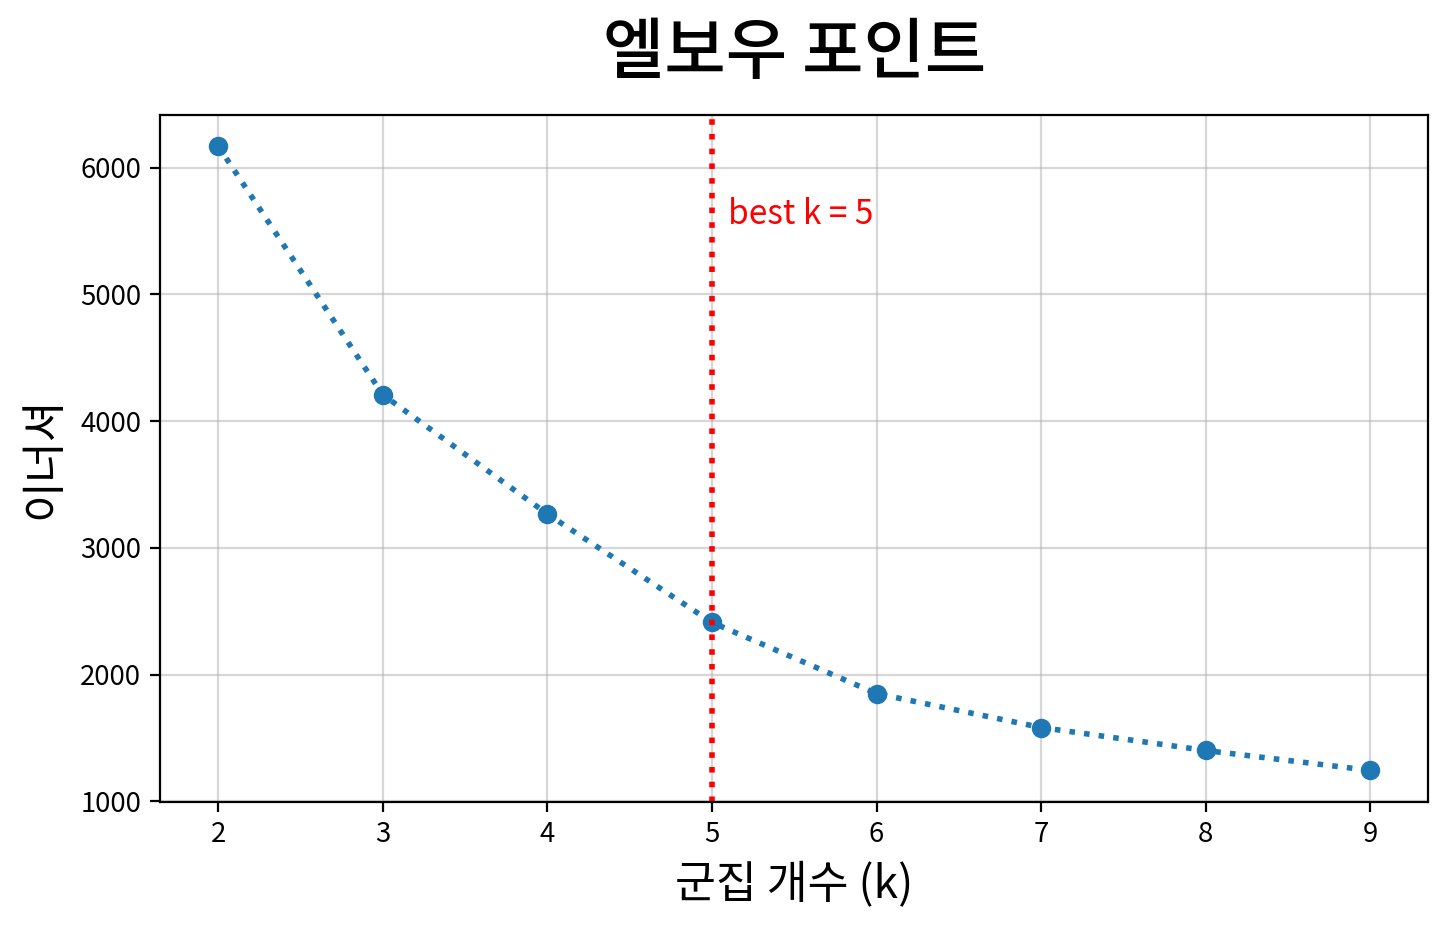

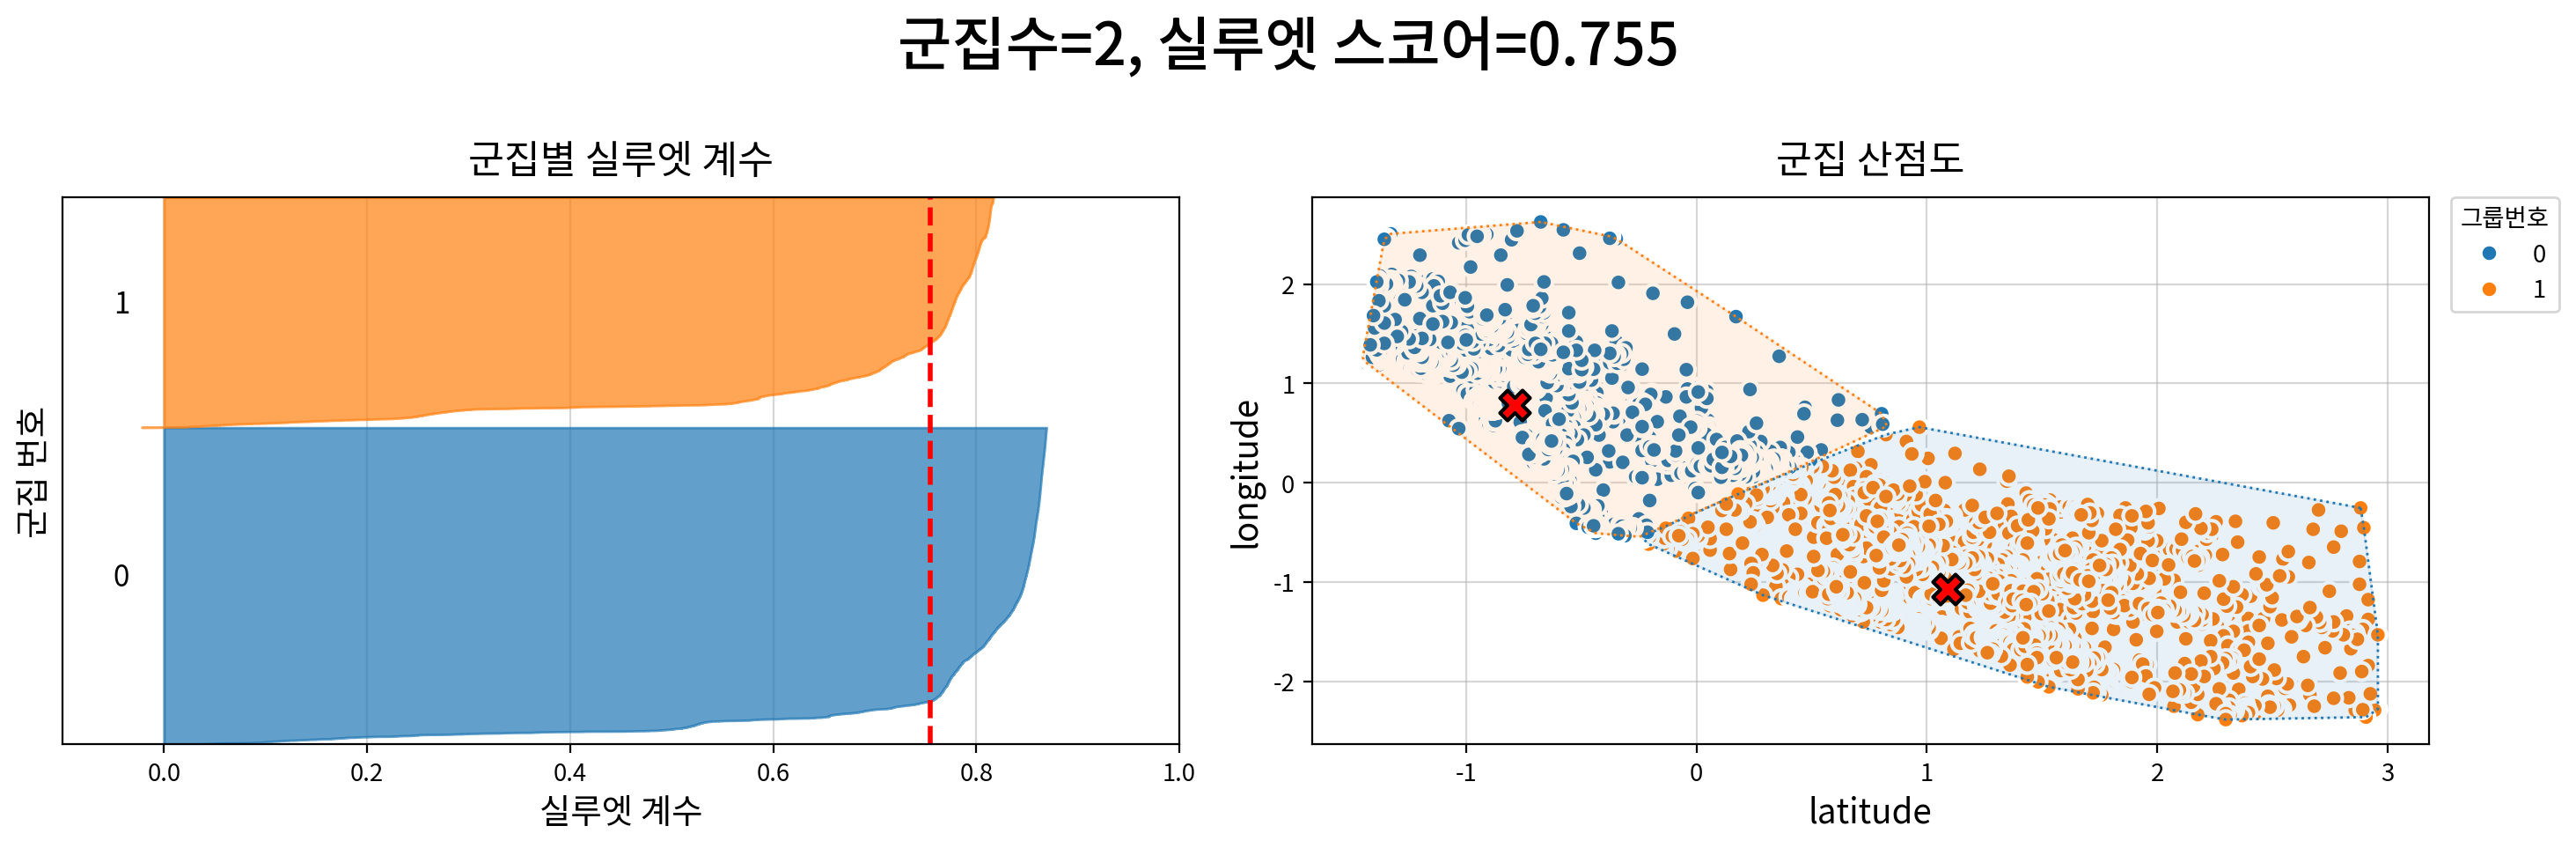

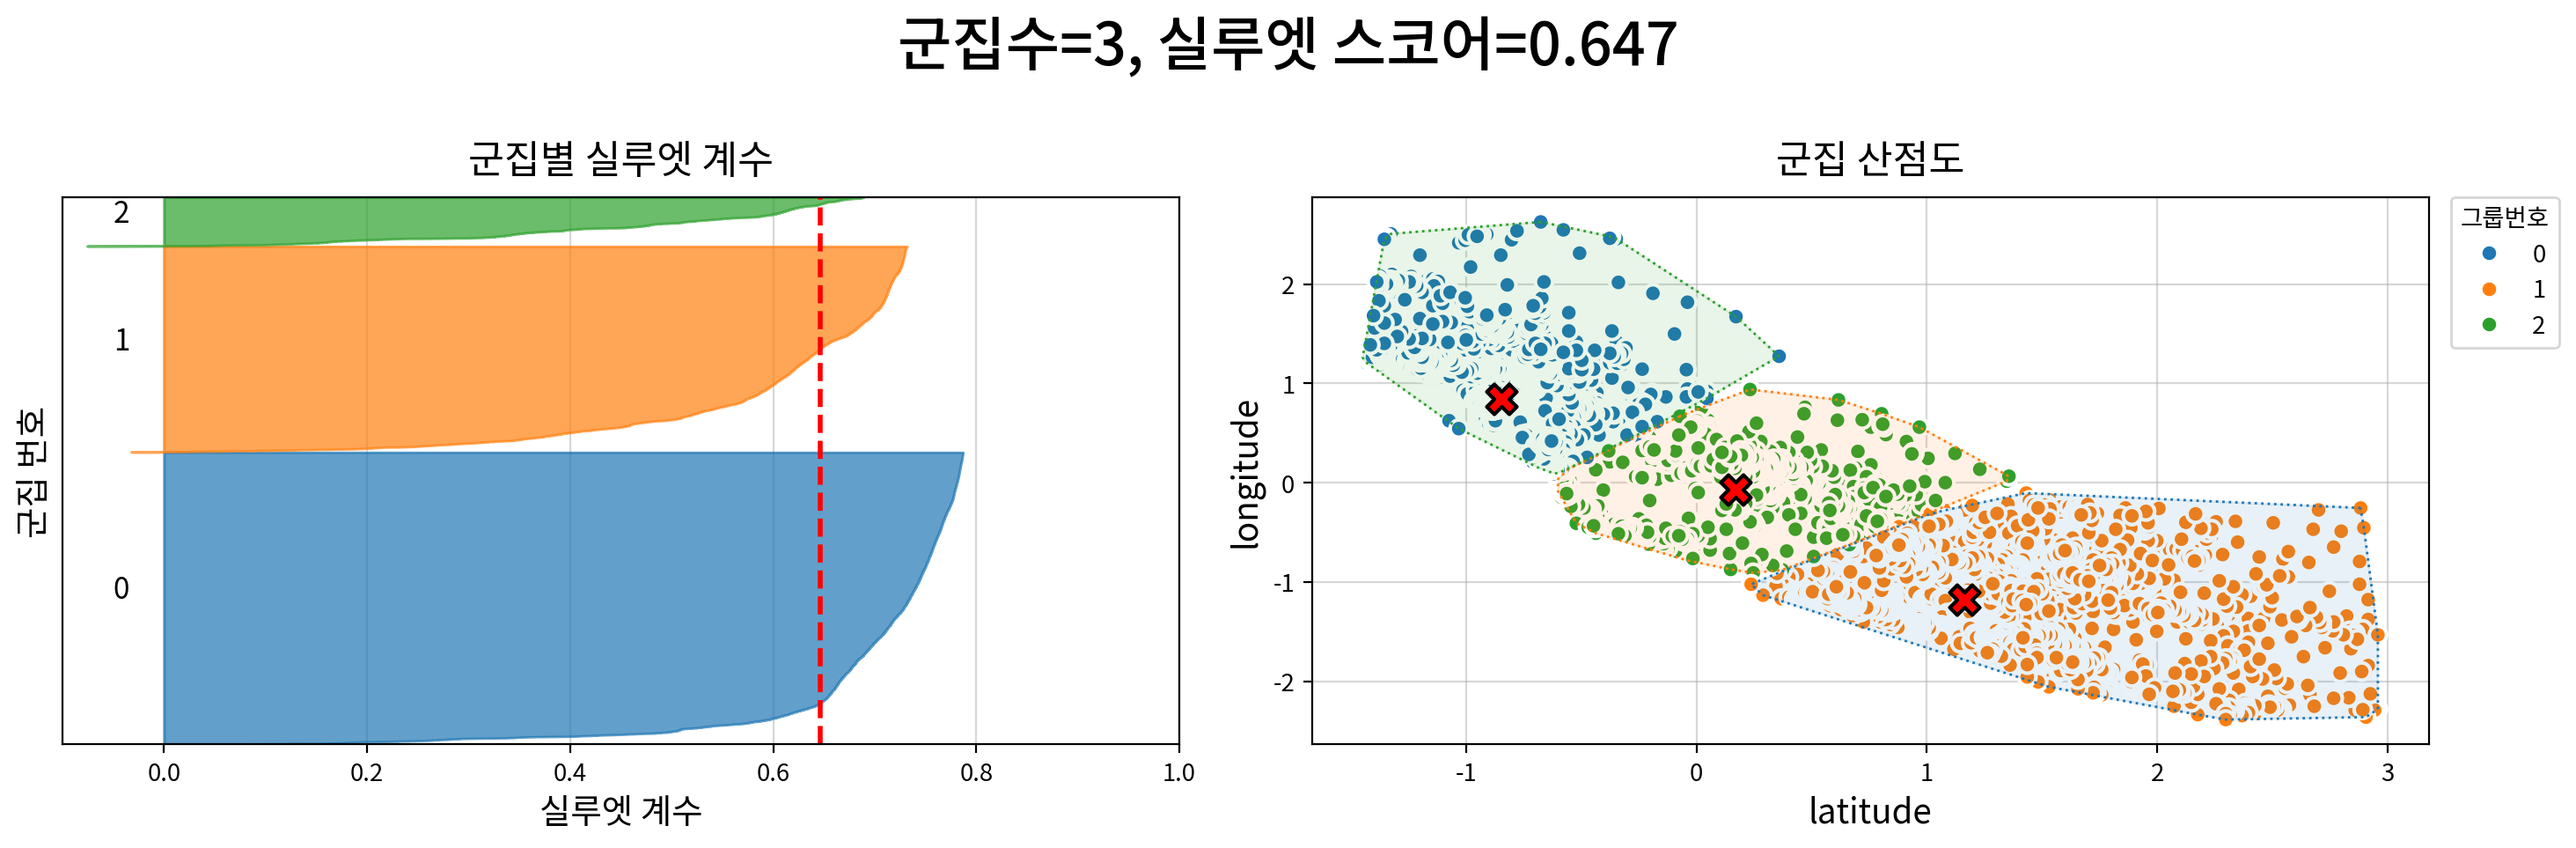

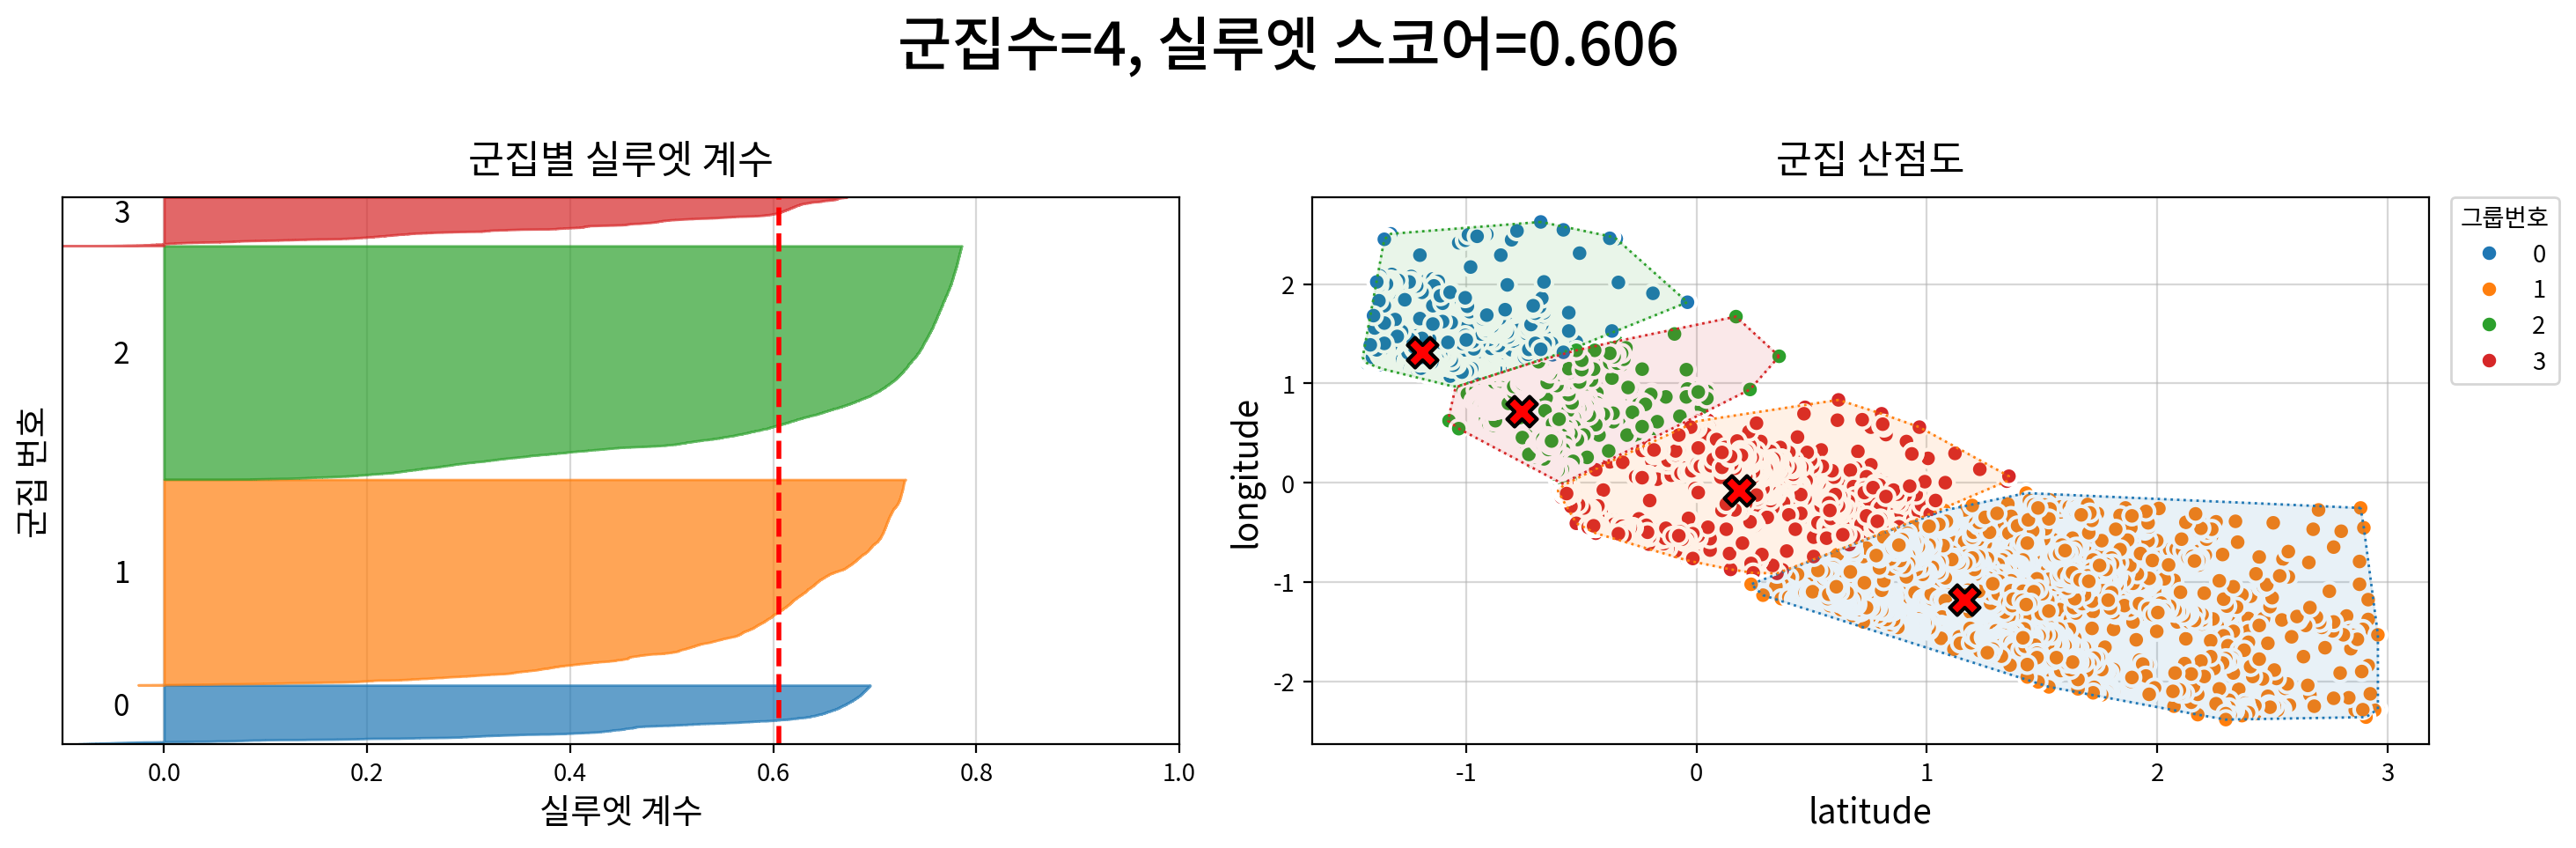

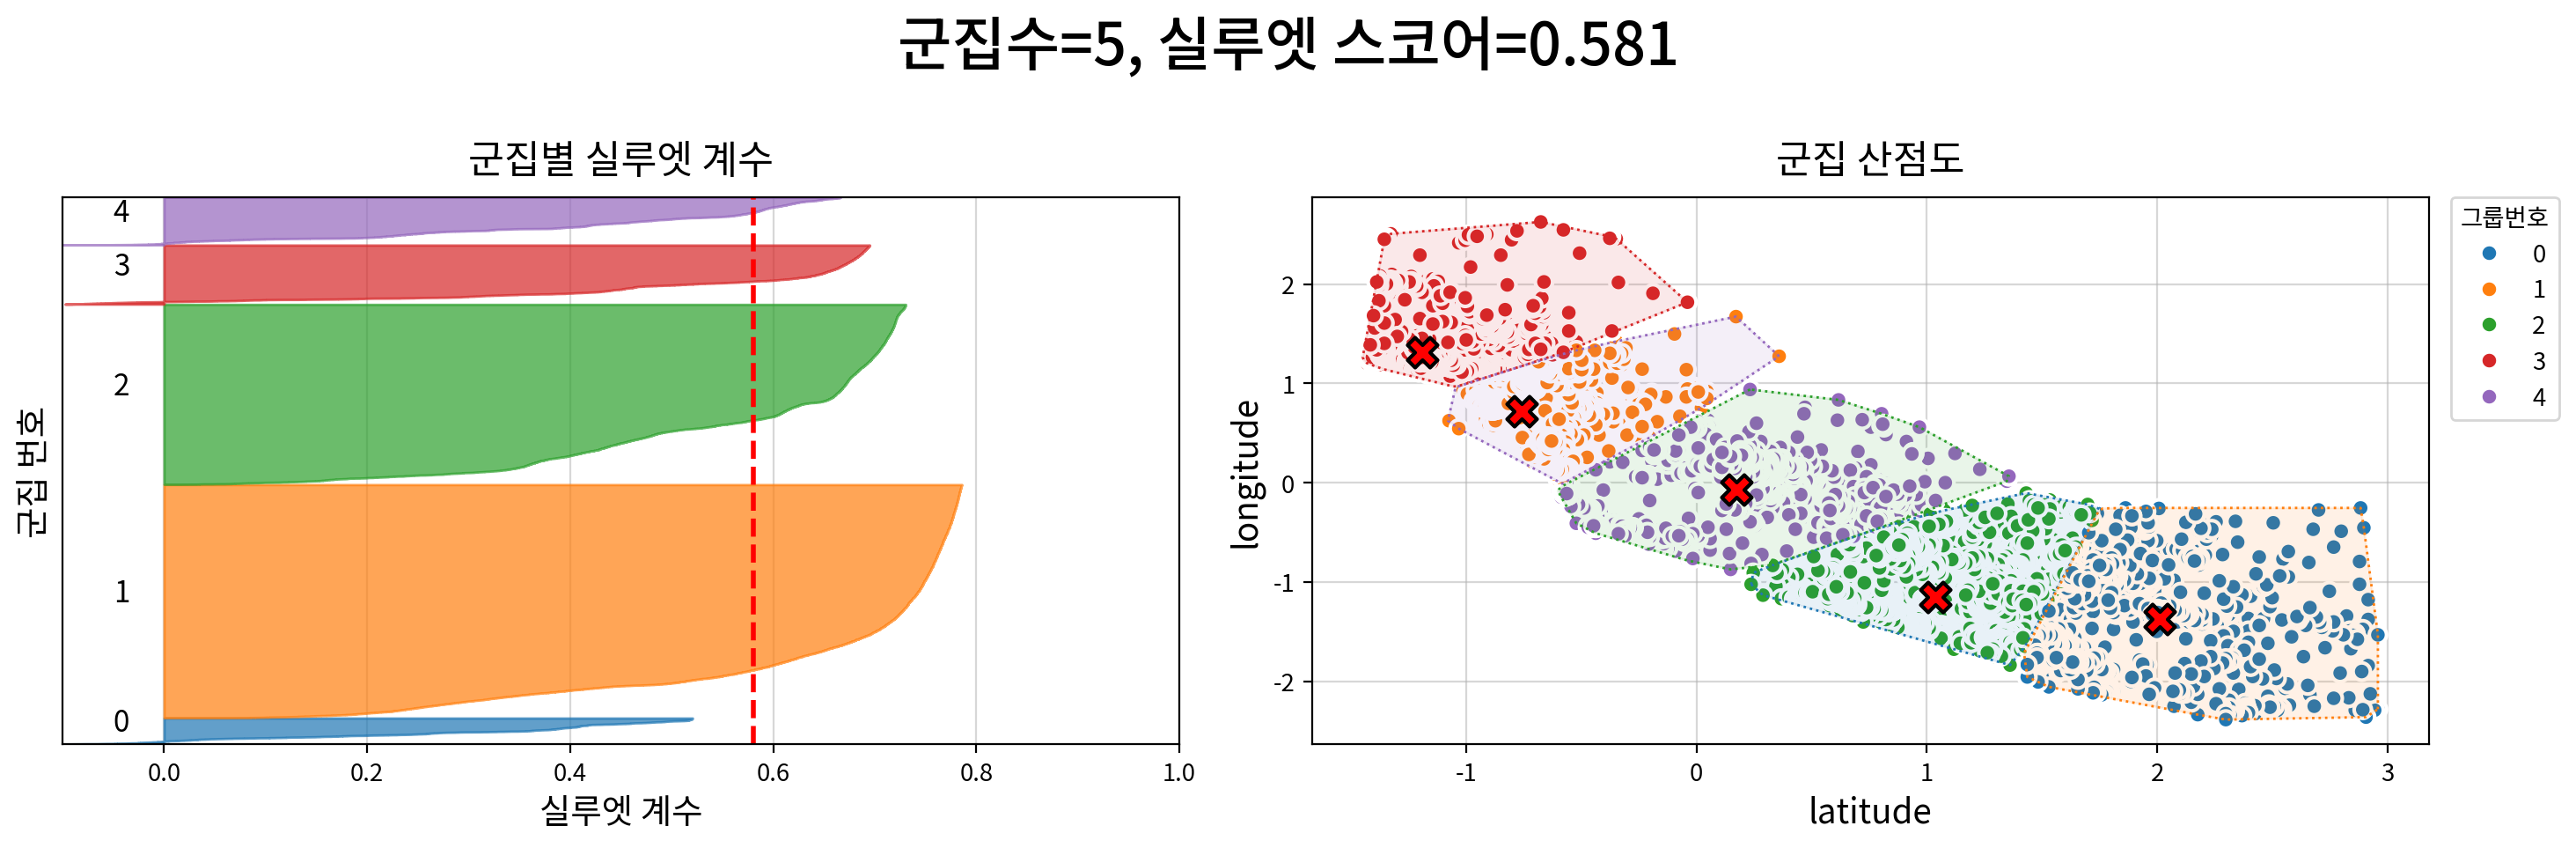

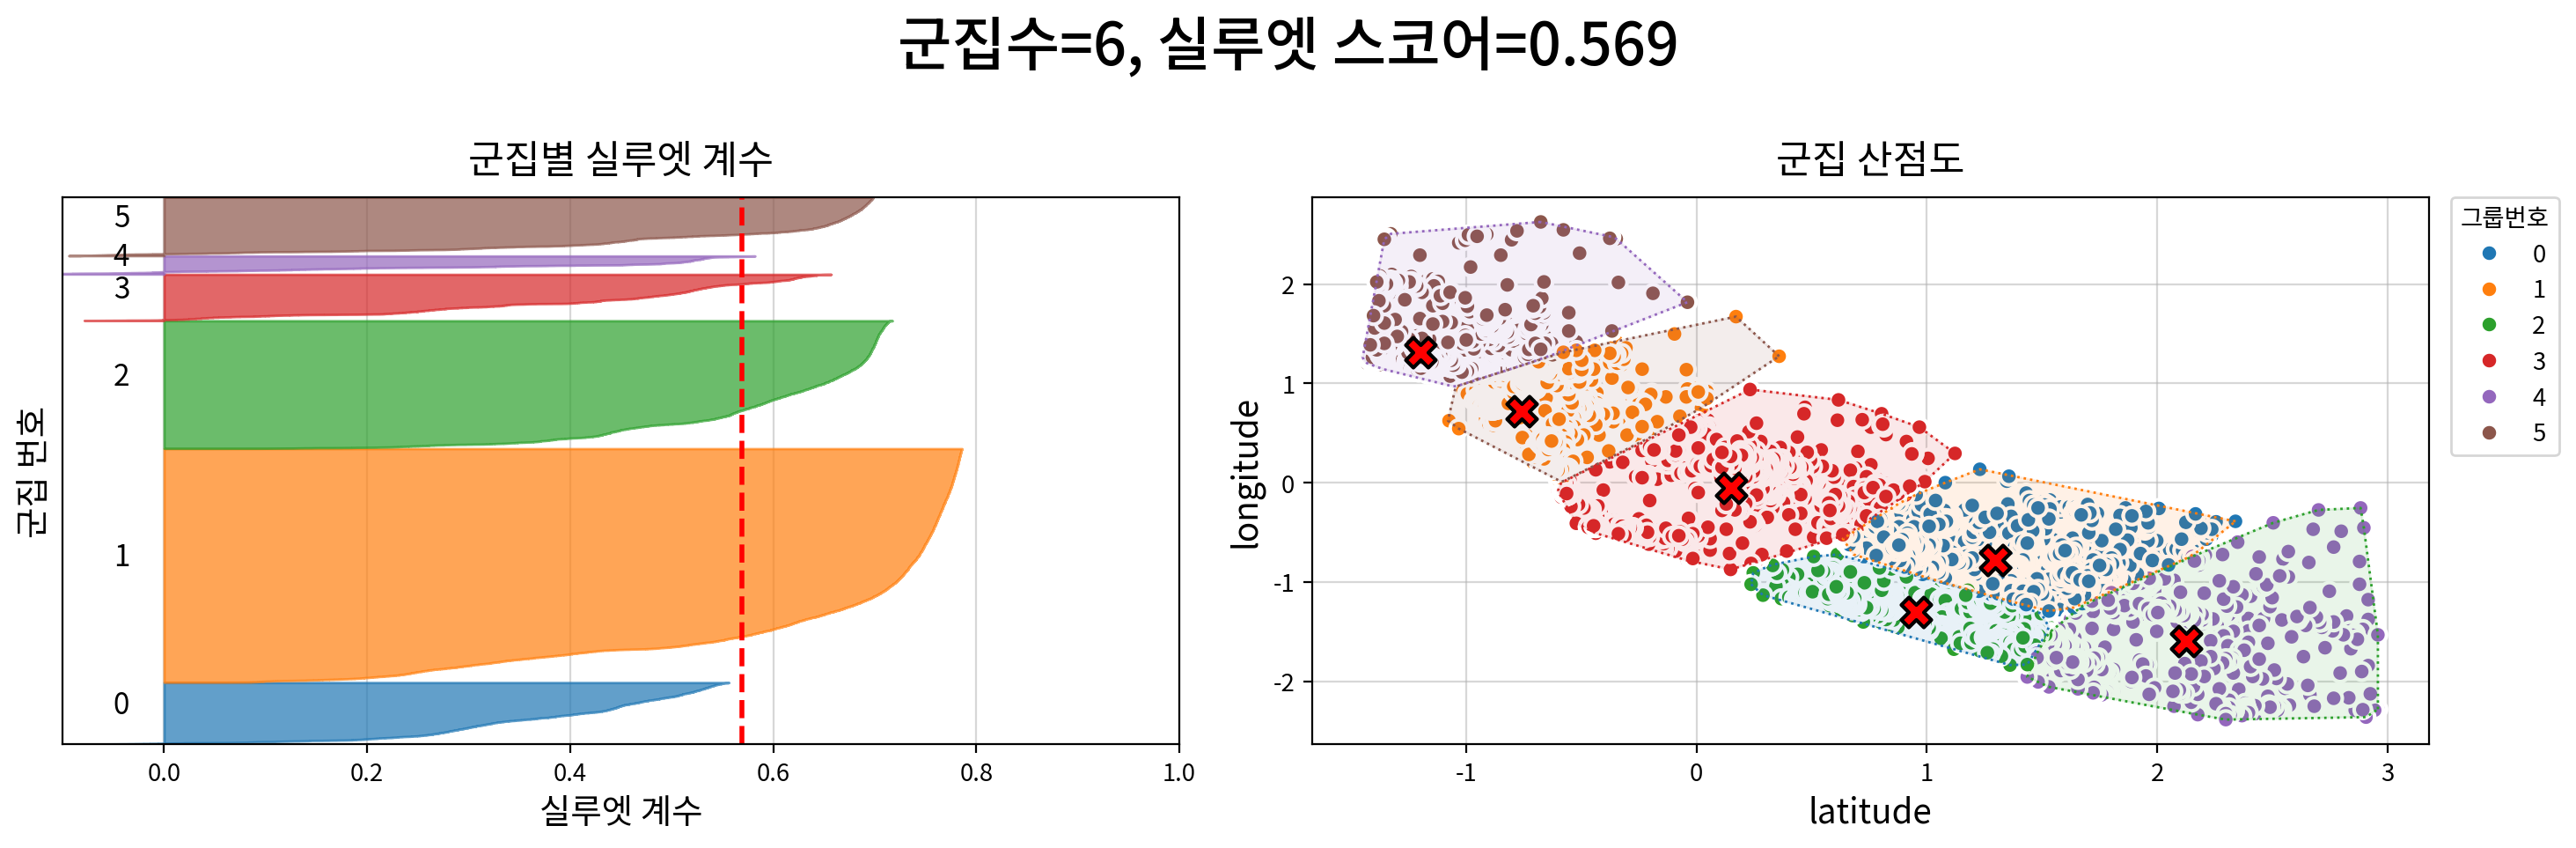

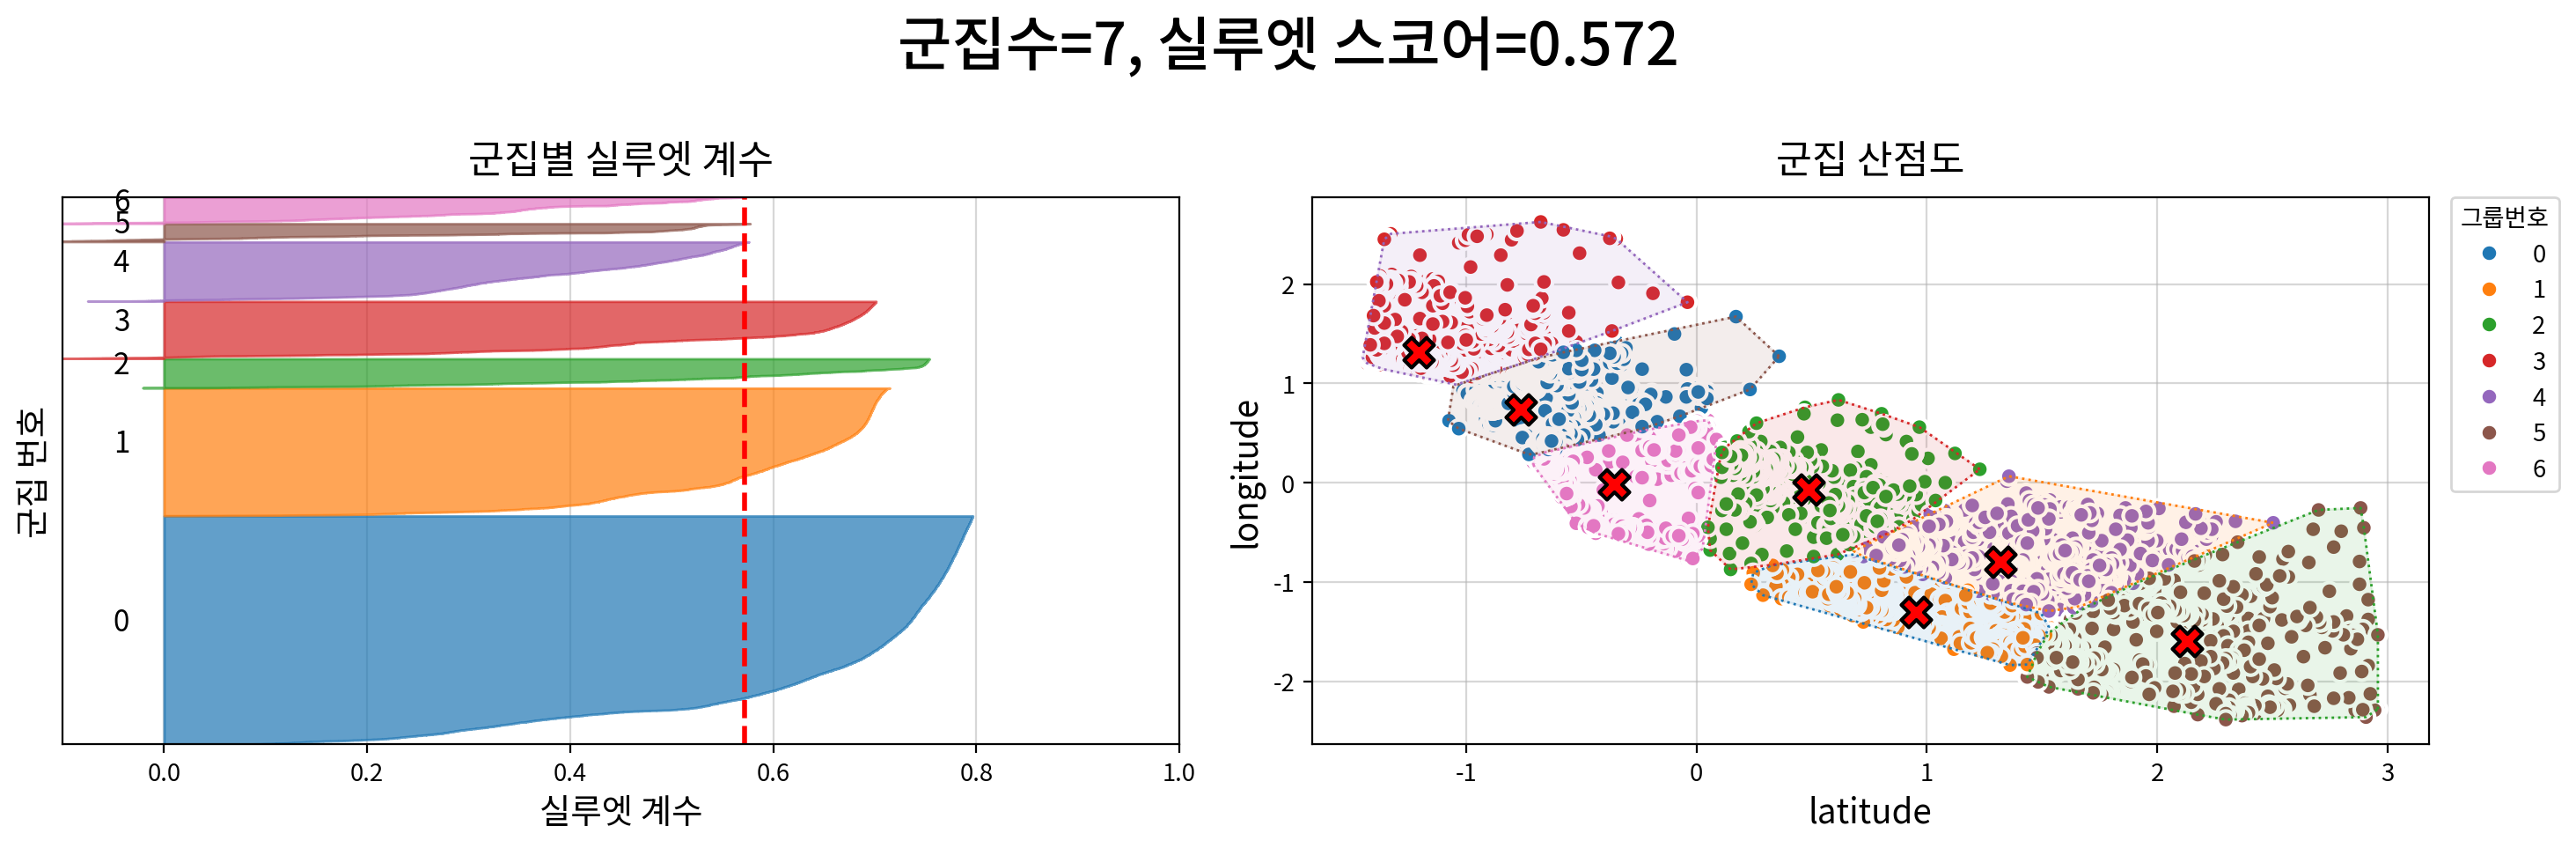

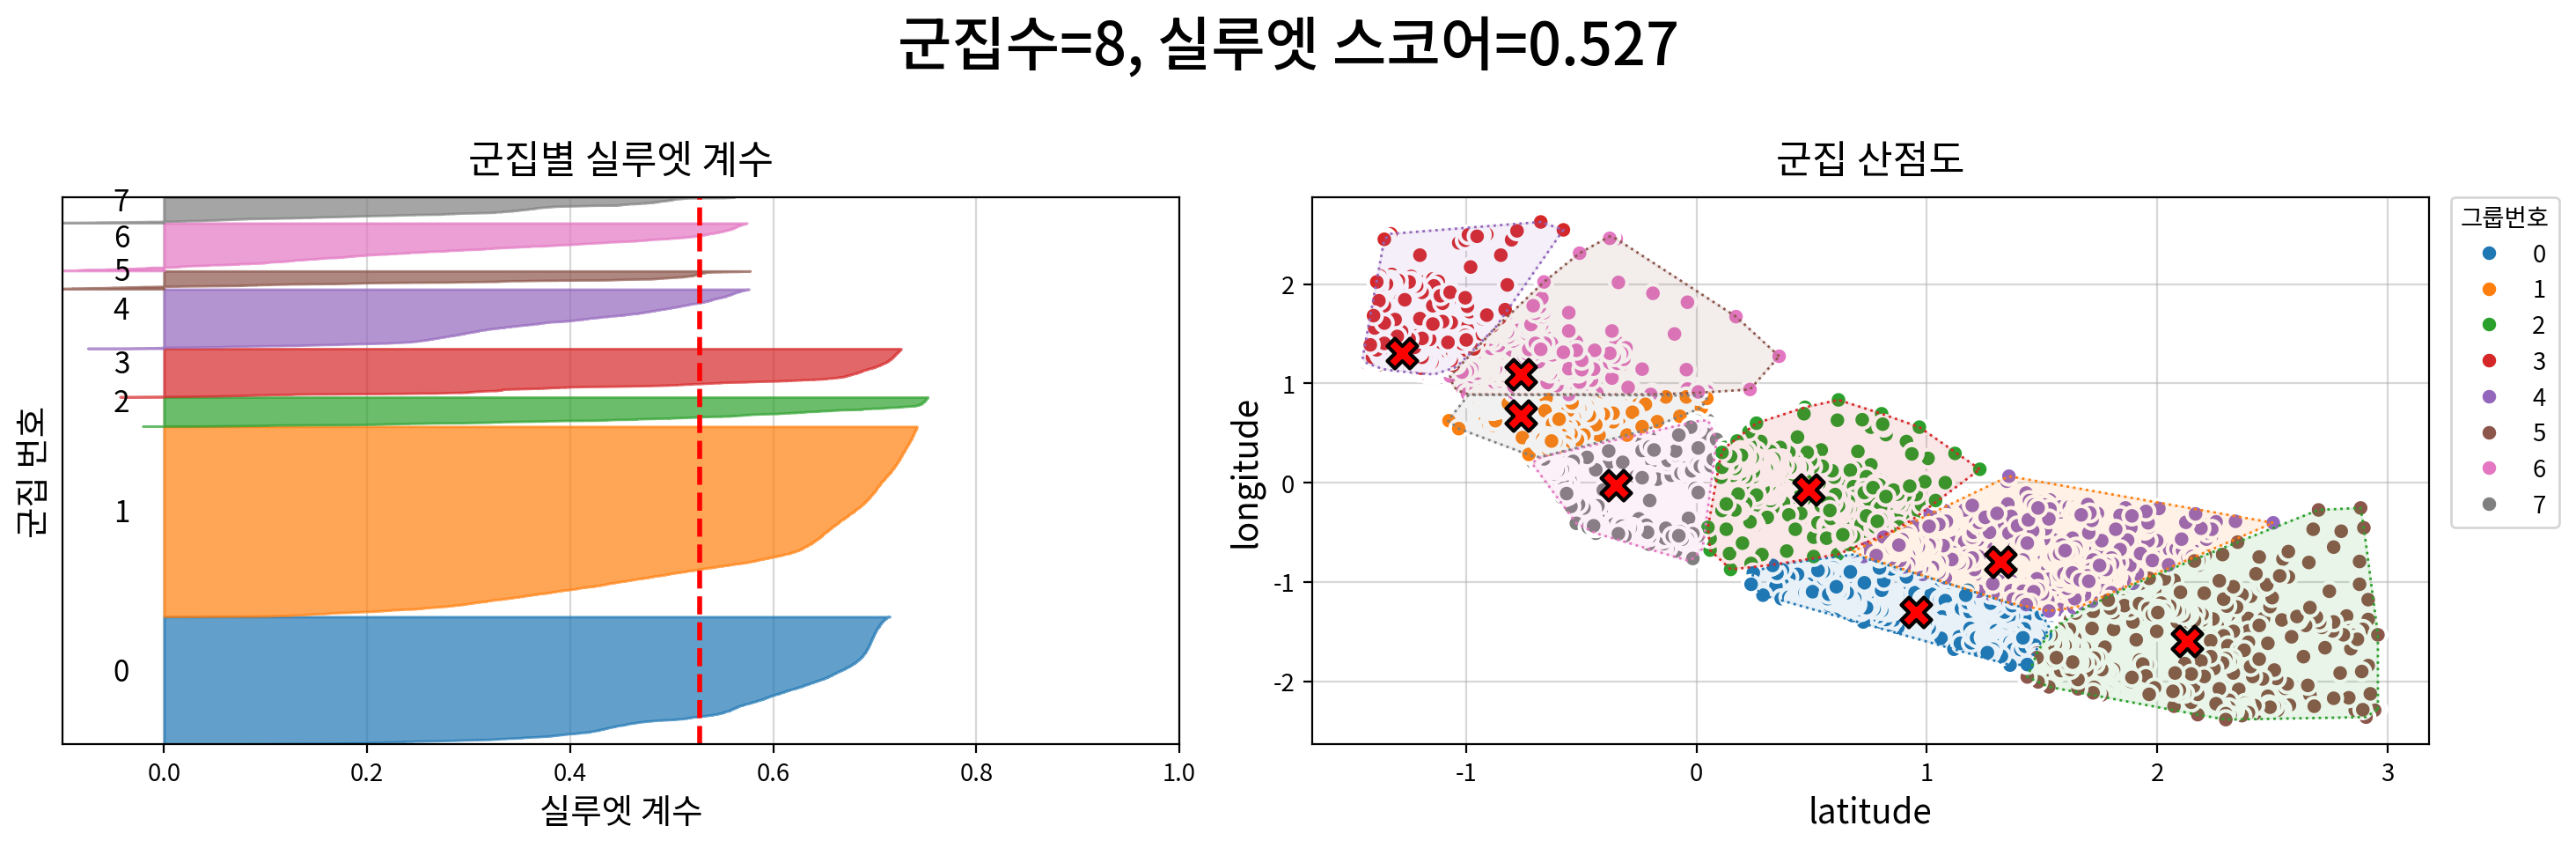

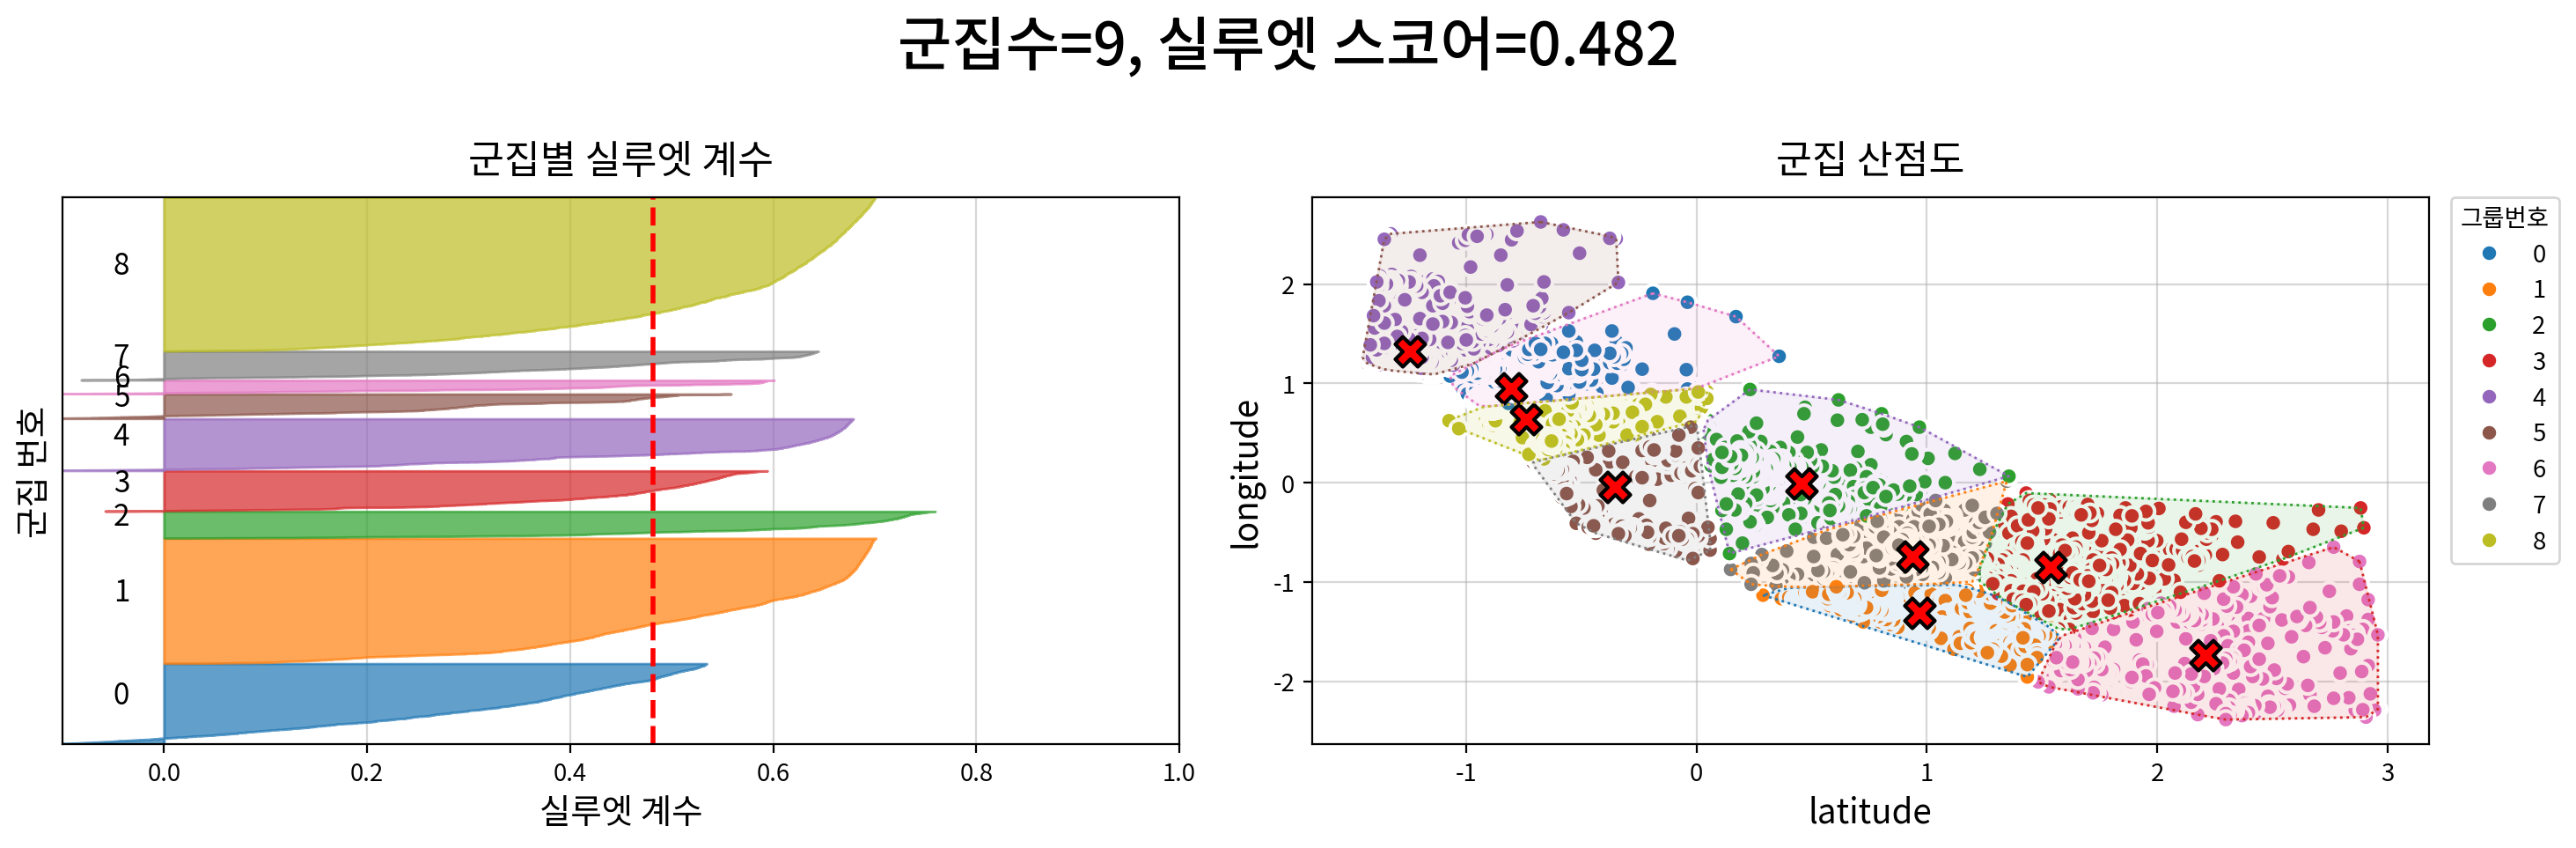

[1단계] 엘보운 포인트       : k = 5  (뭉침만 확인 -> 후보)
[2단계] 실루엣 균형지수     : k = 2  (뭉침 + 분리 + 크기 균형)
두 지표가 다른 k를 가리킵니다.
    · k = 5 : 균형지수 0.0075 (스코어 3   0.581
Name: 스코어, dtype: float64, 두께비 1.3762)
------------------------------------------------------------
>>> 최종 선택:k = 2
 (지표는 후보를 좁혀줄 뿐이므로, 목적과 도메인 지식으로 한 번 더 확인할 것)


In [17]:
final_k, _ = my_cluster.best_k(df, klist=list(range(2, 10)), 
                               columns=['latitude', 'longitude'],
                               plot_each=True, width=740, height=480)

#### 💡 인사이트

- **k=2, 실루엣 0.755**: 📌 가장 높은 점수이고 두 군집의 구분이 가장 명확하게 보임
- **k=3, 실루엣 0.647**: 📉 2보다 점수가 내려가며, 추가 분할이 분리도 향상으로 이어지지 않음
- **k=4, 실루엣 0.606**: 📉 군집이 더 세분화되지만 품질은 계속 하락함
- **k=5, 실루엣 0.581**: 📉 엘보우와 일치하는 구간이지만, 실루엣 기준으로는 2~4보다 낮음
- **k=6, 실루엣 0.569**: 📉 추가 분할 효과가 크지 않았고 점수도 더 낮음
- **k=7, 실루엣 0.572**: 🔄 6보다 아주 약간 높지만, 전체 흐름에서는 여전히 낮은 편임
- **k=8, 실루엣 0.531**: 📉 점수가 더 떨어져 군집 품질이 약해짐
- **k=9, 실루엣 0.497**: 📉 제시된 값들 중 가장 낮아 군집 간 분리가 더 불리해짐

### ✅ 최종 군집 수 선정

#### 🎯 k=2 양분화의 한계

- **단순성 문제**: 캘리포니아 주택시장을 단 2개 군집으로 나누면 본질적으로 "고가지역 vs 저가지역" 정도의 이분화만 가능함
- **지역적 다양성 미반영**: 제시된 플롯들에서 보면 k=2일 때 검은색과 초록색 두 덩어리로만 나뉘는데, 실제 캘리포니아 주택시장은 지역별로 더 복잡한 특성을 가지고 있을 가능성이 높음
- **파생변수로서의 유용성 부족**: 공간 특성을 반영한 파생변수를 만드는 목표라면, 2개 범주로는 모델 입력으로 활용할 때 정보량이 매우 제한적임

#### 🔄 k=5의 현실성

- **엘보우와의 일치**: k=5는 이너셔 감소 곡선의 꺾이는 지점과 일치하며, 이는 "충분한 분할"을 의미함
- **실루엣 점수 타당성**: 0.581은 k=2의 0.755보다 낮지만, 여전히 "중간 이상의 군집 품질"을 나타냄 (0.5 이상 기준)
- **실질적 해석 가능성**: k=5는 주택시장을 5개의 지리적·경제적 특성으로 나눌 수 있어 더 의미 있는 시장 분화 분석 가능

#### ✏️ 최종 선정 : **k=5**

1. 📊 **절충점**: 통계적 품질(0.581)과 실질적 유용성 사이의 최적점
2. 🗺️ **도메인 타당성**: 캘리포니아 주택시장의 다양한 지역특성을 충분히 반영
3. 🔧 **파생변수 활용성**: 모델에 입력할 때 정보손실이 적고, 해석 가능성도 높음
4. 📈 **엘보우 일치**: 통계적 근거도 함께 제시 가능

**k=2는 너무 단순하고, k=6 이상은 점수 개선 폭이 미미하므로, k=5가 가장 균형 잡힌 선택으로 여겨짐**

### 2. 최종 군집 모형 적합

> 실루엣 점수 기준 최댓값은 `k=2`로 출력되지만, 다음 셀에서는 `final_k=5`로 재지정되어 이후 분석에 사용됩니다. 이 선택의 기준은 코드에 명시되어 있지 않습니다.


StandardScaler 적용 (2개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
latitude           32.54 ~ 41.95          -1.45 ~ 2.96
longitude      -124.35 ~ -114.31          -2.39 ~ 2.63


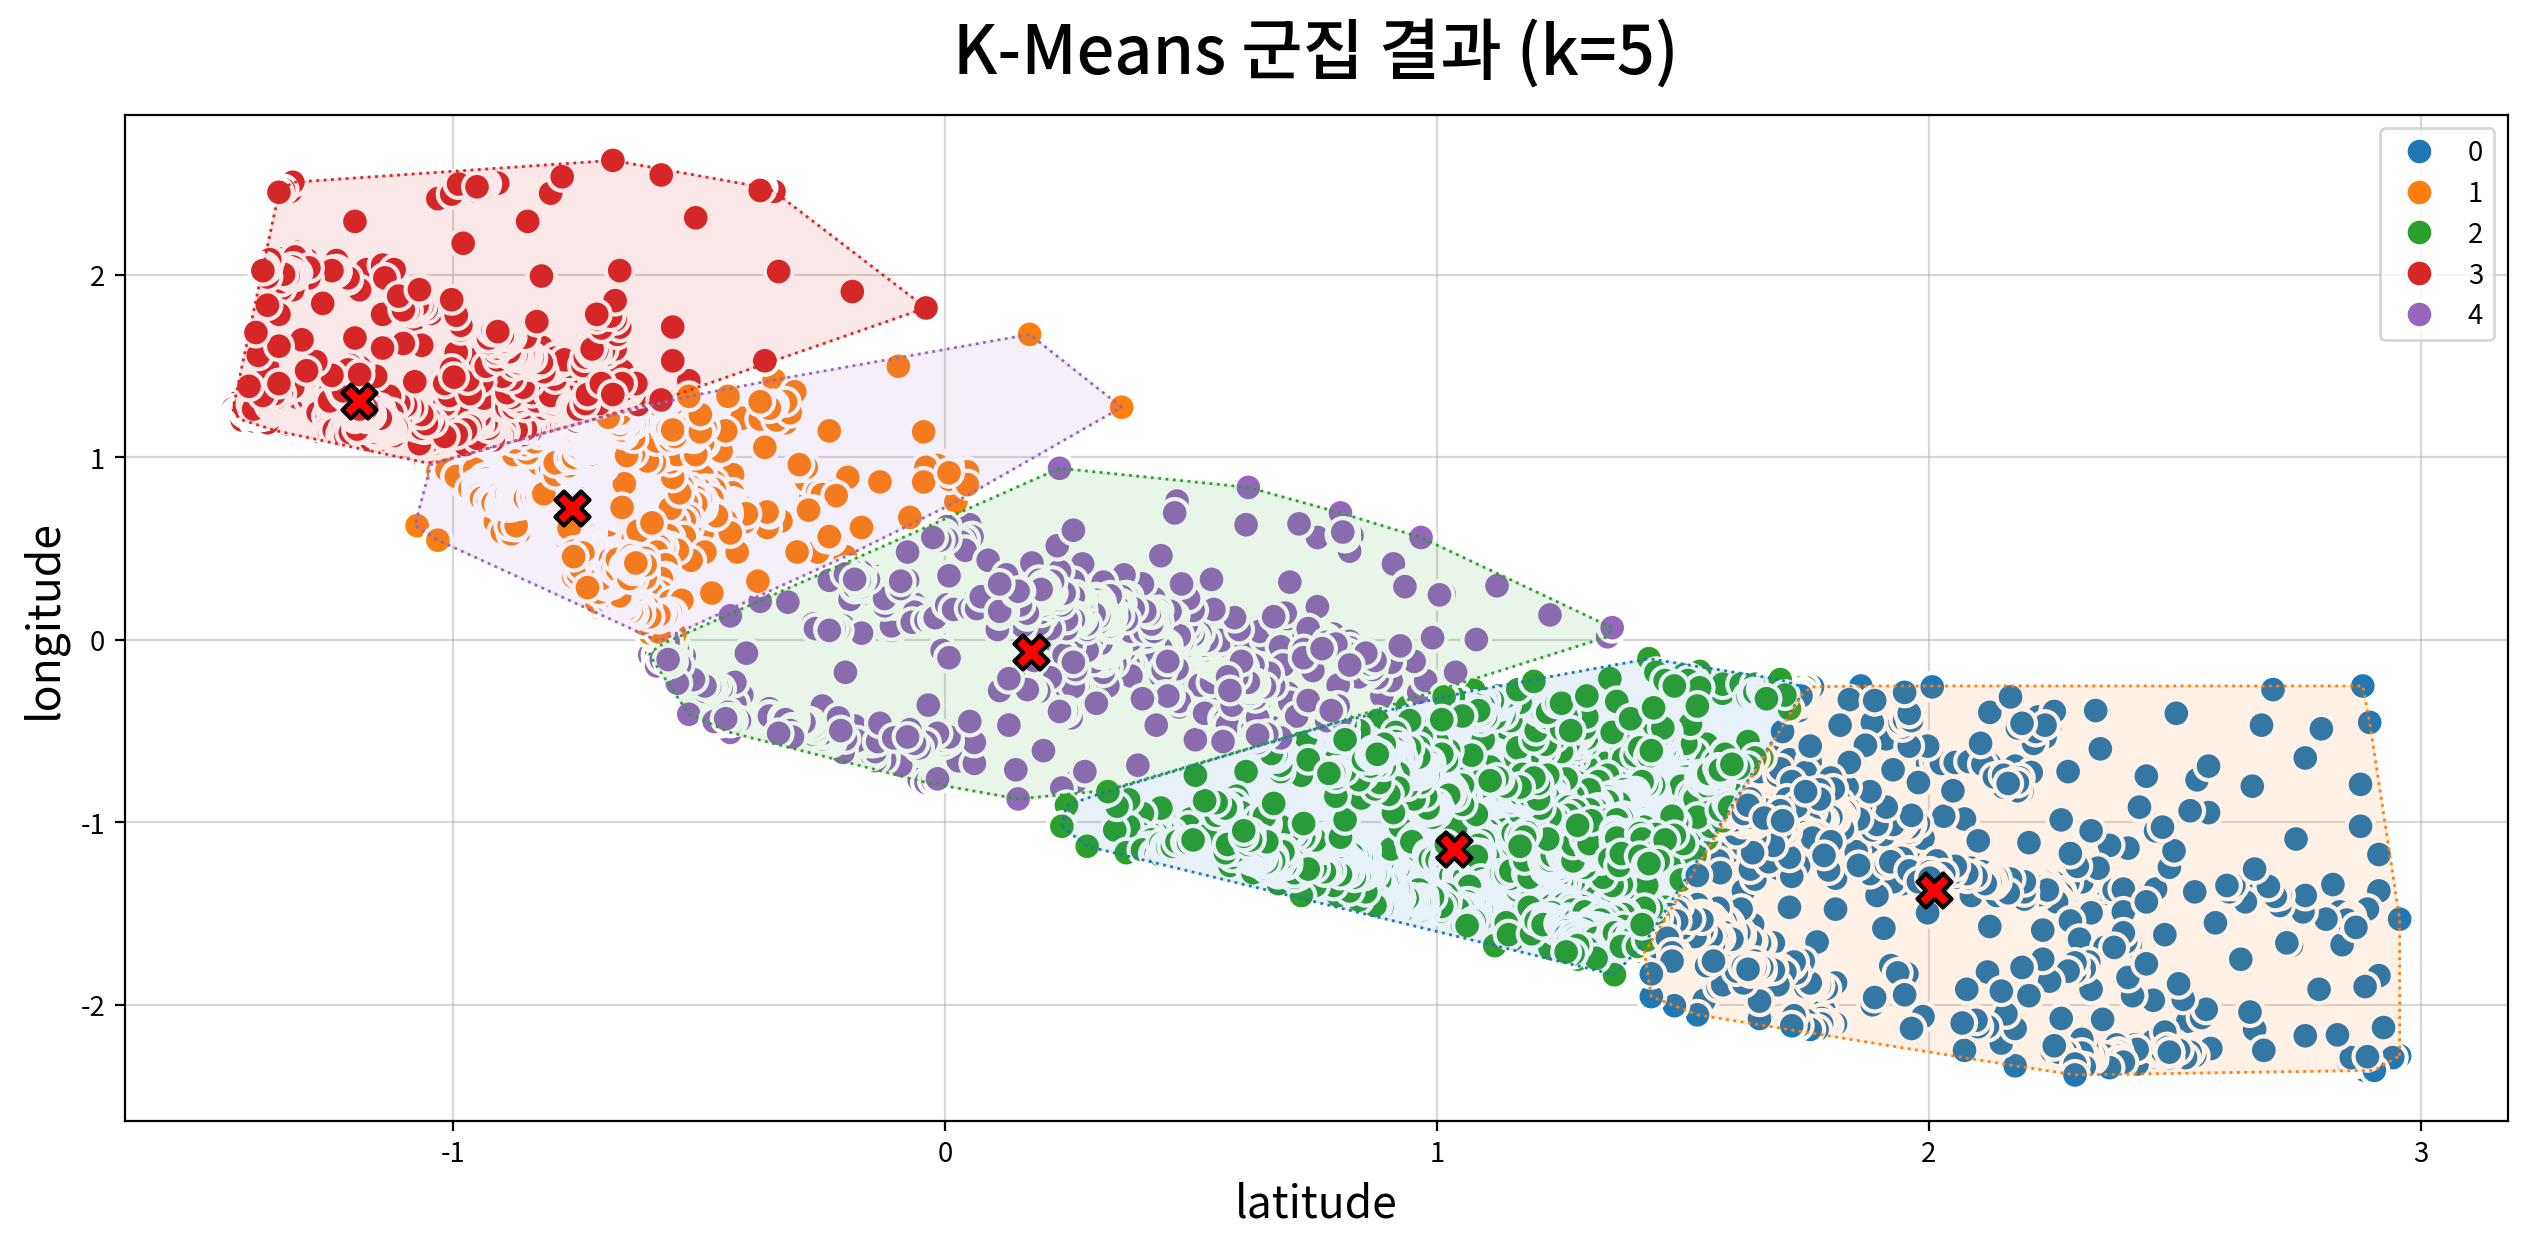

,latitude,longitude,그룹번호
0,1.052,-1.327,2
1,1.042,-1.322,2
2,1.038,-1.332,2
3,1.038,-1.337,2
4,1.038,-1.337,2
...,...,...,...
20428,1.801,-0.758,0
20429,1.805,-0.818,0
20430,1.777,-0.823,0
20431,1.777,-0.873,0


In [18]:
final_k = 5
estimator, cdf, _ = my_cluster.kmeans(df, k=final_k,
                        columns=['latitude', 'longitude'])
cdf

### 3. 공간특성 반영 파생변수 추가

In [19]:
df["special_cluster"] = cdf["그룹번호"].astype("category")

# #02 와 같은 규칙으로 의미를 등록하고 목록 이름을 붙인다.
# -> #04 의 검증 반복문이 이 이름을 그대로 받아 쓴다.
column_means["special_cluster"] = "위경도 기반 공간 군집"
spatial_cols = ["special_cluster"]

df[['longitude', 'latitude', 'ocean_area', 'special_cluster']].head()

,longitude,latitude,ocean_area,special_cluster
0,-122.230,37.880,COASTAL,2
1,-122.220,37.860,COASTAL,2
2,-122.240,37.850,COASTAL,2
3,-122.250,37.850,COASTAL,2
4,-122.250,37.850,COASTAL,2


## #06. 파생변수 검증

### 1. 검증 대상 분류

- 검증 대상은 새로 만든 파생변수 (원본 변수는 EDA에서 이미 확인함)

In [20]:
# 연속형 파생변수
derived_continuous = ['rooms_per_person', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'income_per_person']

# 범주형 파생변수
derived_nominal = ['is_age_capped', 'is_income_capped', 'ocean_area', 'special_cluster']

print("연속형 파생 :", derived_continuous)
print("범주형 파생 :", derived_nominal)

연속형 파생 : ['rooms_per_person', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'income_per_person']
범주형 파생 : ['is_age_capped', 'is_income_capped', 'ocean_area', 'special_cluster']


### 2. 연속형 기술 통계량

In [21]:
derived_num_desc = my_qtcheck.numerical_summary(df, columns=derived_continuous)
derived_num_desc.T

,rooms_per_person,rooms_per_household,bedrooms_per_room,population_per_household,income_per_person
count,20433.000,20433.000,20433.000,20433.000,20433.000
mean,1.978,5.431,0.213,3.072,1.409
std,1.150,2.483,0.058,10.438,0.755
min,0.003,0.846,0.100,0.692,0.008
25%,1.524,4.441,0.175,2.429,0.870
50%,1.938,5.231,0.203,2.818,1.296
75%,2.297,6.052,0.240,3.282,1.777
max,55.222,141.909,1.000,1243.333,7.550
rel_diff,0.021,0.038,0.049,0.090,0.087
rdiff_flag,similar,similar,similar,similar,similar


### 3. 범주형 기술 통계량

- 플래그와 병합된 범주, 군집분석 결과는 값의 종류가 2개인 범주형이므로 category 타입으로 변환해 요약한다.

In [22]:
df = my_qtcheck.set_type(df, as_category=derived_nominal)

derived_cat_desc = my_qtcheck.categorical_summary(df, 
                        columns=derived_nominal, value_counts=False)
derived_cat_desc

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20433 entries, 0 to 20432
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   longitude                 20433 non-null  float64 
 1   latitude                  20433 non-null  float64 
 2   housing_median_age        20433 non-null  int64   
 3   total_rooms               20433 non-null  int64   
 4   total_bedrooms            20433 non-null  float64 
 5   population                20433 non-null  int64   
 6   households                20433 non-null  int64   
 7   median_income             20433 non-null  float64 
 8   median_house_value        20433 non-null  int64   
 9   ocean_proximity           20433 non-null  category
 10  rooms_per_person          20433 non-null  float64 
 11  rooms_per_household       20433 non-null  float64 
 12  bedrooms_per_room         20433 non-null  float64 
 13  population_per_household  20433 non-null  floa

,is_age_capped,is_income_capped,ocean_area,special_cluster
count,20433,20433,20433,20433
unique,2,2,2,5
top,0,0,COASTAL,1
freq,19168,20383,13937,8729


### 4. 단변량 분석 (연속형 파생변수)

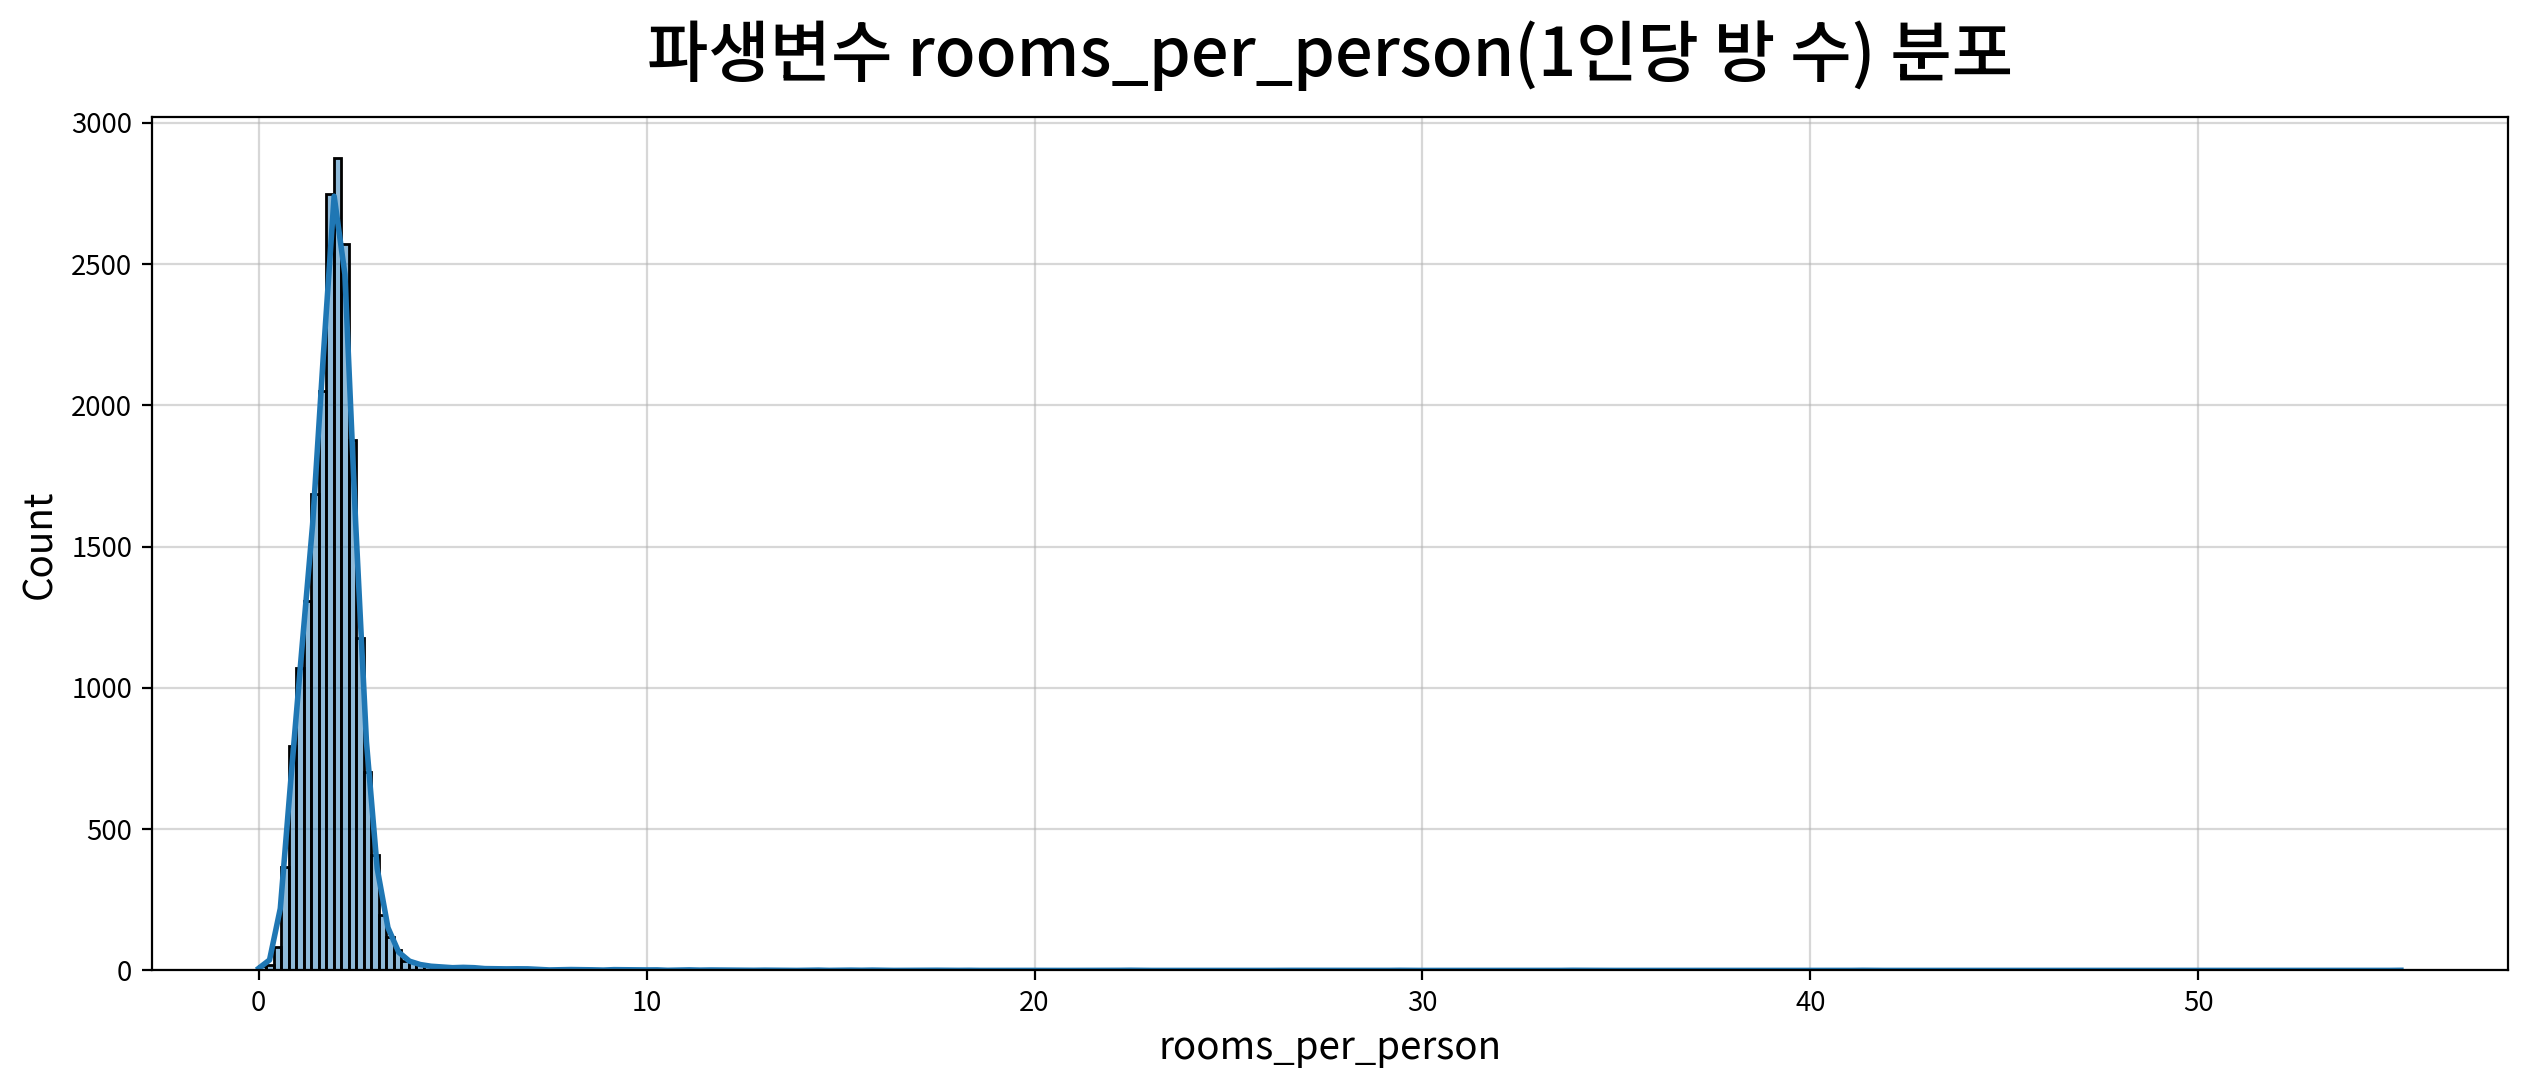

,rooms_per_person
count,20433.000
mean,1.978
std,1.150
min,0.003
25%,1.524
50%,1.938
75%,2.297
max,55.222
rel_diff,0.021
rdiff_flag,similar


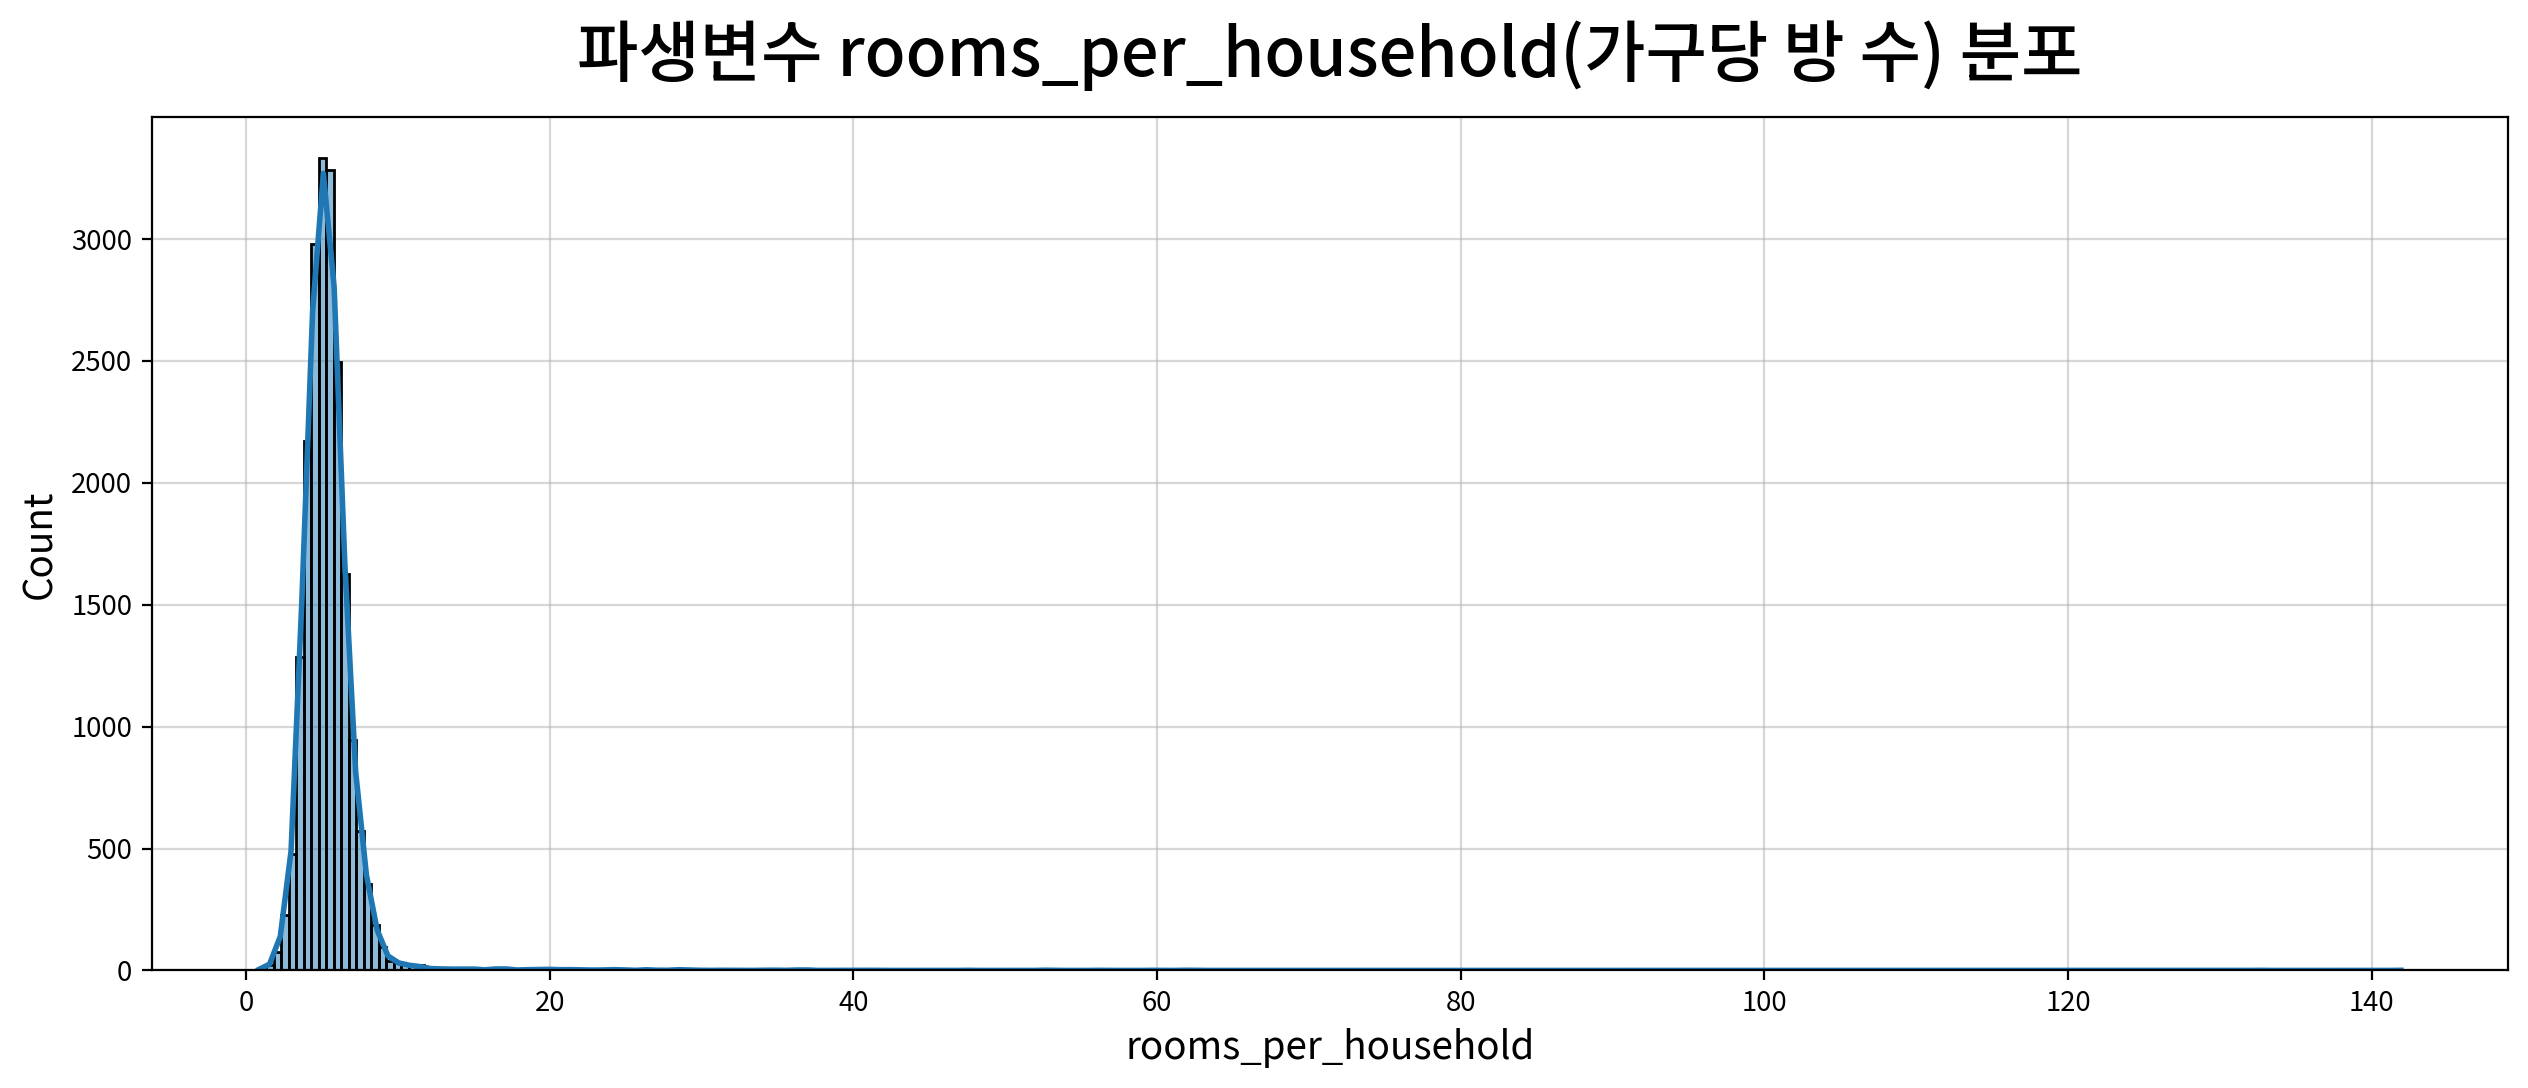

,rooms_per_household
count,20433.000
mean,5.431
std,2.483
min,0.846
25%,4.441
50%,5.231
75%,6.052
max,141.909
rel_diff,0.038
rdiff_flag,similar


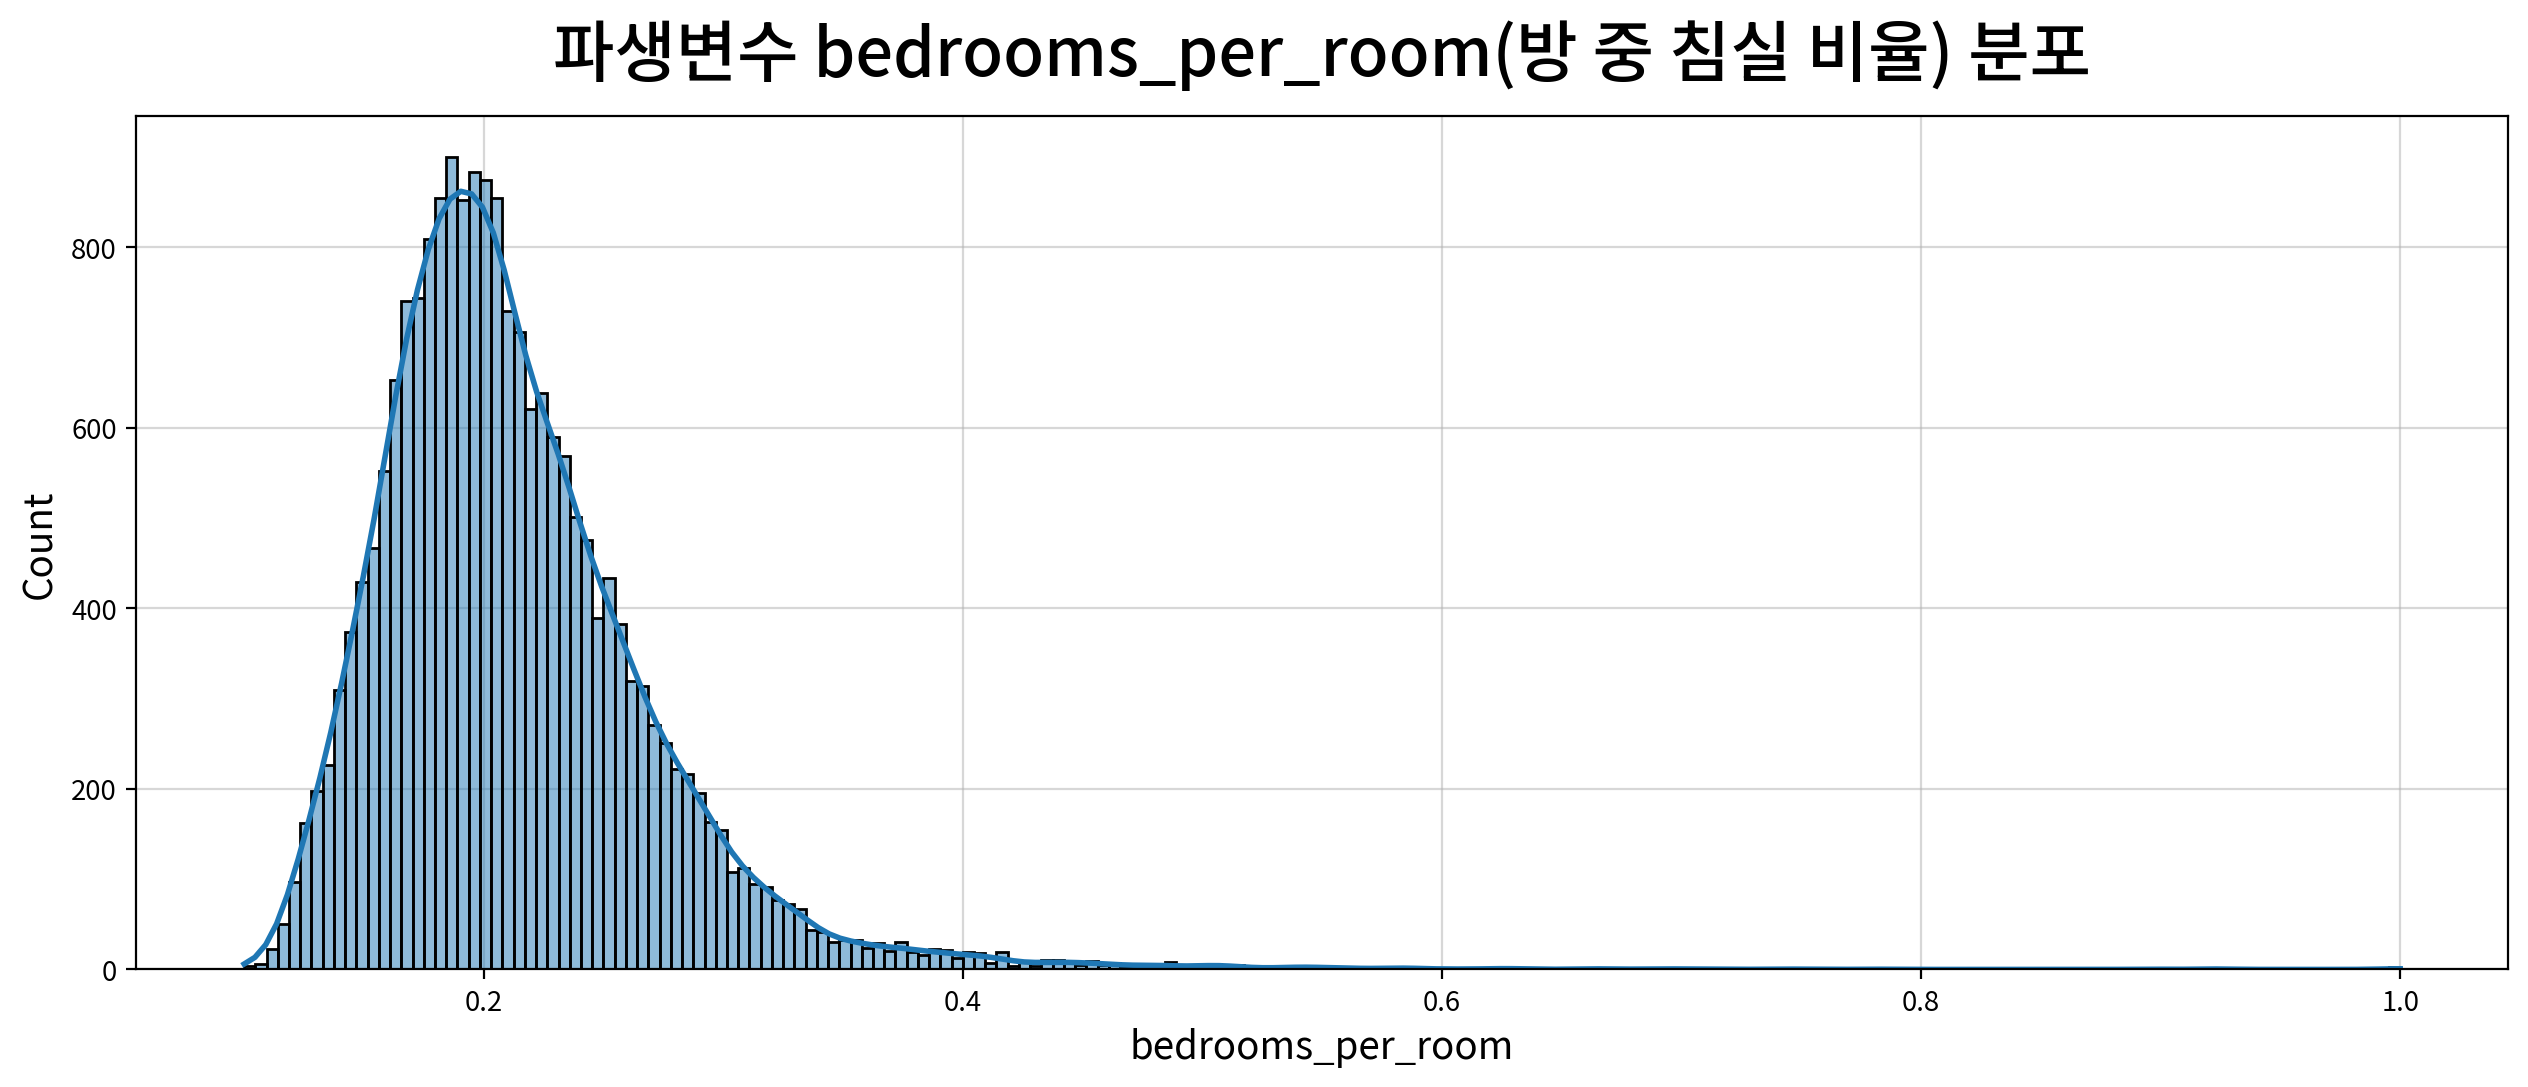

,bedrooms_per_room
count,20433.000
mean,0.213
std,0.058
min,0.100
25%,0.175
50%,0.203
75%,0.240
max,1.000
rel_diff,0.049
rdiff_flag,similar


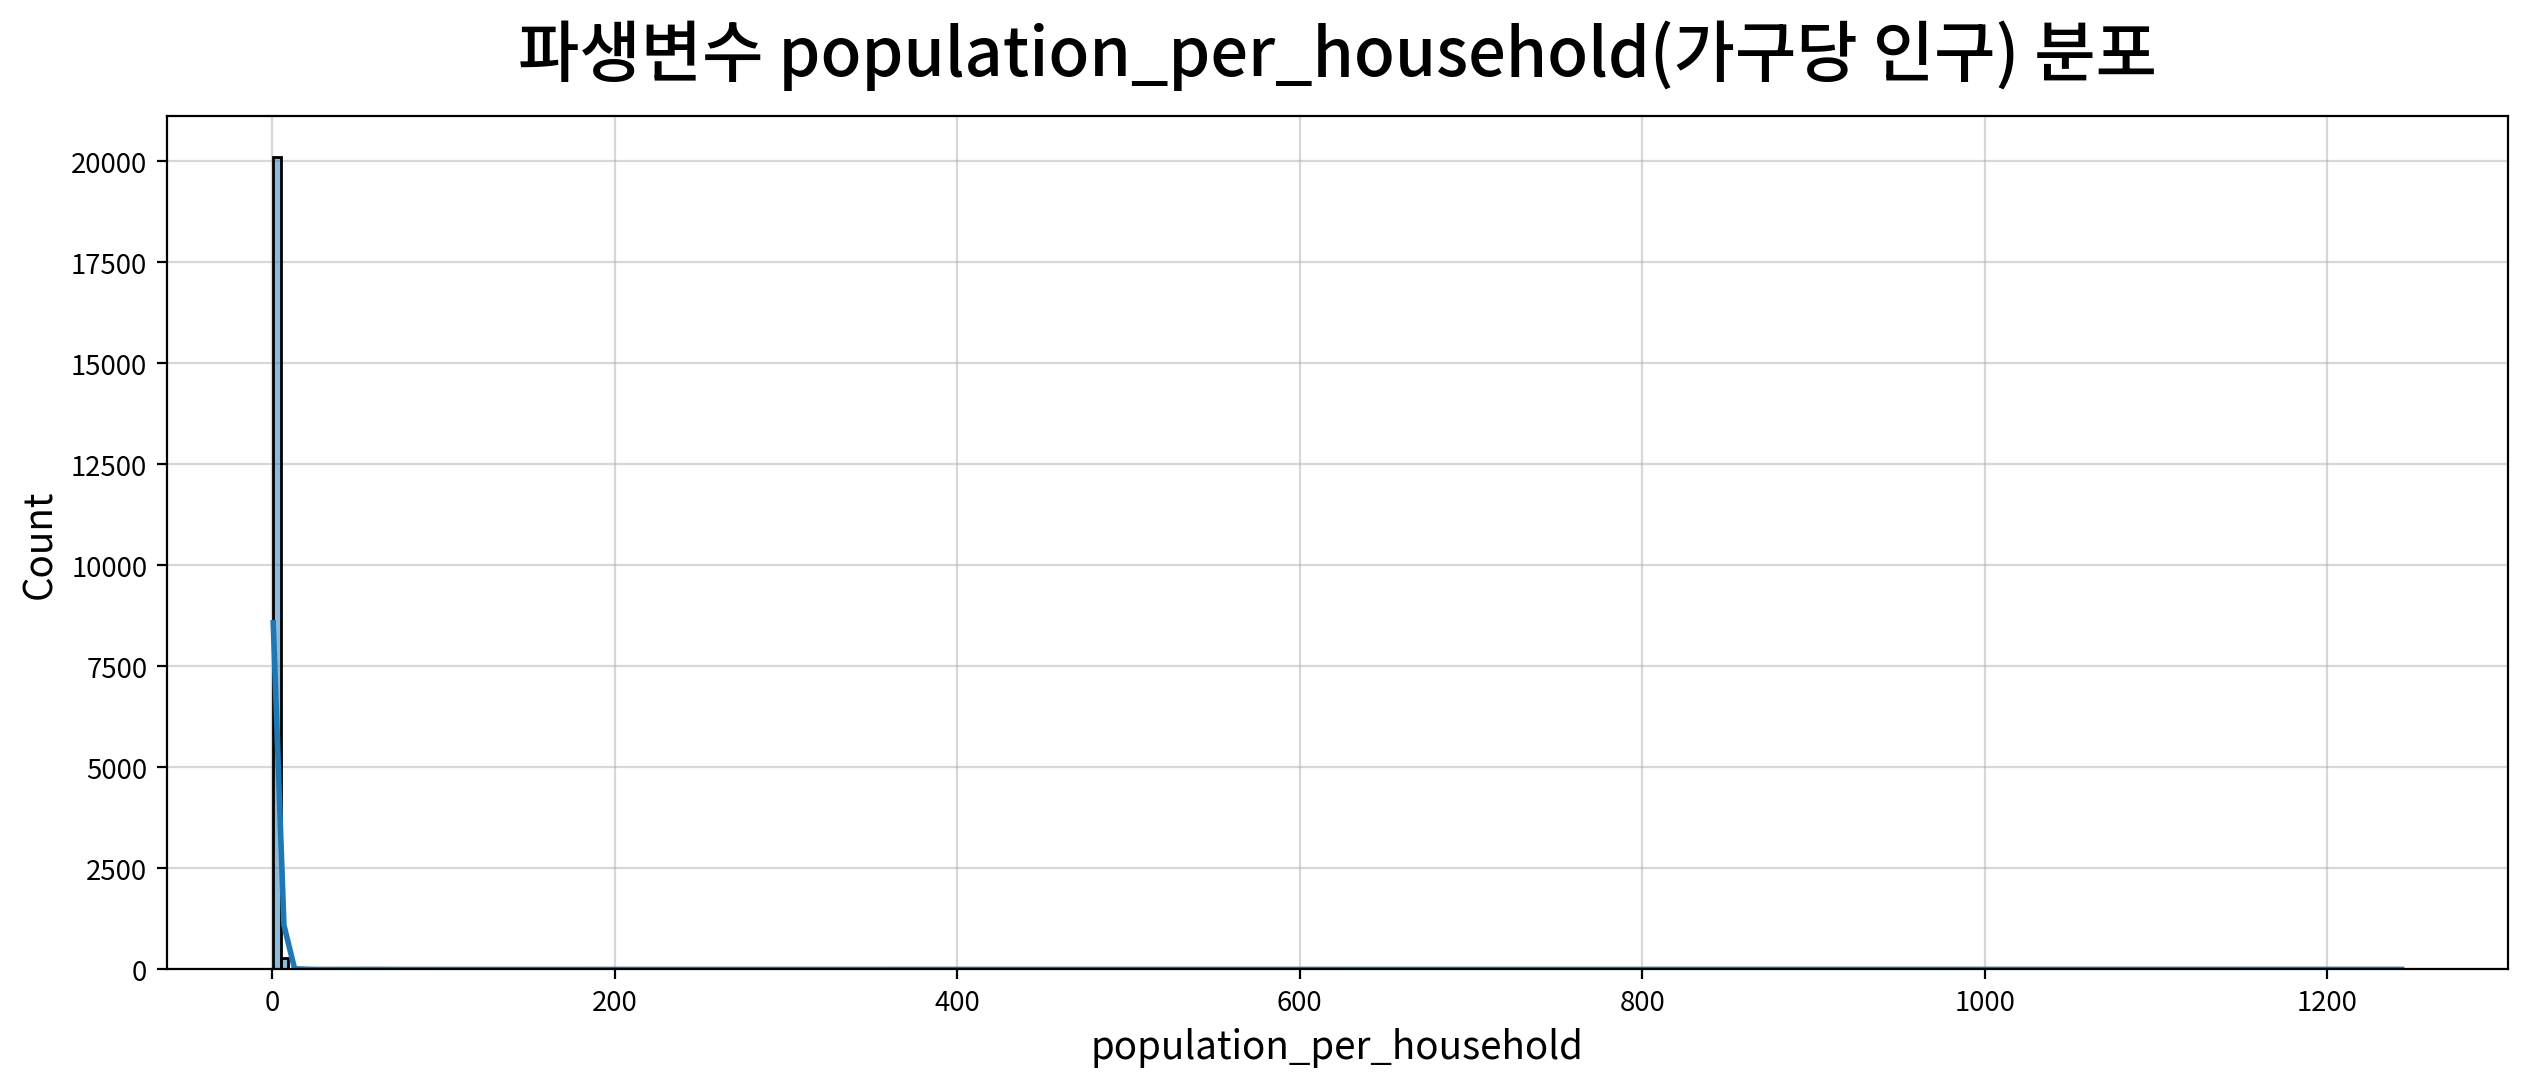

,population_per_household
count,20433.000
mean,3.072
std,10.438
min,0.692
25%,2.429
50%,2.818
75%,3.282
max,1243.333
rel_diff,0.090
rdiff_flag,similar


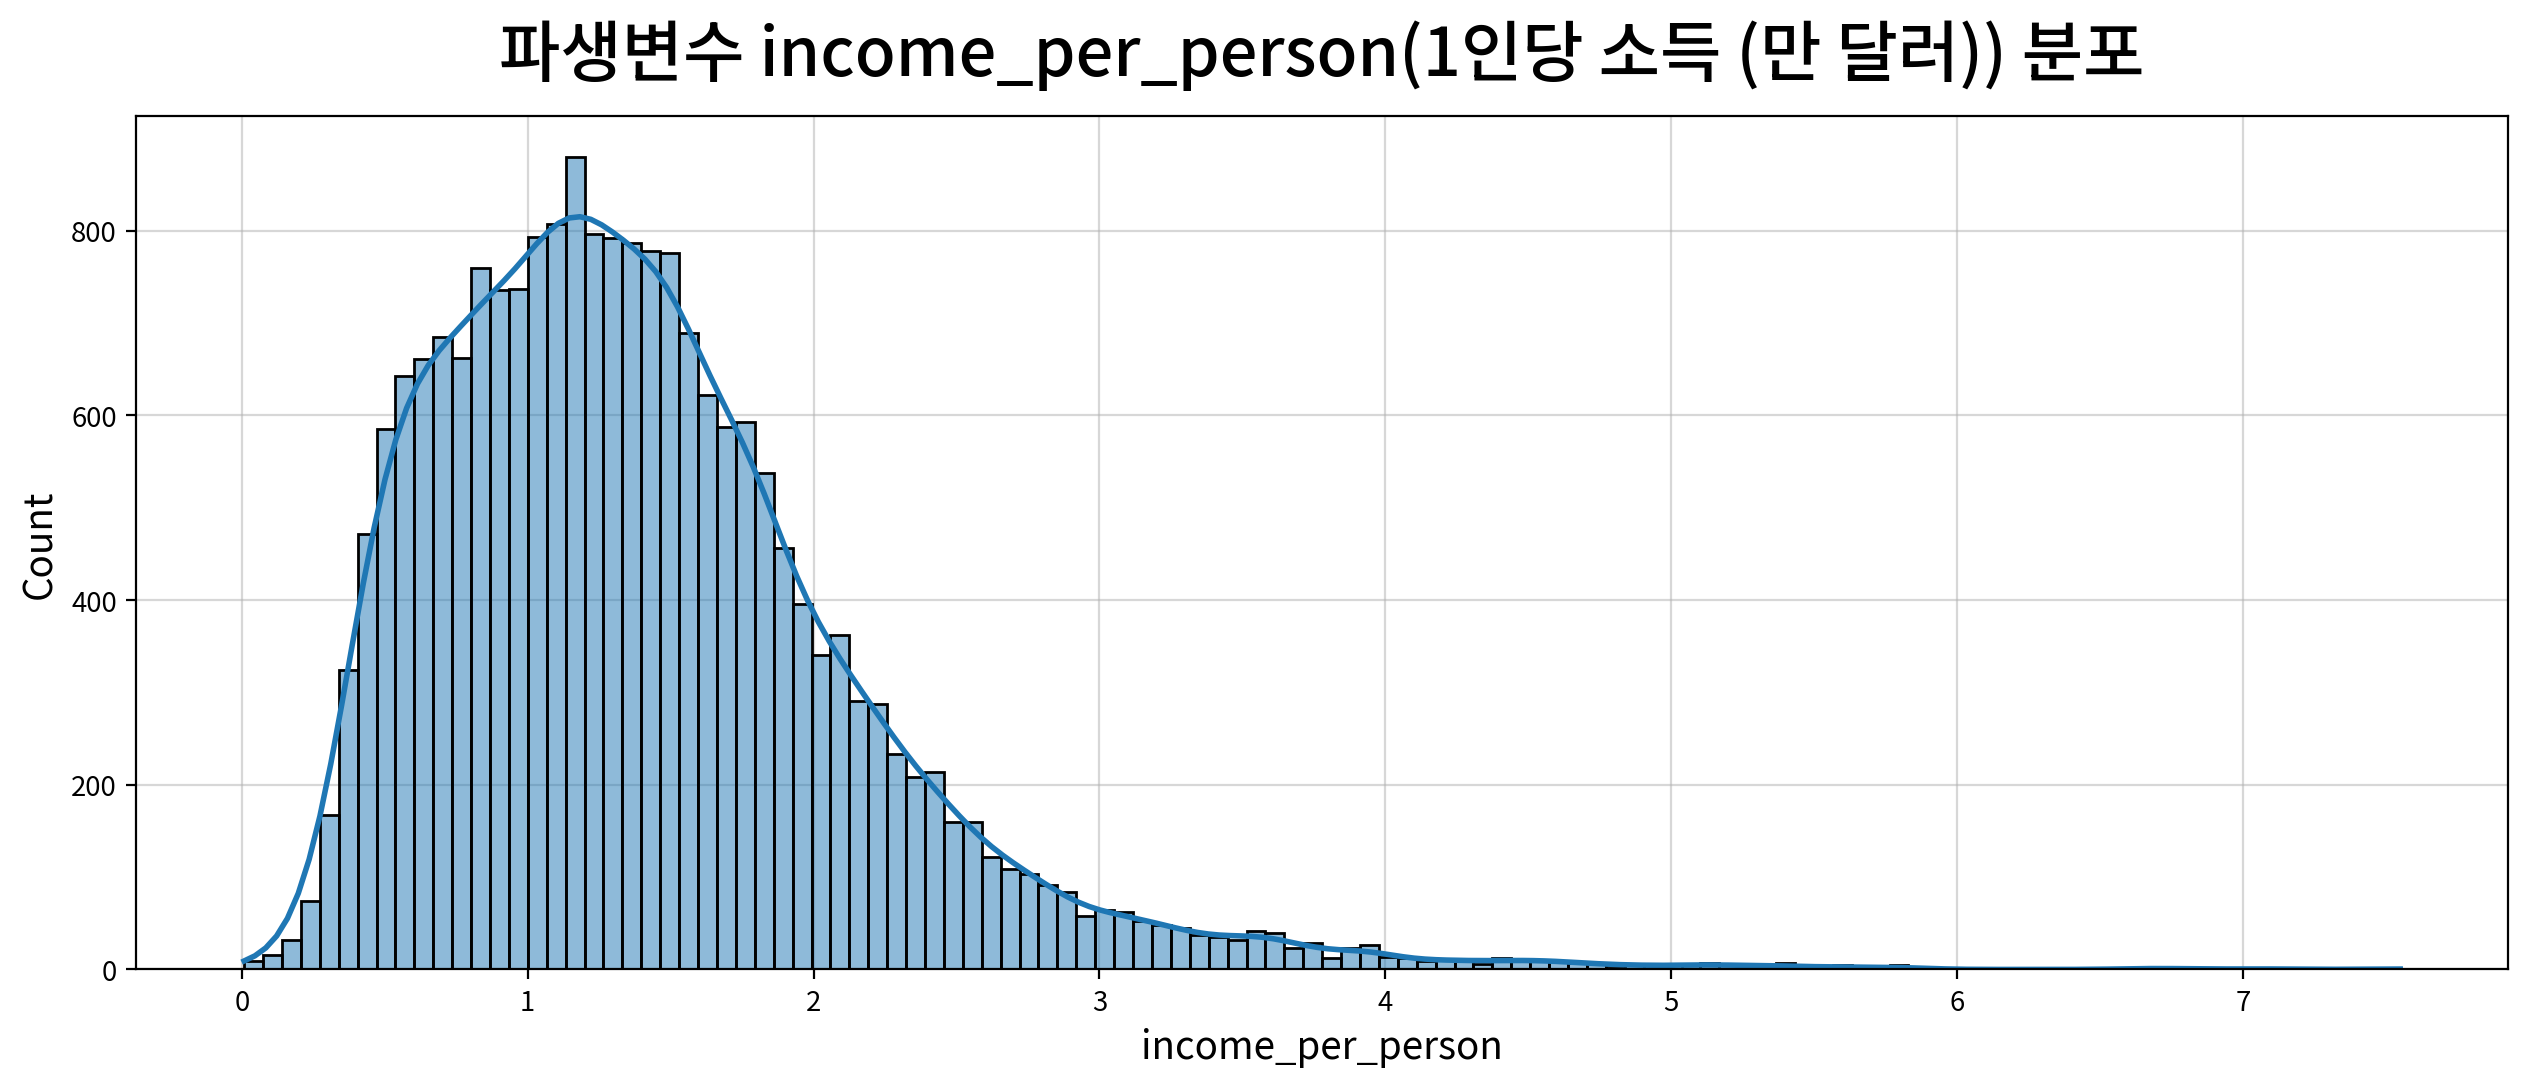

,income_per_person
count,20433.000
mean,1.409
std,0.755
min,0.008
25%,0.870
50%,1.296
75%,1.777
max,7.550
rel_diff,0.087
rdiff_flag,similar


In [23]:
for f in derived_continuous:
    # 히스토그램만 그리는 경우
    my_plot.histplot(data=df, x=f, kde=True, width=1280, height=560,
                    title=f"파생변수 {f}({column_means[f]}) 분포")

    display(derived_num_desc[derived_num_desc.index == f].T)

#### 인사이트

| 변수 | 분포 모양(왜도) | 첨도 | 이상치 | 판단·조치 |
|---|---|---|---|---|
| `income_per_person` | 중간 우편향 (+1.46) | 4.2 | 616건 (3.0%) | 5종 중 가장 온건. 원본 `median_income`(+1.65)보다 개선 |
| `bedrooms_per_room` | 우편향 (+2.25) | 14.4 | 582건 (2.8%) | 분자·분모가 같은 방향으로 움직여 비율이 안정 |
| `rooms_per_person` | 극단 우편향 (+17.76) | 597.9 | 399건 (2.0%) | 로그 변환 필요 |
| `rooms_per_household` | 극단 우편향 (+20.68) | 875.7 | 508건 (2.5%) | 로그 변환 필요 |
| `population_per_household` | 최악 (+97.16) | 10,545.2 | 709건 (3.5%) | 로그 변환 필요. 원인 확인 요망 |

### 5. 단변량 분석 (범주형 파생변수)

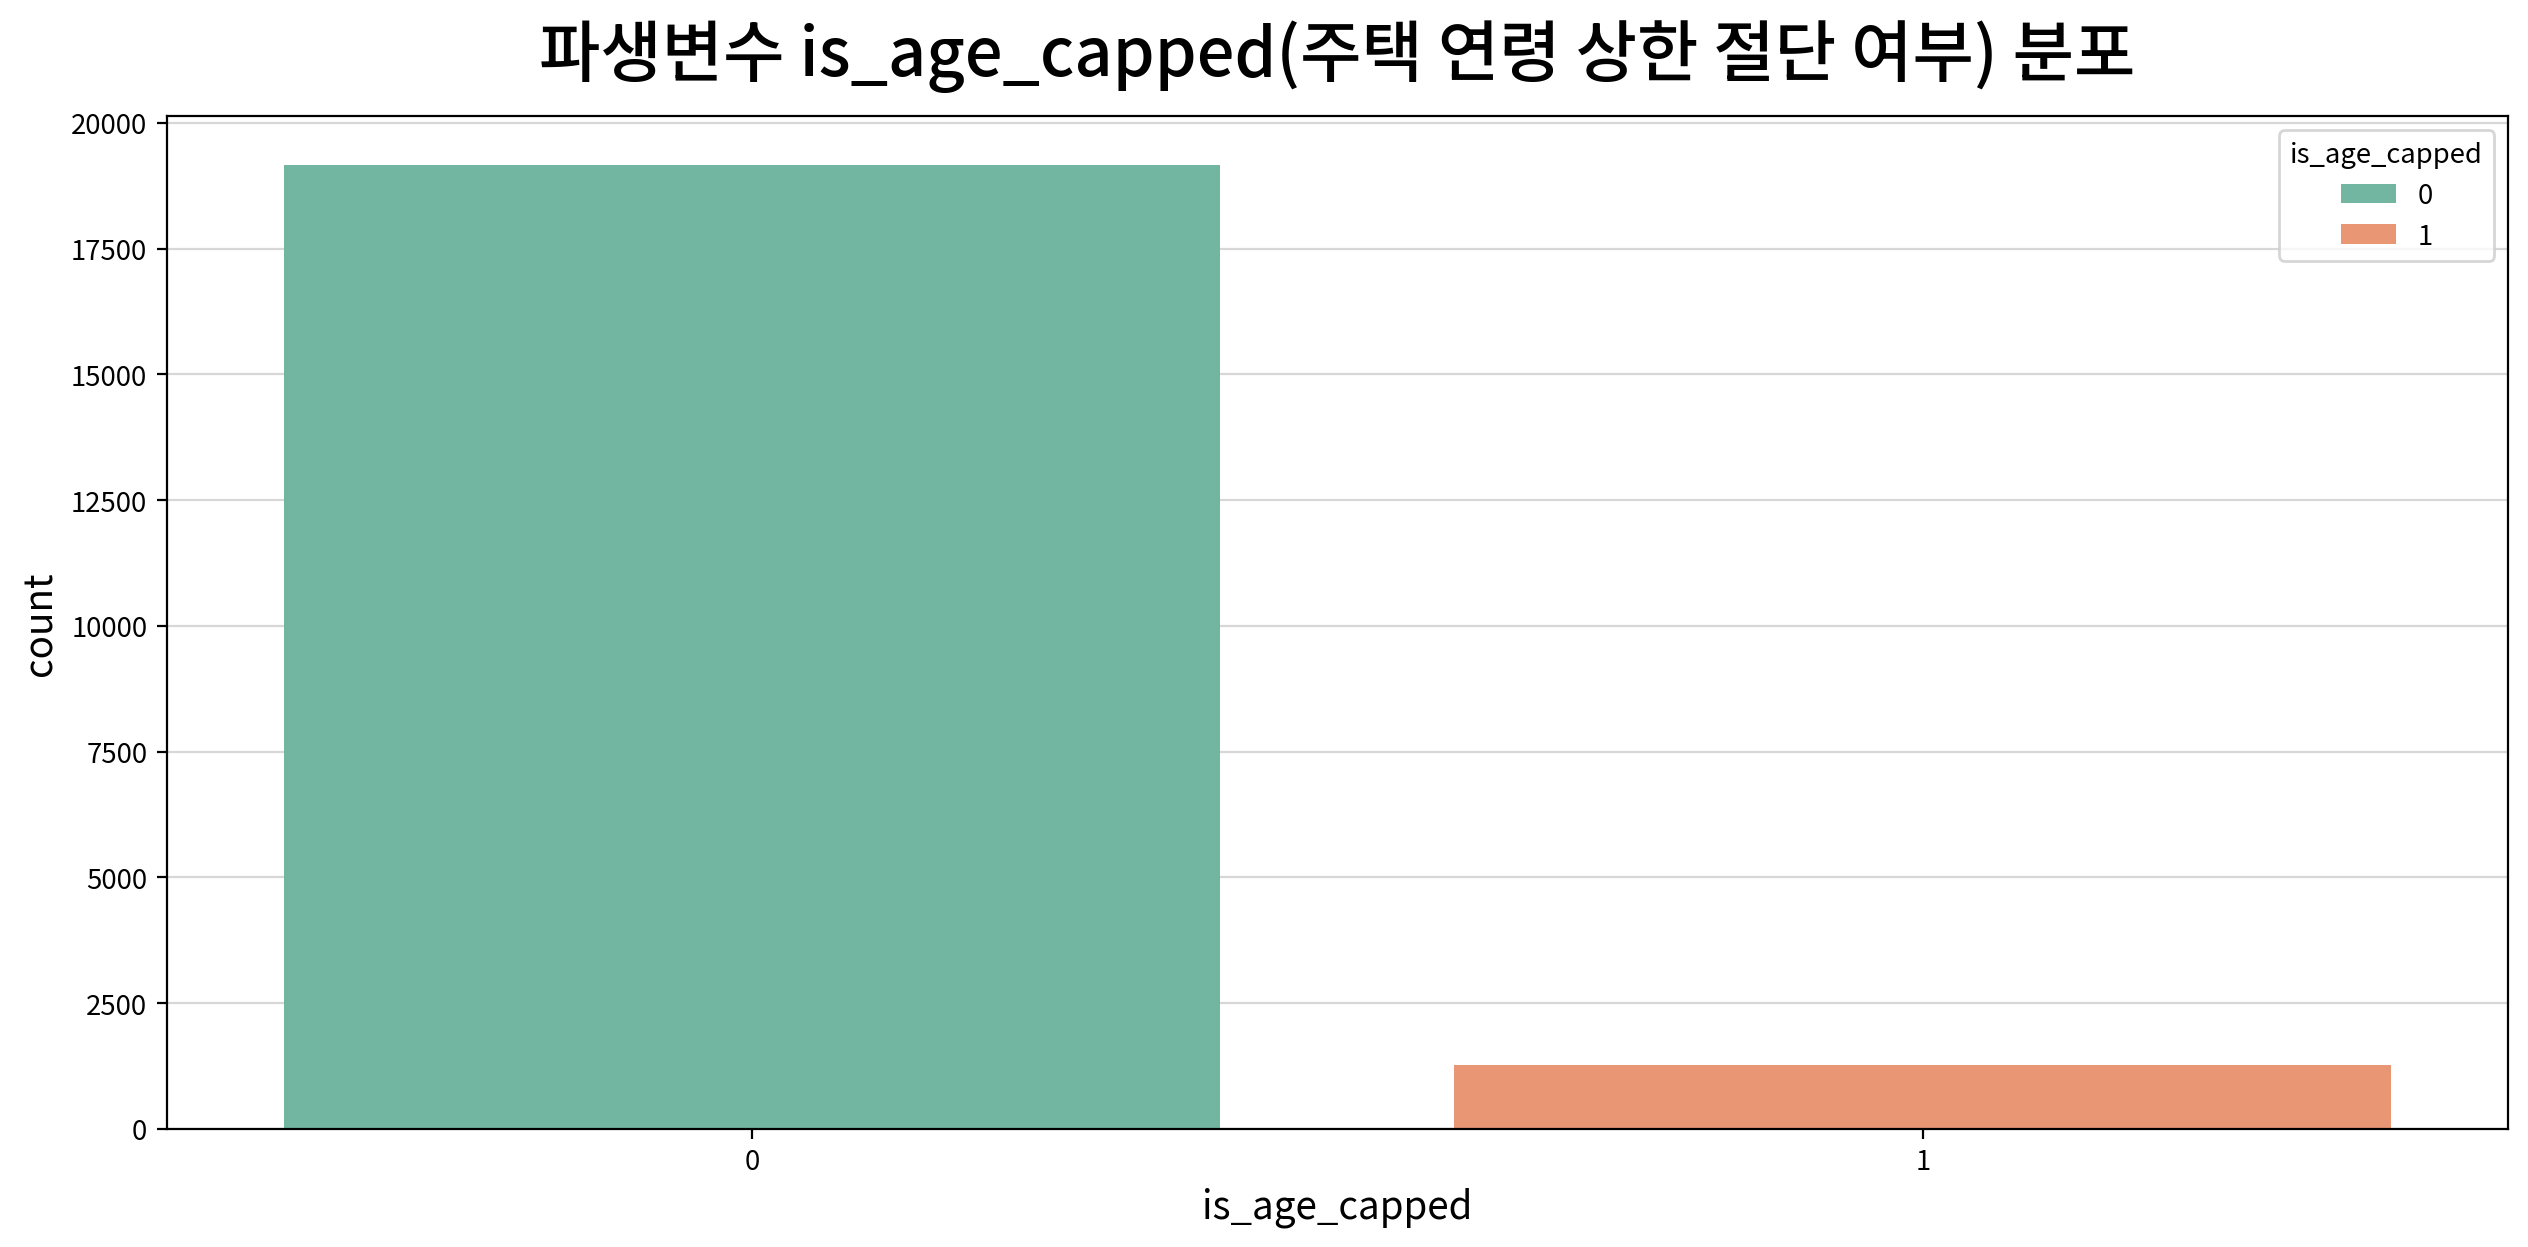

,count,unique,top,freq
is_age_capped,20433,2,0,19168


,빈도,비율
is_age_capped,,
0,19168,0.938
1,1265,0.062


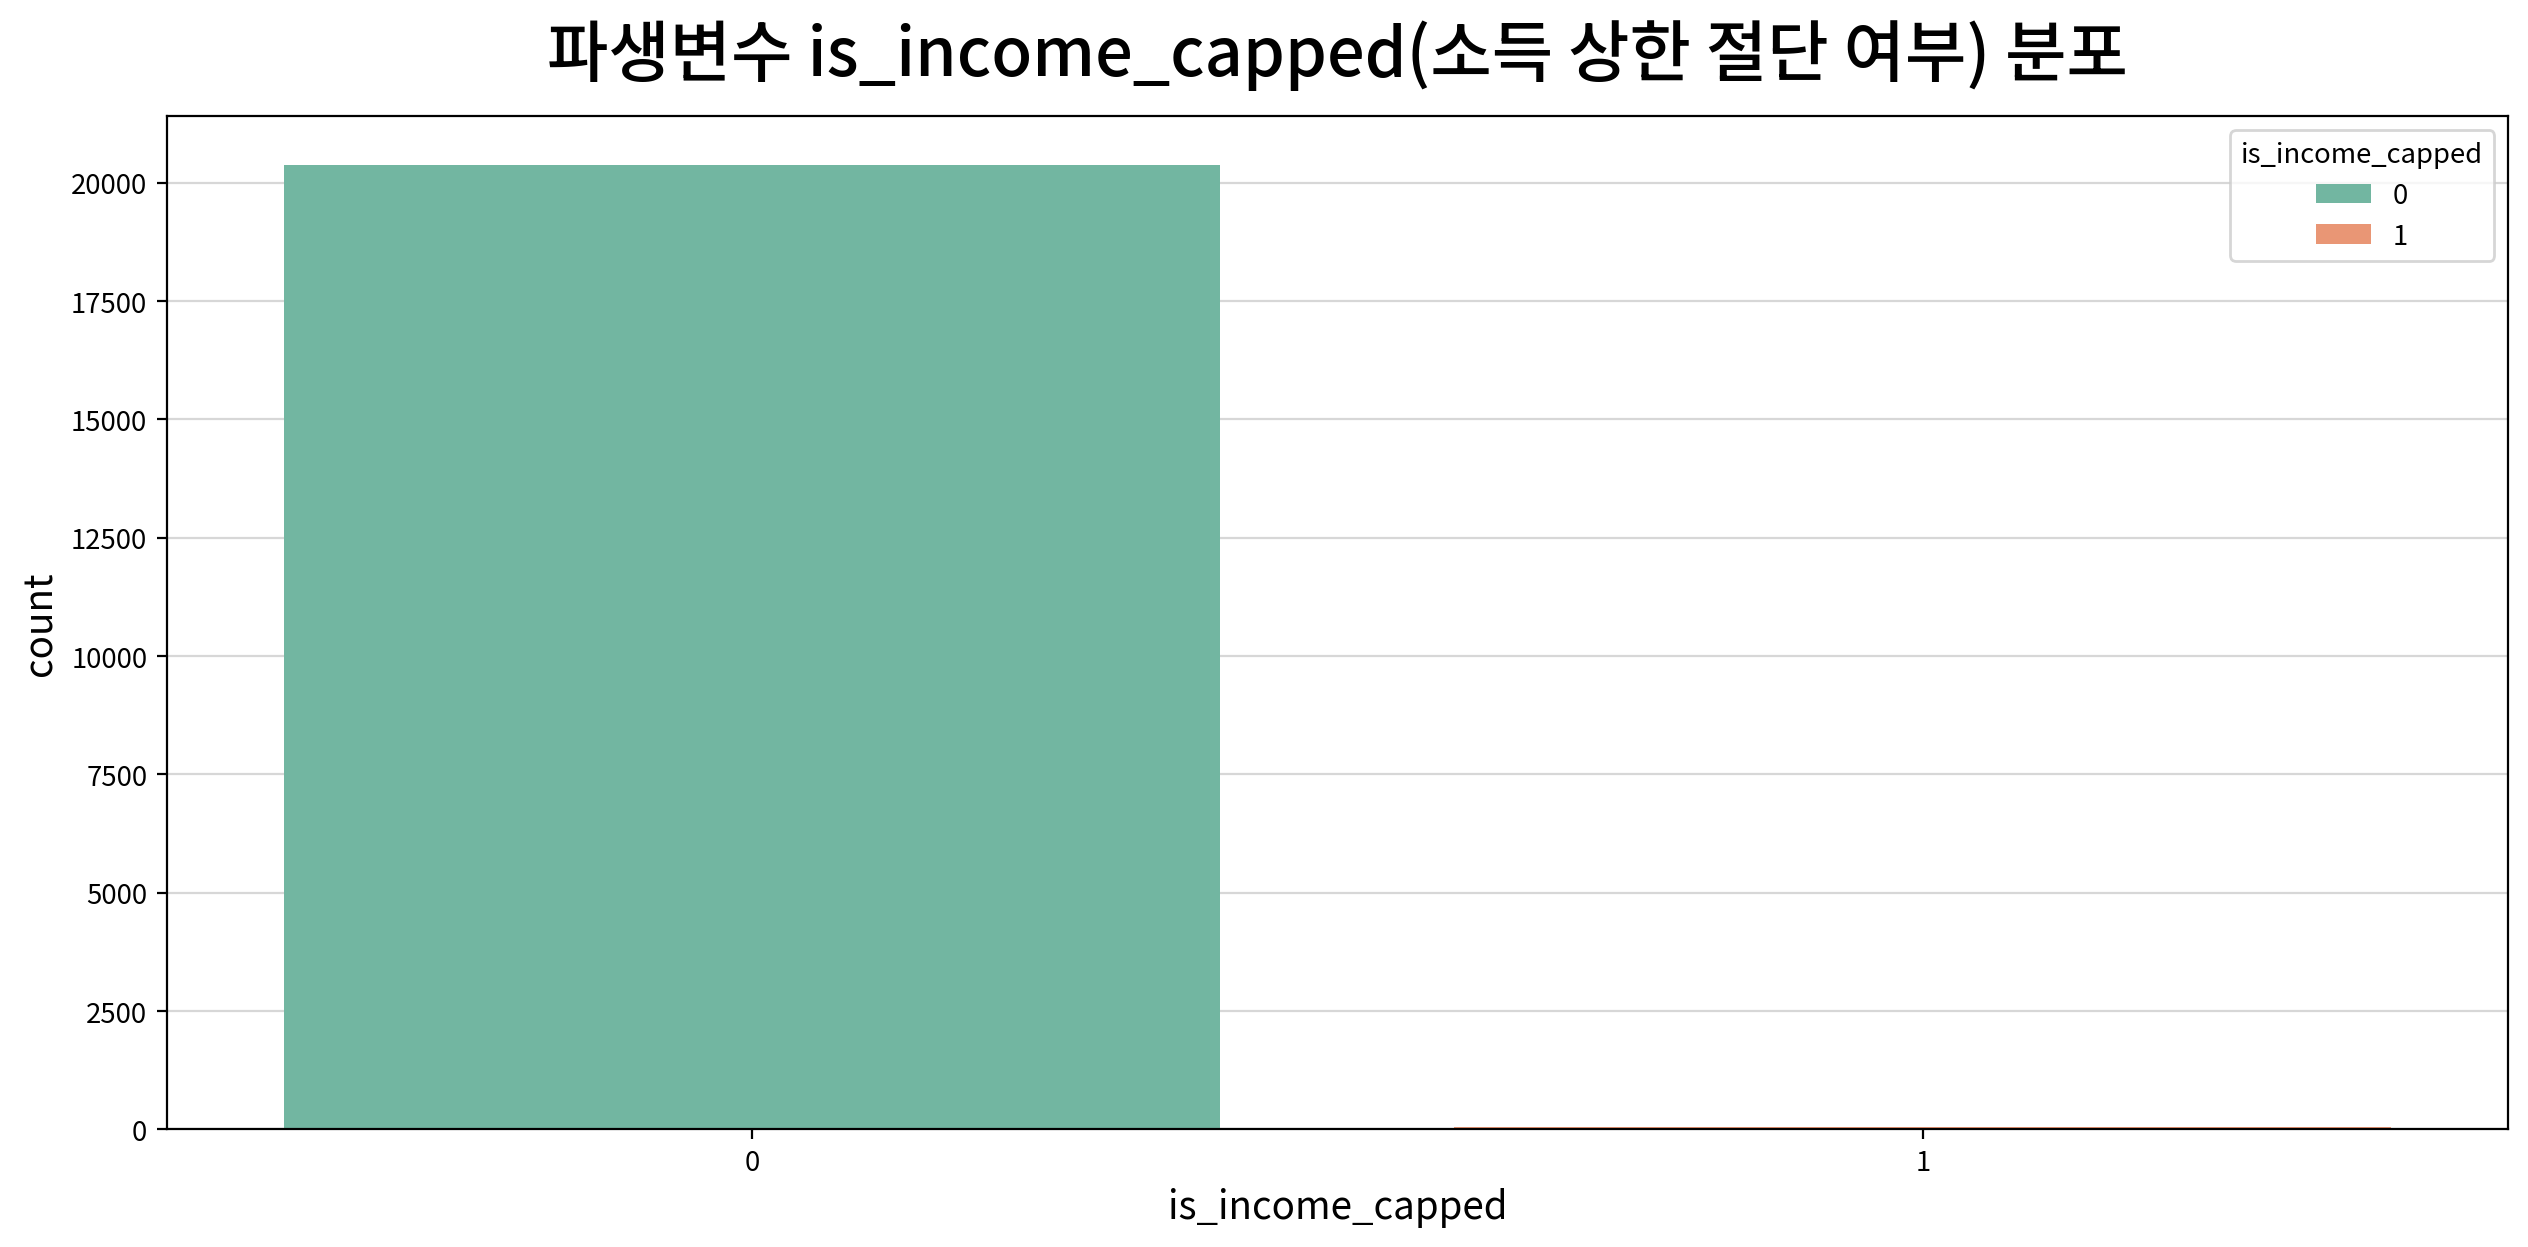

,count,unique,top,freq
is_income_capped,20433,2,0,20383


,빈도,비율
is_income_capped,,
0,20383,0.998
1,50,0.002


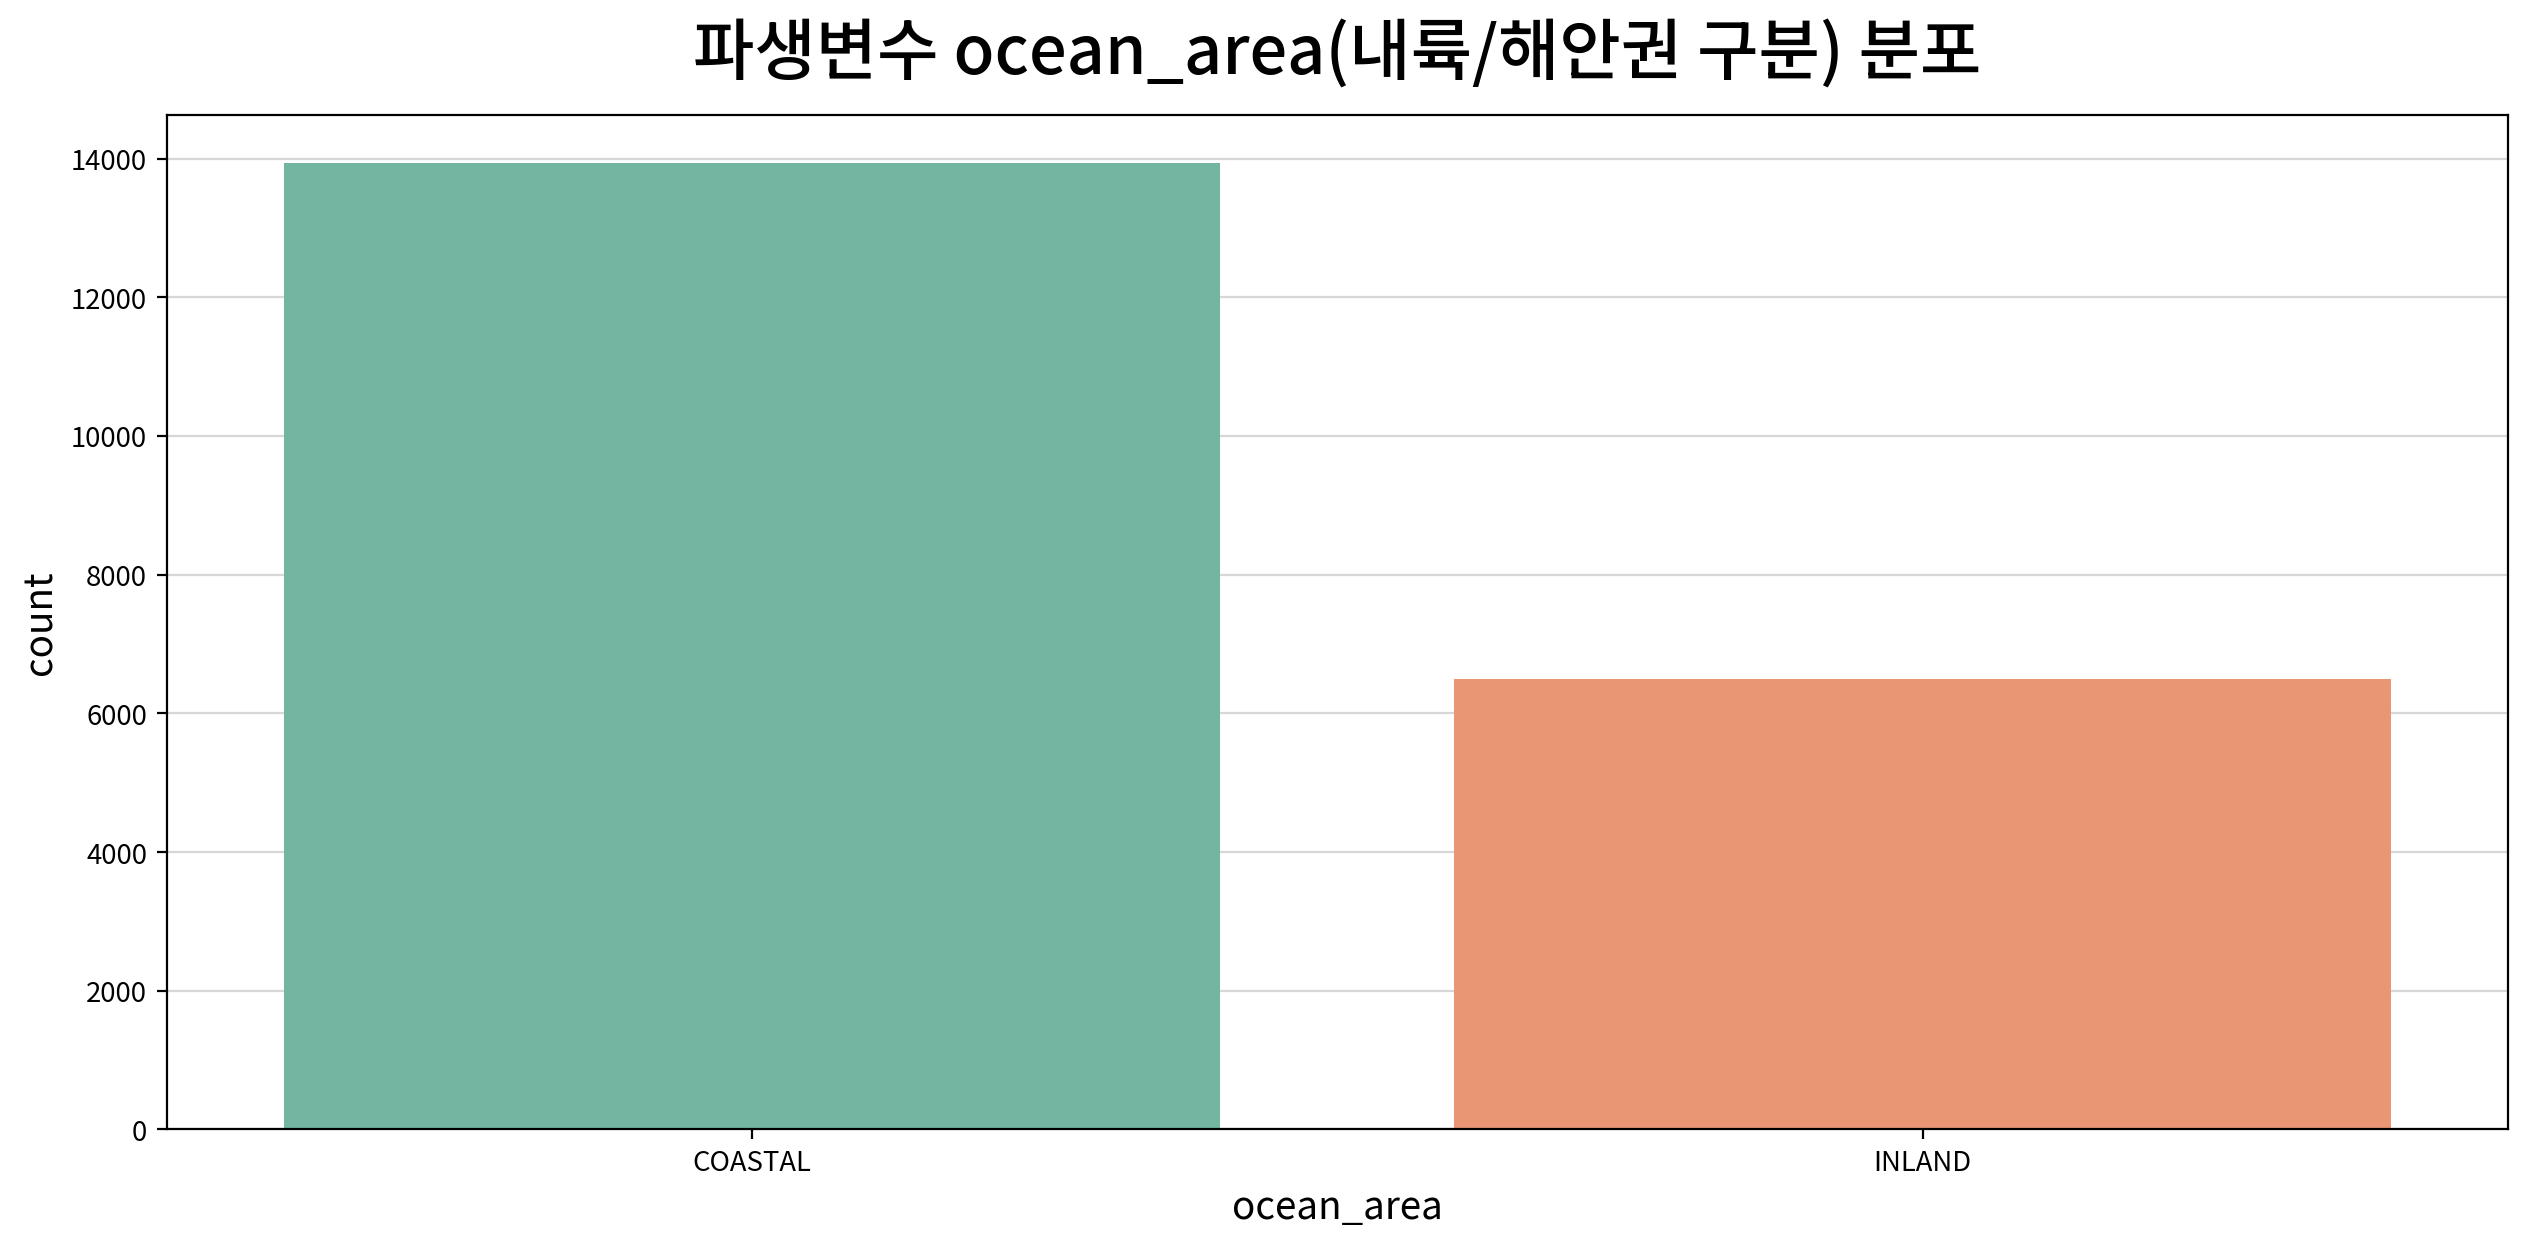

,count,unique,top,freq
ocean_area,20433,2,COASTAL,13937


,빈도,비율
ocean_area,,
COASTAL,13937,0.682
INLAND,6496,0.318


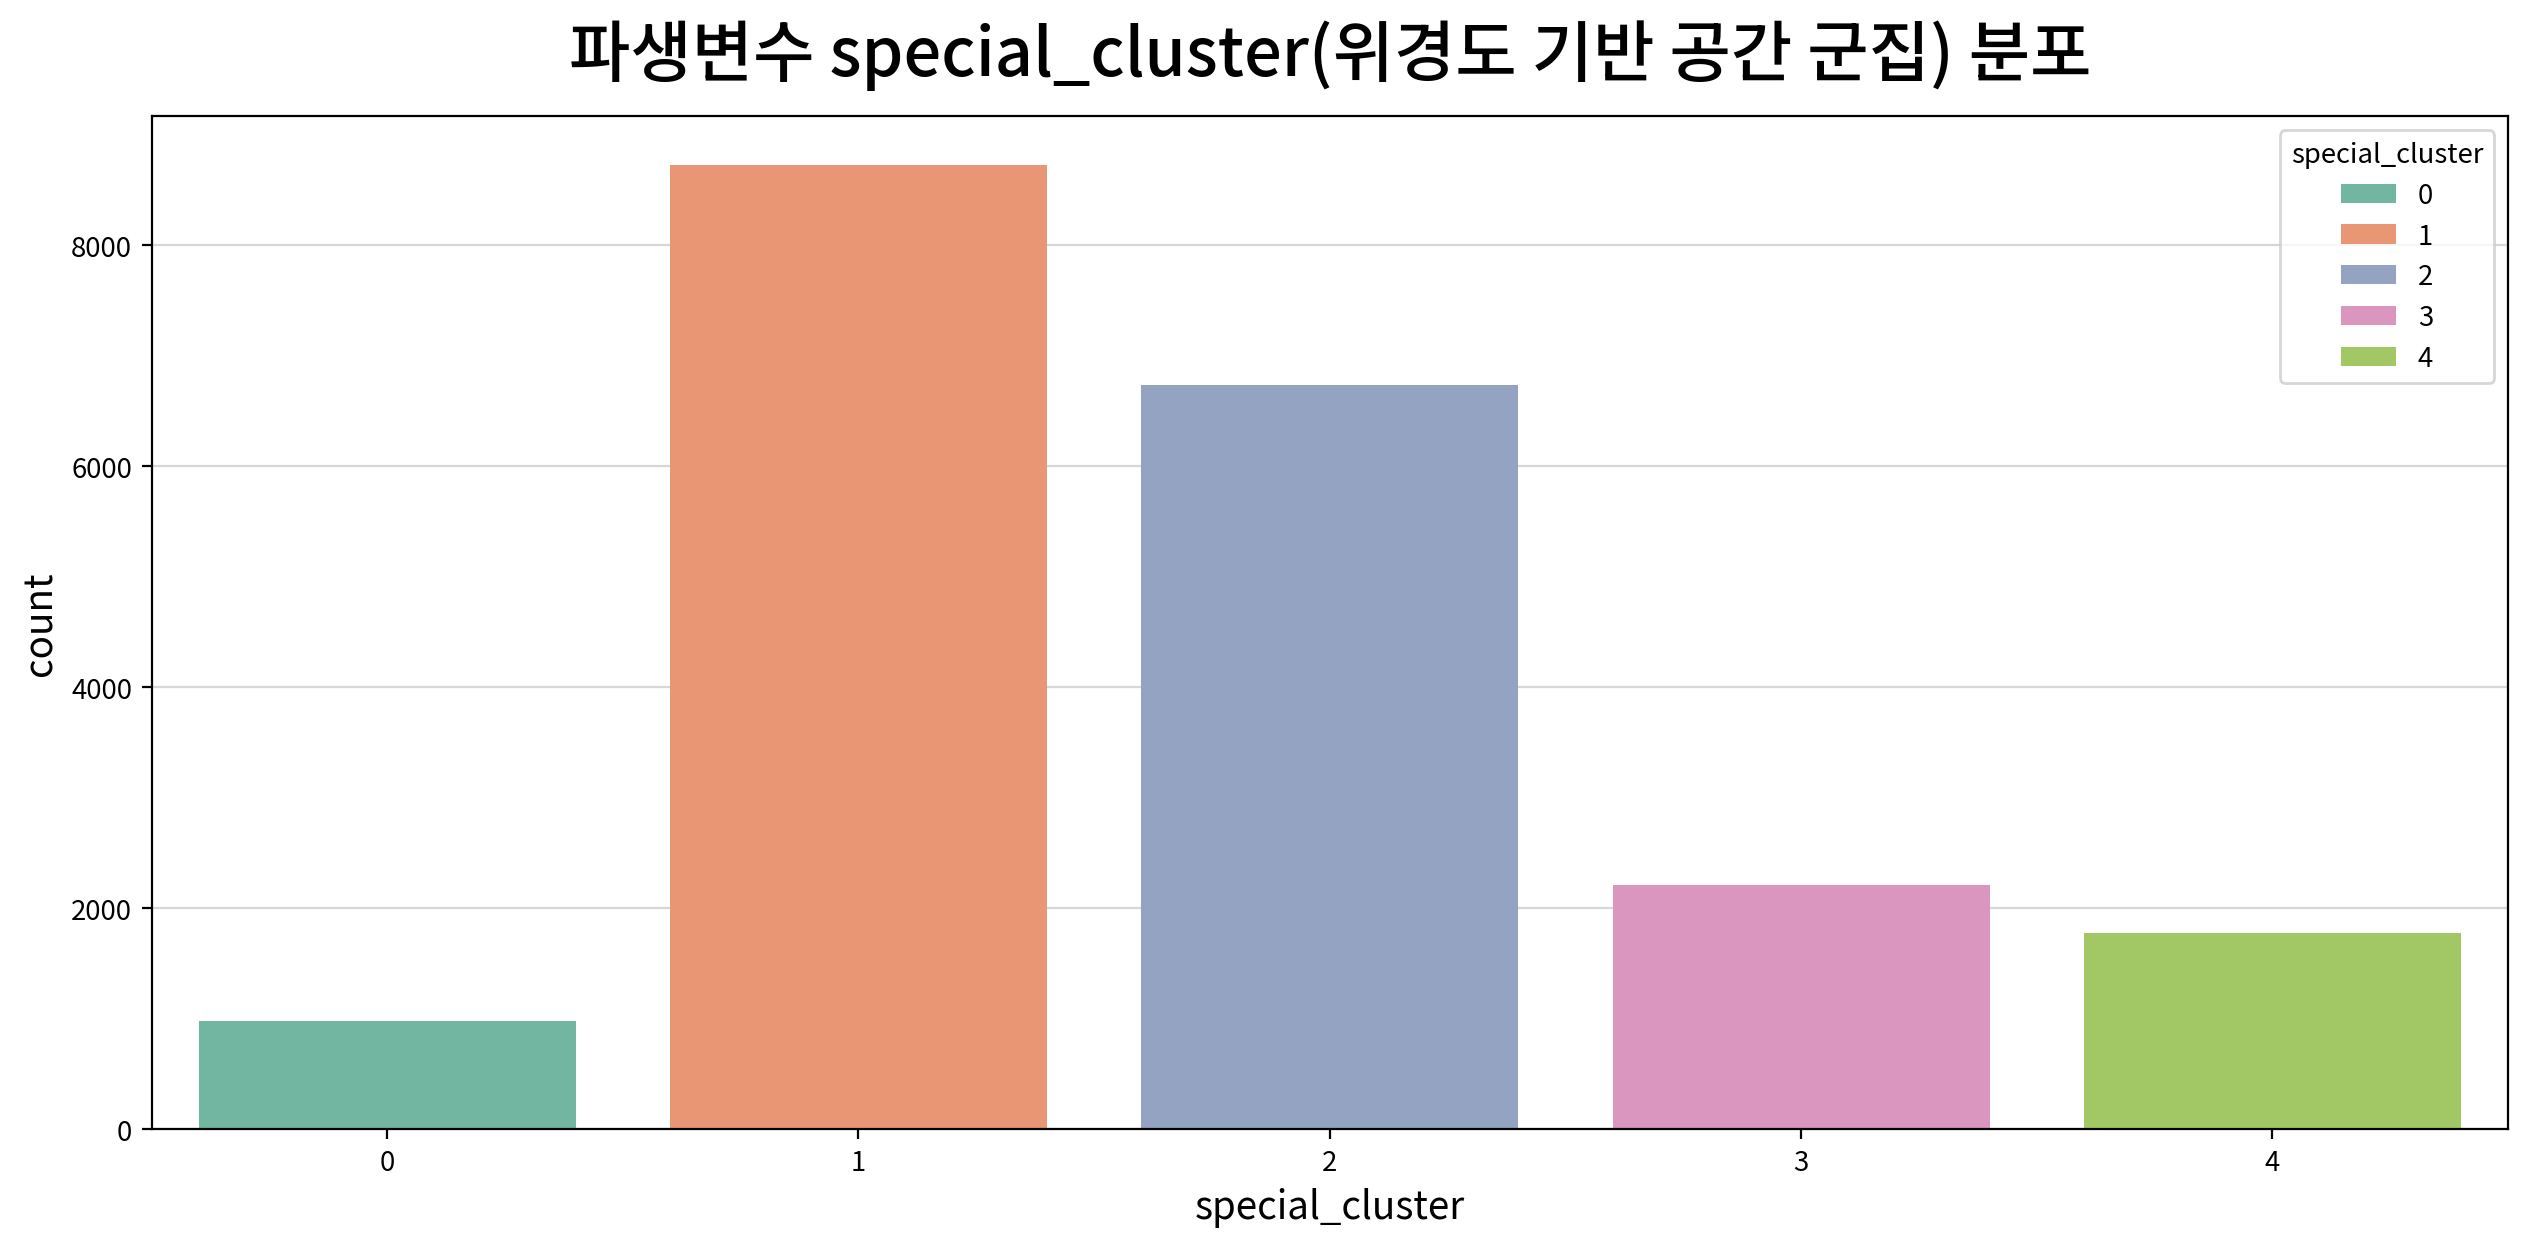

,count,unique,top,freq
special_cluster,20433,5,1,8729


,빈도,비율
special_cluster,,
1,8729,0.427
2,6736,0.330
3,2211,0.108
4,1778,0.087
0,979,0.048


In [24]:
for n in derived_nominal:
    # 범주형 분포는 카운트 플롯으로 처리한다.
    my_plot.countplot(data=df, x=n, hue=n, palette="Set2",
                      title=f"파생변수 {n}({column_means[n]}) 분포")

    # 범주형 기술통계량
    display(derived_cat_desc[[n]].T)

    # 추가적으로 빈도표 생성
    freq = df[n].value_counts().rename("빈도").to_frame()
    freq["비율"] = df[n].value_counts(normalize=True)
    display(freq)

#### 인사이트

| 변수 | 범주 수 | 최빈 범주(비율) | 최소 범주(비율) | 균형 여부 | 판단·조치 |
|---|---|---|---|---|---|
| `ocean_area` | 2 | COASTAL 13,937 (68.2%) | INLAND : 6,496건 (31.8%) | 양호 | 병합 목적 달성 |
| `is_age_capped` | 2 | 0 : 19,168 (93.8%) | 1 : 1,265건 (6.2%) | 불균형 | 검정에 충분 |
| `is_income_capped` | 2 | 0 : 20,383 (99.8%) | 1 : 50건 (0.2%) | 극심한 불균형 | 심한 불균형. 채택하지 않는 것을 고려 |
| `special_cluster` | 5 | 1 : 8729 (42.7%) | 0 : 979건 (0.4%) | 극심한 불균형 | 주의 |

- **`ocean_area`의 병합은 의도대로 작동했다.** 병합 전 `ocean_proximity`는 최빈 44.2%\~최소 0.02%(`ISLAND` 5건)의 5범주였다. 2범주로 줄인 뒤 최소 범주가 6,496건(31.8%)이 되어 불균형 문제가 사라졌다.
- **`is_income_capped` 50건(0.2%)은 EDA의 `ISLAND` 5건과 같은 성격의 문제다.** 표본이 적으면 그 범주의 추정치가 불안정해진다. `ISLAND`는 병합으로 해결했지만 이 플래그는 병합할 대상이 없으므로, 투입 여부를 별도로 판단해야 한다(`#03-6`에서 다시 본다).
- `is_age_capped`는 1,265건(6.2%)으로 소수 범주지만 검정에는 충분하다.

### 6. 상관분석 (x: 연속형 파생변수 → y: 연속형 종속변수)

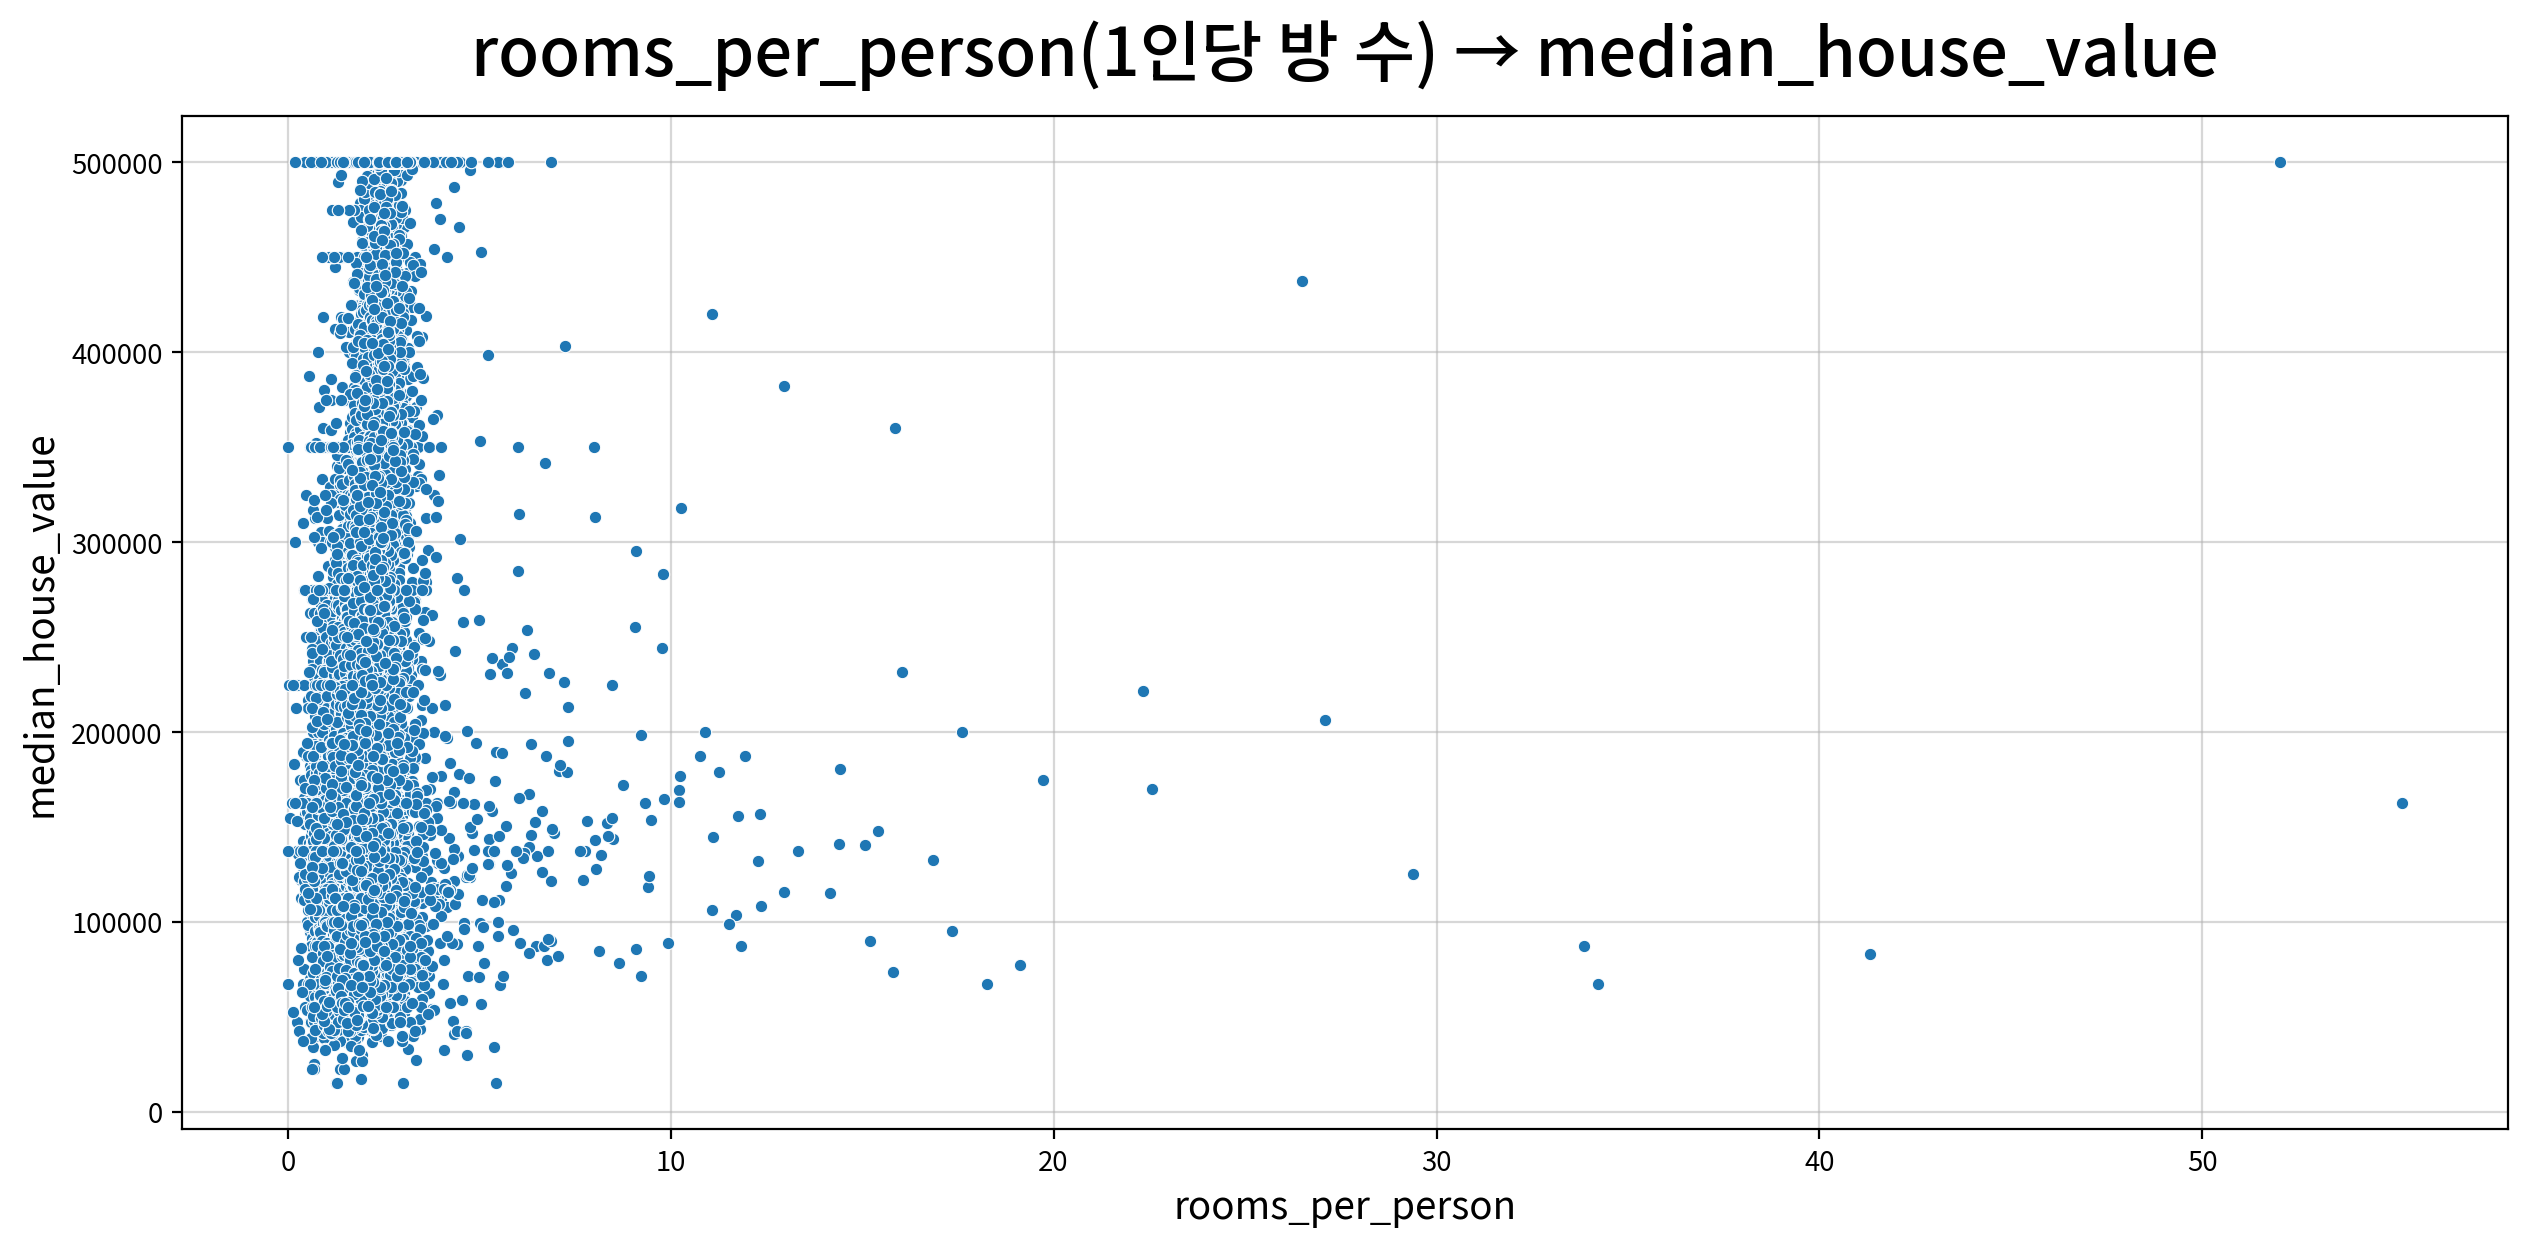

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
rooms_per_person,median_house_value,Spearman,0.400,0.000,Moderate,True,False,False,False,True,True


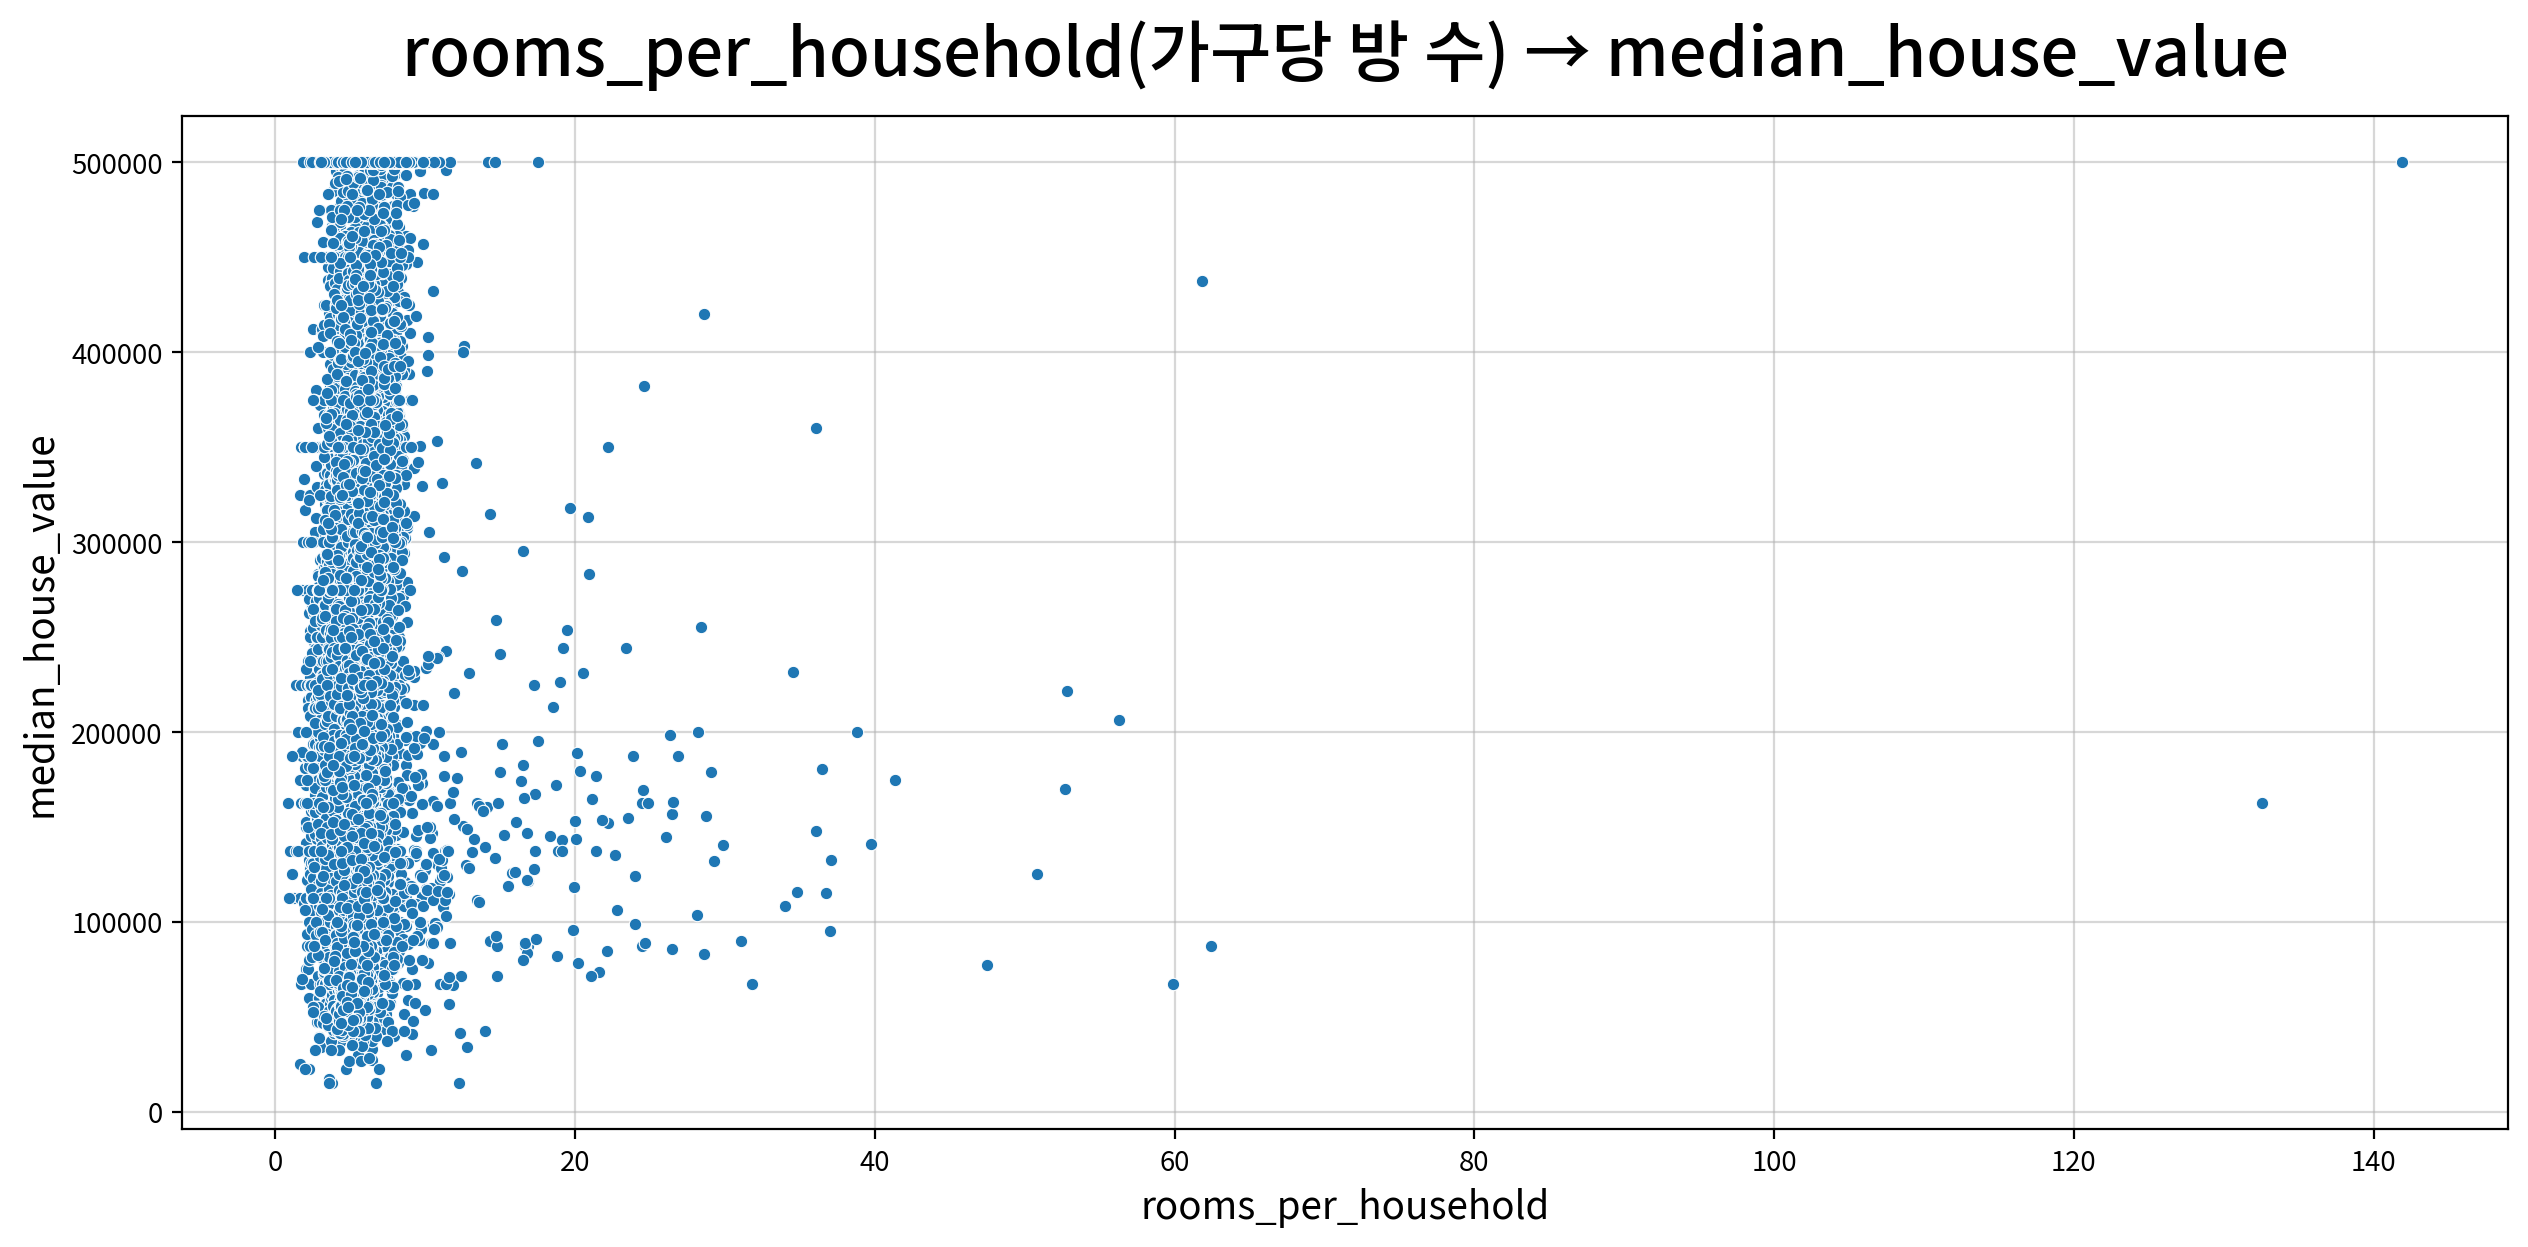

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
rooms_per_household,median_house_value,Spearman,0.263,0.000,Weak,True,False,False,False,True,True


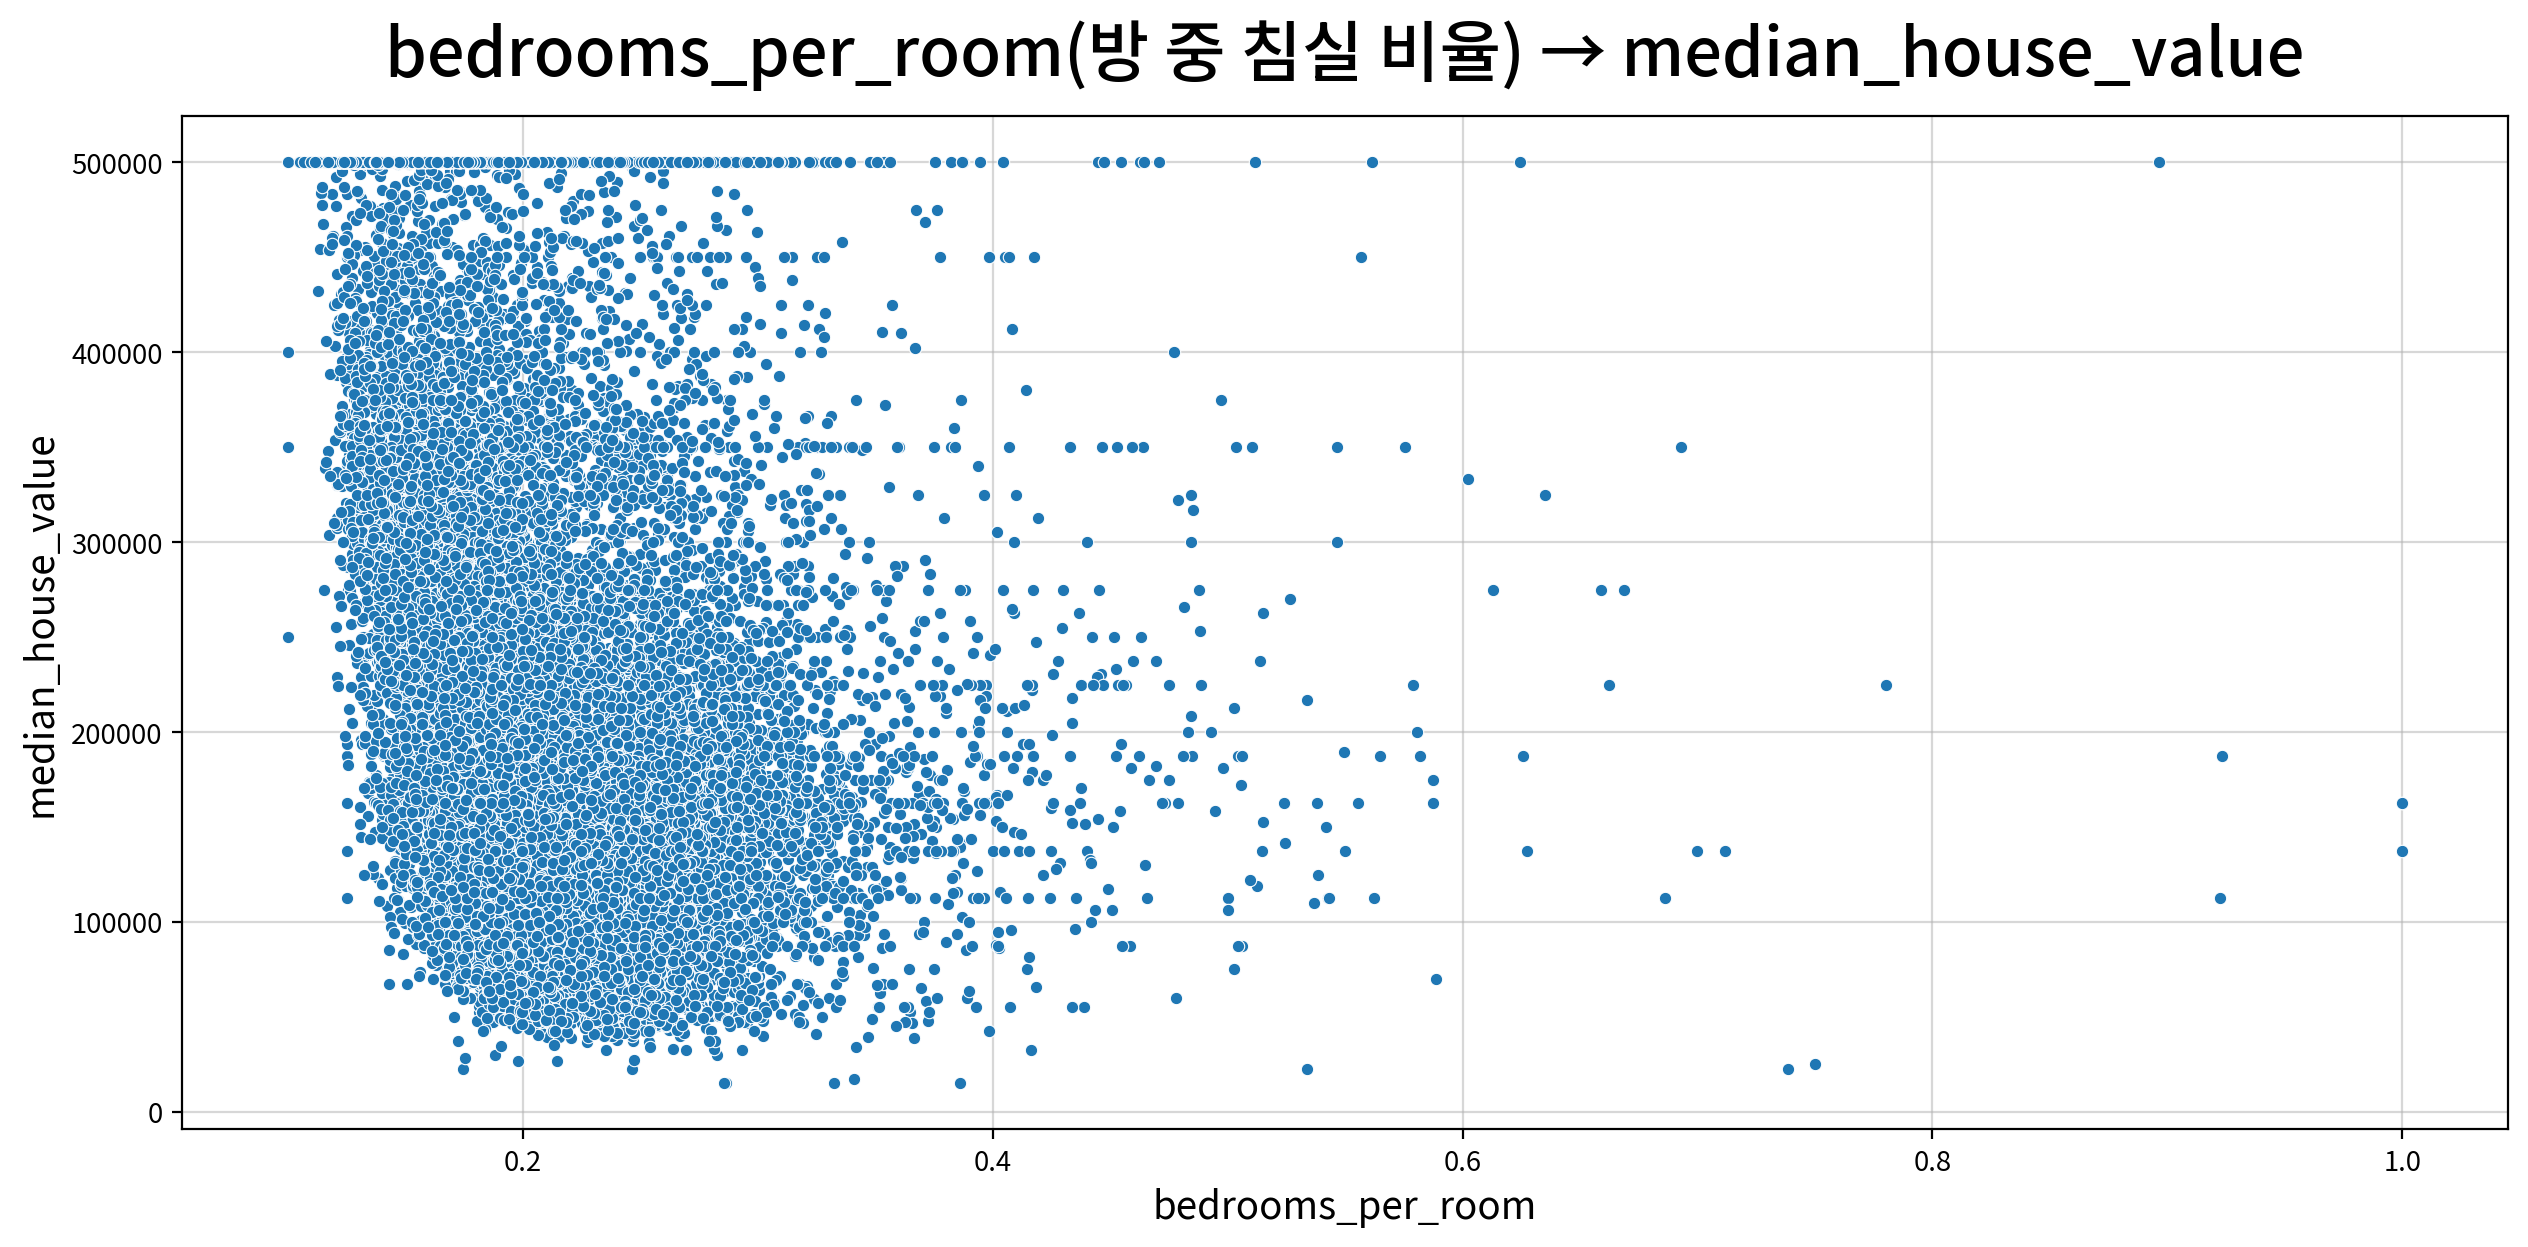

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
bedrooms_per_room,median_house_value,Spearman,-0.332,0.000,Moderate,True,False,False,False,False,True


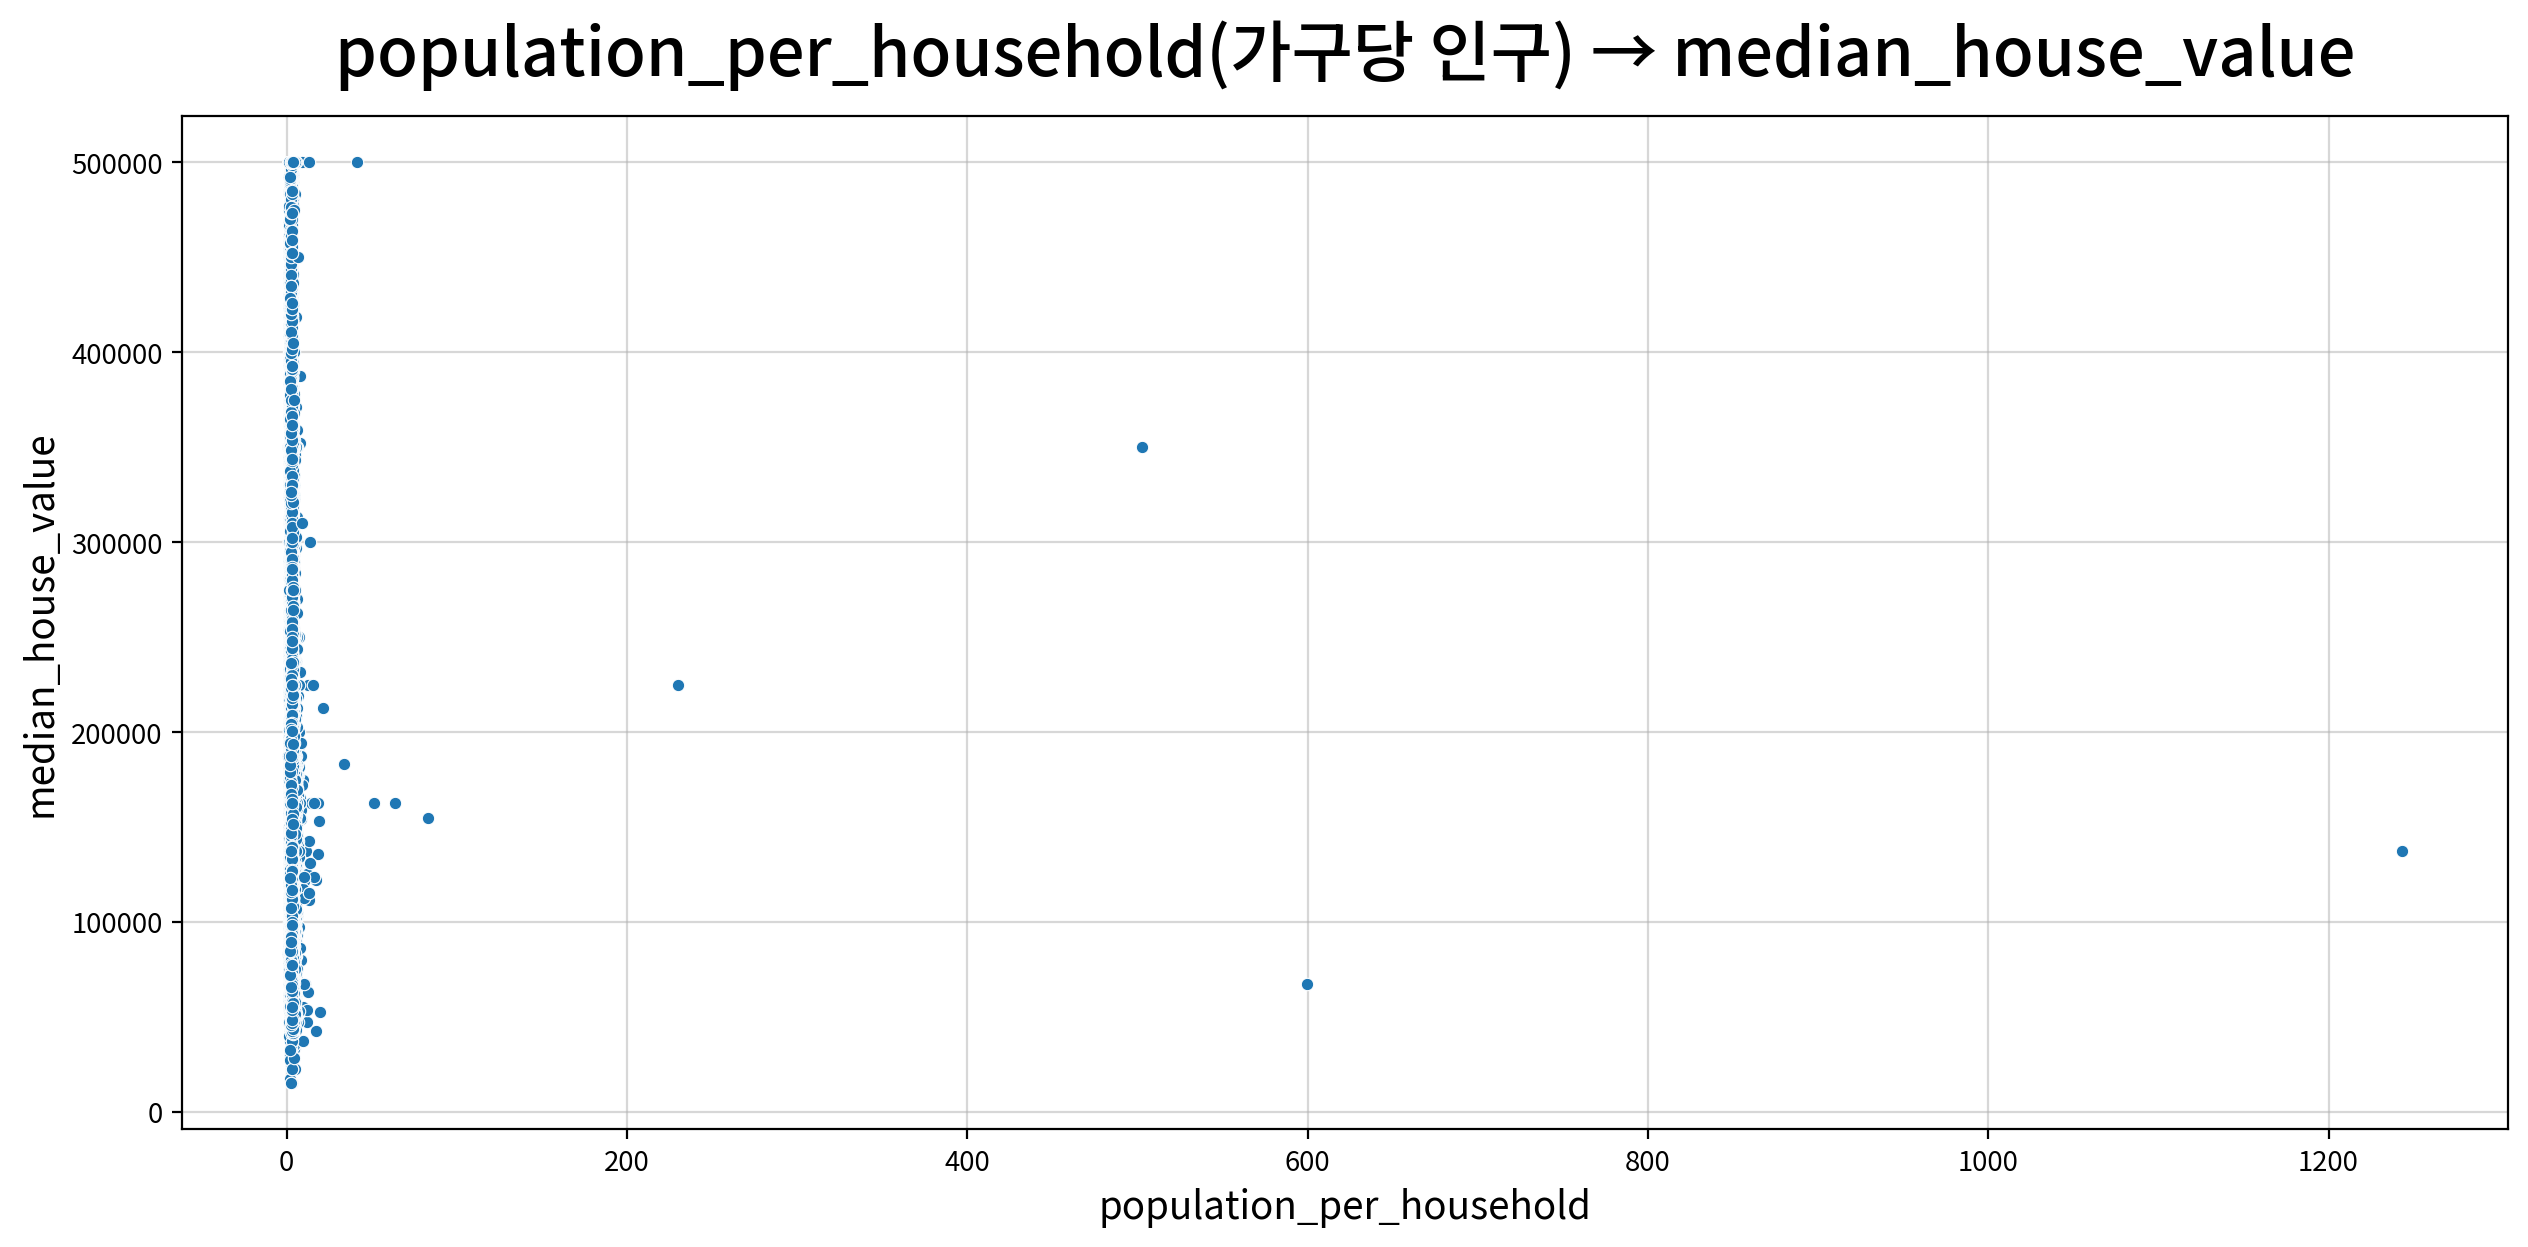

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
population_per_household,median_house_value,Spearman,-0.256,0.000,Weak,True,False,False,False,True,True


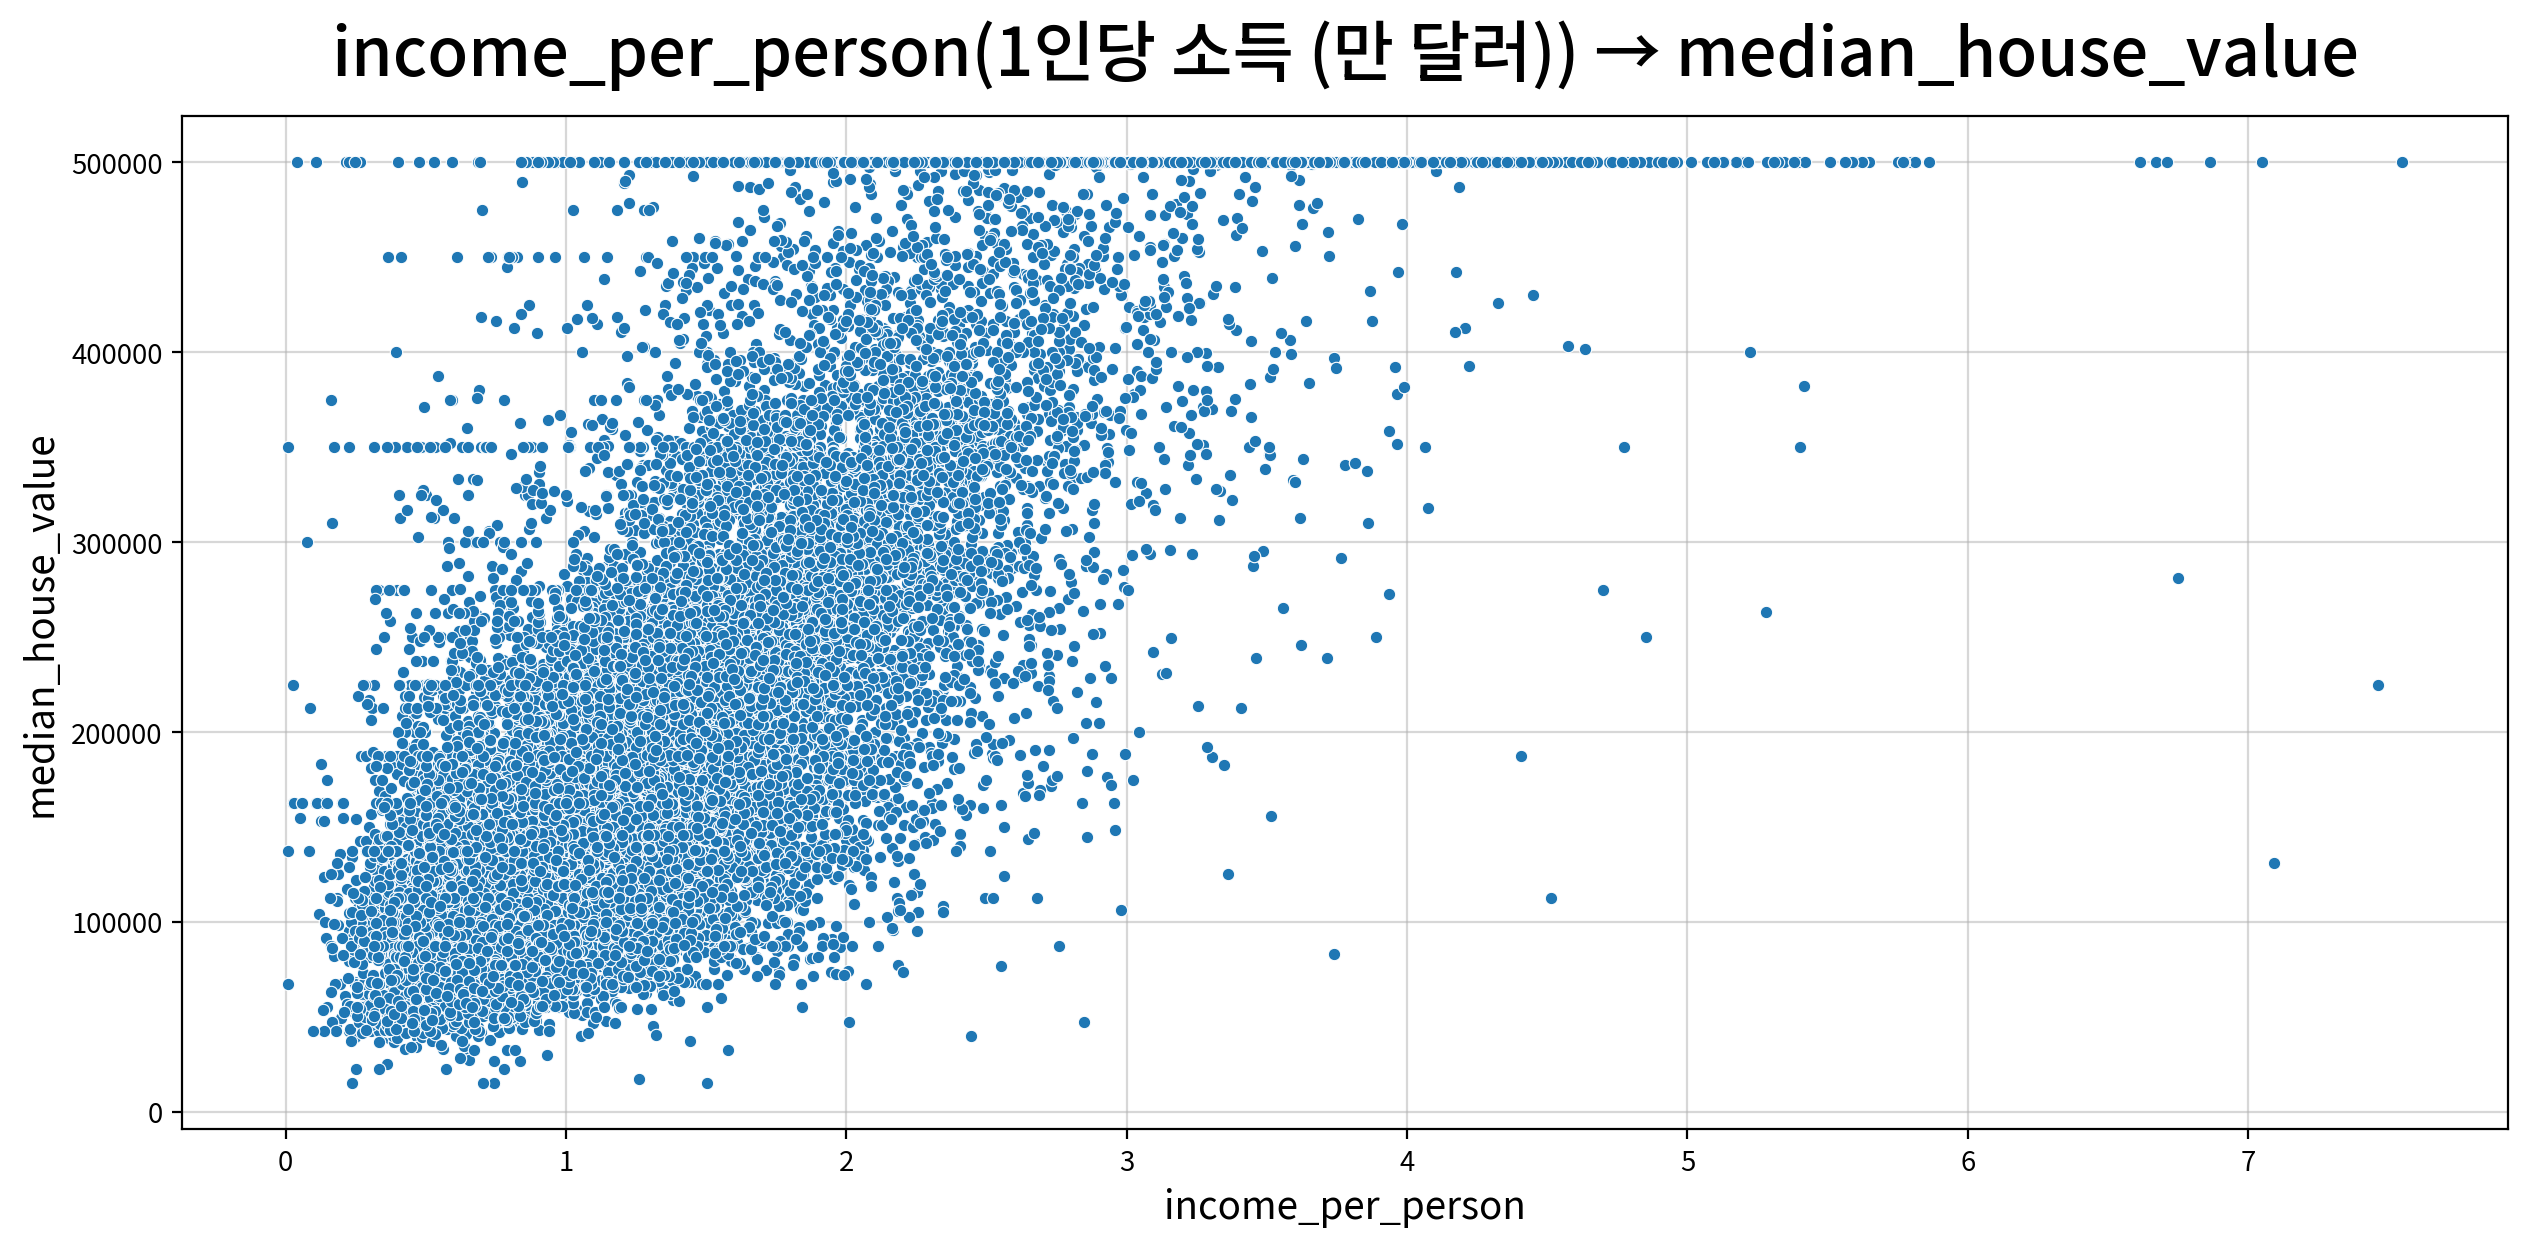

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
income_per_person,median_house_value,Spearman,0.722,0.000,Strong,True,False,False,False,False,True


In [25]:
# 연속형 파생변수 이름을 탐색하면서 반복
for f in derived_continuous:
    # 시각화
    my_plot.scatterplot(data=df, x=f, y=target, outline=False,
                        linewidth=0.4, size=20,
                        title=f"{f}({column_means[f]}) → {target}")

    # my_stats는 시각화까지 일괄처리 한다.
    display(my_stats.correlation(df, x=f, y=target, plot=False))

#### 인사이트

| 변수 | method | coef | strength | p-value | significant |
|---|---|---|---|---|---|
| `income_per_person` | Spearman | **+0.722** | **Strong** | 0.000 | True |
| `rooms_per_person` | Spearman | +0.400 | Moderate | 0.000 | True |
| `bedrooms_per_room` | Spearman | **−0.332** | Moderate | 0.000 | True |
| `rooms_per_household` | Spearman | +0.263 | Weak | 0.000 | True |
| `population_per_household` | Spearman | −0.256 | Weak | 0.000 | True |

##### 결과표에서 읽은 것

- **파생 5종 모두 유의하다(p=0.000).** EDA에서 유일하게 비유의했던 `population`(p=0.681)이 분모로 들어간 `rooms_per_person`·`population_per_household`도 마찬가지다. 단독으로는 관계가 없던 변수가 다른 변수와 조합되면서 정보를 갖게 됐다.
- **`strength`가 Weak이 아닌 변수가 3종으로 늘었다.** EDA에서는 6종 중 `median_income` 하나뿐이었다. 규모 효과가 가격 신호를 덮고 있었다는 EDA의 판단이 수치로 확인된 셈이다.
- **`income_per_person`이 이 데이터셋에서 유일한 Strong 변수다.** 소득은 가구 단위로 기록되어 있지만, 집값을 좌우하는 것은 1인당 구매력에 더 가깝다는 해석이 가능하다.
- **`bedrooms_per_room`만 부호가 음수다.** 방 중 침실 비율이 낮을수록(= 거실·기타 공간이 넓을수록) 비싸다는 뜻이다. 총량 변수로는 관측할 수 없던 관계다.
  → 근거: `coef` 열

### 7. T-Test (x: 2집단 범주형 파생변수 → y: 종속변수)

범주형 파생변수 중 **2집단인 것만** 여기서 검정한다.

#### ▶︎ is_age_capped(주택 연령 상한 절단 여부) → median_house_value

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: Mann-Whitney-Wilcoxon test two-sided, P_val:1.136e-75 U_stat=8.384e+06


c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\California Housing 주택가격 예측\notebooks\helpers\my_prep.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  index=df.groupby(hue).cumcount(),
c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\California Housing 주택가격 예측\notebooks\helpers\my_prep.py:39: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = pivot_table(data=df,


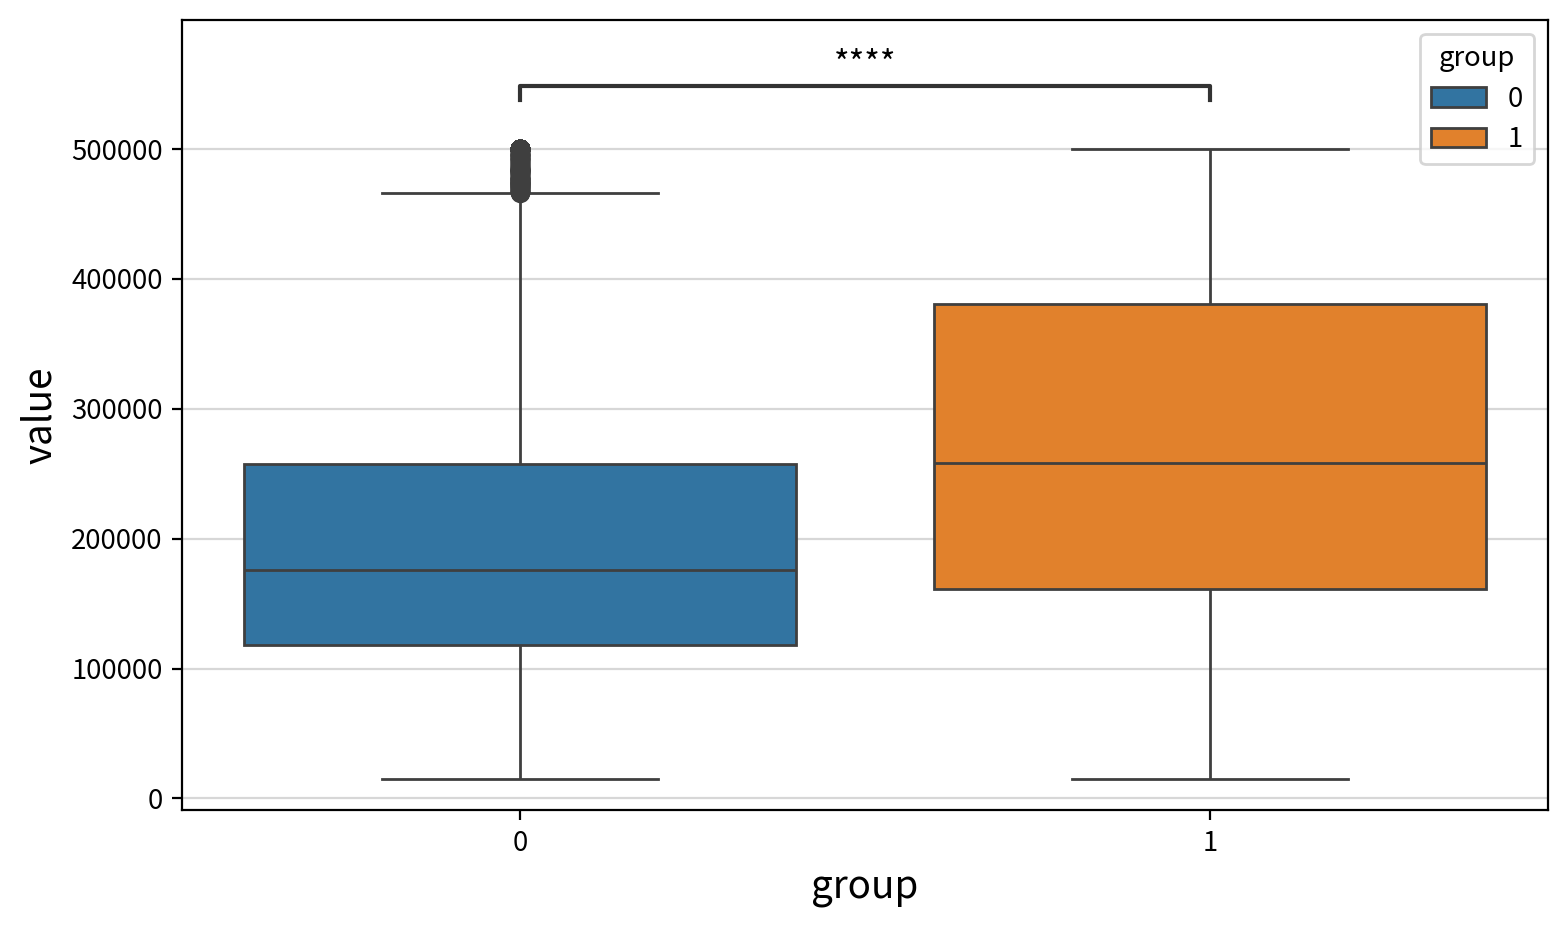

statistic  p-value  significant  result
test                alternative                                          
Mann-Whitney U test two-sided   8383512.000    0.000         True  0 != 1
                    less        8383512.000    0.000         True   0 < 1
                    greater     8383512.000    1.000        False  0 <= 1

#### ▶︎ is_income_capped(소득 상한 절단 여부) → median_house_value

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: Mann-Whitney-Wilcoxon test two-sided, P_val:1.829e-29 U_stat=4.007e+04


c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\California Housing 주택가격 예측\notebooks\helpers\my_prep.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  index=df.groupby(hue).cumcount(),
c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\California Housing 주택가격 예측\notebooks\helpers\my_prep.py:39: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = pivot_table(data=df,


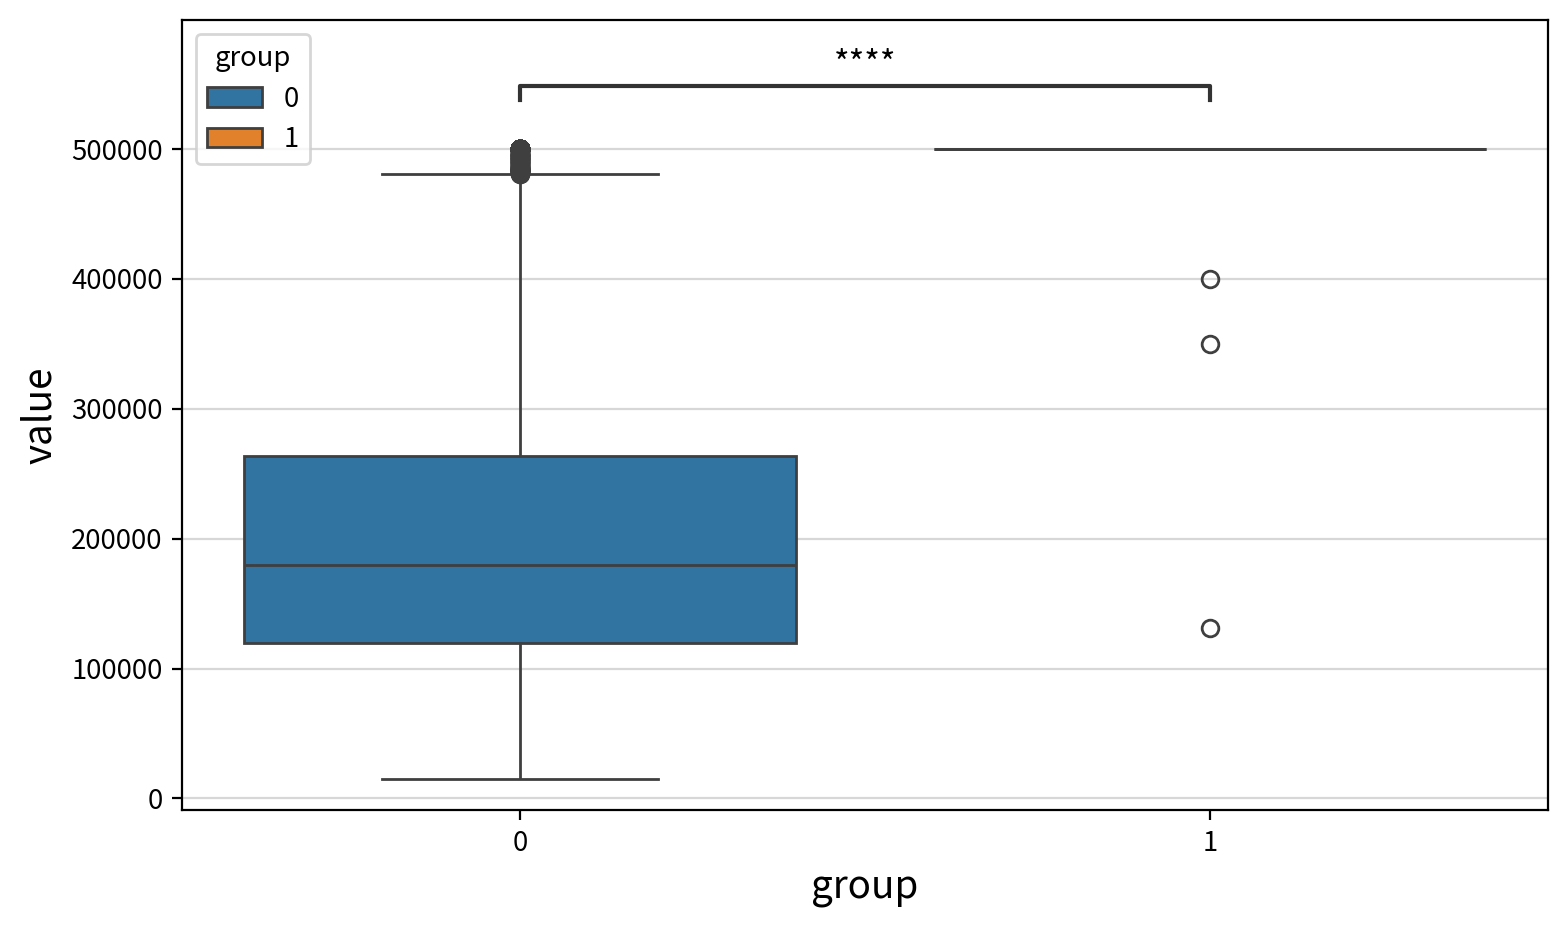

statistic  p-value  significant  result
test                alternative                                         
Mann-Whitney U test two-sided    40072.000    0.000         True  0 != 1
                    less         40072.000    0.000         True   0 < 1
                    greater      40072.000    1.000        False  0 <= 1

#### ▶︎ ocean_area(내륙/해안권 구분) → median_house_value

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

COASTAL vs. INLAND: Mann-Whitney-Wilcoxon test two-sided, P_val:0.000e+00 U_stat=7.704e+07


c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\California Housing 주택가격 예측\notebooks\helpers\my_prep.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  index=df.groupby(hue).cumcount(),
c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\California Housing 주택가격 예측\notebooks\helpers\my_prep.py:39: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = pivot_table(data=df,


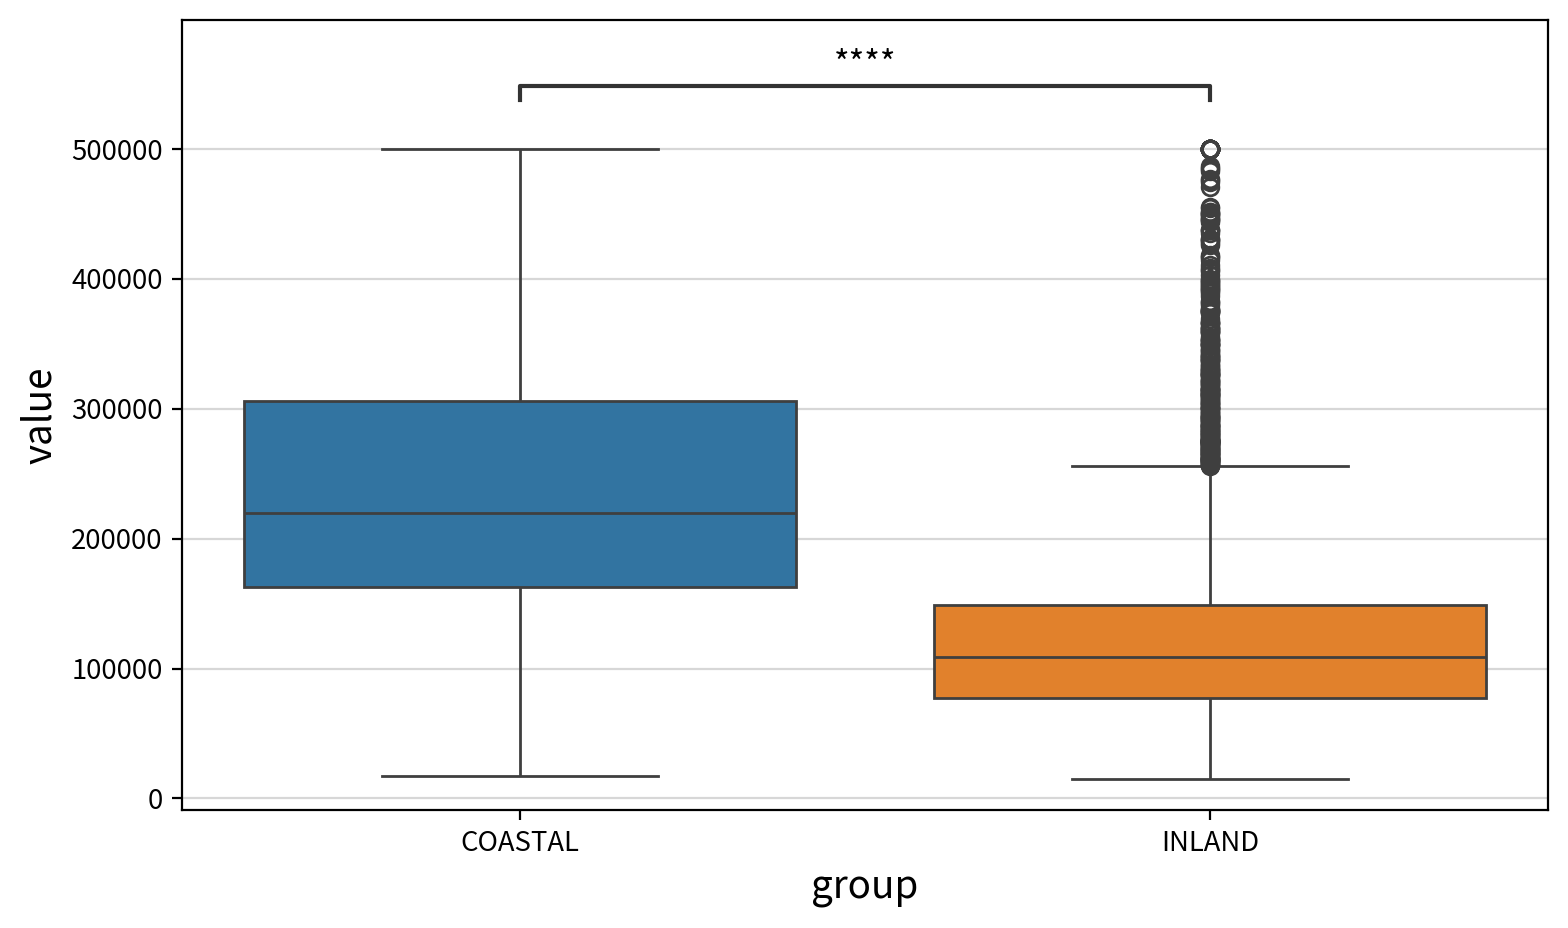

statistic  p-value  significant  \
test                alternative                                      
Mann-Whitney U test two-sided   77038278.500    0.000         True   
                    less        77038278.500    1.000        False   
                    greater     77038278.500    0.000         True   

                                            result  
test                alternative                     
Mann-Whitney U test two-sided    COASTAL != INLAND  
                    less         COASTAL >= INLAND  
                    greater       COASTAL > INLAND

In [26]:
for n in derived_nominal:
    # 2개의 고유값만 존재하는 범주형 독립변수에 대해서만 검정을 수행한다.
    if len(df[n].unique()) == 2:
        # 빈 줄 출력용
        print()

        # 분석 단위 제목 출력
        display(Markdown(f"#### ▶︎ {n}({column_means[n]}) → {target}"))

        # 수집된 데이터가 long 타입이므로 검정 대상만 wide 타입으로 변환해야 한다.
        wide_df = my_prep.long2wide(df, hue=n, values=target)
        display(my_stats.test_independent(wide_df,
                    group1=wide_df.columns[0], group2=wide_df.columns[1],
                    width=800, height=480))

#### 인사이트

| 변수 | 집단 1 평균 | 집단 0 평균 | 차이 | 검정 결과 | 채택 여부 |
|---|---|---|---|---|---|
| `ocean_area` | COASTAL 245,069\$ | INLAND 124,897\$ | 120,172\$ | 유의 (p<0.001) | 채택 |
| `is_age_capped` | 275,393\$ | 202,342\$ | 73,051\$ | 유의 (p<0.001) | 채택 |
| `is_income_capped` | 487,627\$ | 206,176\$ | 281,451\$ | 유의 (p<0.001) | 보류 |

- **`ocean_area`는 병합 후에도 EDA 수준의 설명력을 유지한다.** EDA에서 5범주 `ocean_proximity`의 `INLAND` 평균은 124,897\$였고, 병합된 해안권 3종의 평균은 240,268\~259,279\$였다. 하나로 묶은 COASTAL의 평균 245,069\$가 그 범위 안에 들어온다. 범주를 5개에서 2개로 줄였지만 잃은 것이 거의 없다는 뜻이다.
- **`is_age_capped`는 주택 연령 자체와 다른 정보를 담는다.** EDA에서 `housing_median_age`의 상관은 ρ=+0.075로 거의 없었지만, "52년으로 잘릴 만큼 오래된 동네"라는 표시는 7만\$ 이상의 차이를 만든다. 연속형으로는 잡히지 않던 신호이며, 오래 자리 잡은 도심 지역이 여기에 해당한다.
- **`is_income_capped`는 차이가 가장 크지만 채택을 보류한다.** 평균 차이 28만\$에 중앙값이 500,001\$로 종속변수 상한과 겹친다. 문제는 n=50(0.2%)이라는 점이다. 차이의 크기가 아니라 **그 차이를 50건으로 추정했다는 사실**이 위험하다. EDA에서 `ISLAND` 5건을 해석에 쓰지 않기로 한 것과 같은 이유다.
- 검정된 것은 2집단 변수 셋뿐이다. `special_cluster`(5범주)는 조건에 걸려 건너뛰었고 `#04-7`에서 다룬다. 종속변수의 500,001\$ 절단 구간은 `#02-4`에서 플래그를 만들지 않았으므로 애초에 목록에 없다.

### 8. ANOVA (x: 3집단 이상 범주형 파생변수 → y: 종속변수)

앞에서 만든 공간정보 `special_cluster`가 대상이다.

In [27]:
for n in derived_nominal:
    # 3개 이상의 고유값이 존재하는 범주형 독립변수에 대해서만 검정을 수행한다.
    if len(df[n].unique()) >= 3:
        print() # 빈 줄 출력용

        # 분석 단위 제목 출력
        display(Markdown(f"#### ▶︎ {n}({column_means[n]}) → {target}"))

        # 분산분석
        display(my_stats.anova_oneway(df, y=target, between=n))

        # 사후검정
        display(my_stats.posthoc_oneway(df, y=target, between=n, plot=False))

#### ▶︎ special_cluster(위경도 기반 공간 군집) → median_house_value

c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\California Housing 주택가격 예측\notebooks\helpers\my_prep.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  index=df.groupby(hue).cumcount(),
c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\California Housing 주택가격 예측\notebooks\helpers\my_prep.py:39: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = pivot_table(data=df,


,test,Source,ddof1,ddof2,F,p_unc,np2,effect_size
0,welch_anova,special_cluster,4,5508.155,2299.156,0.000,0.126,Medium


c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\California Housing 주택가격 예측\notebooks\helpers\my_prep.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  index=df.groupby(hue).cumcount(),
c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\California Housing 주택가격 예측\notebooks\helpers\my_prep.py:39: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = pivot_table(data=df,


비교한 조합 쌍: 10개
유의한 쌍: 10개
평균 차이가 가장 큰 쌍: (0) vs (1) -> 차이 136984.354, 효과크기 Large, p-value 0.000
평균 차이가 가장 작은 쌍: (0) vs (1)-> 차이 136984.354, 효과크기 Large, p-value 0.000


,test,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,significant,effect_size
0,Games-Howell,0,1,93638.609,230622.962,-136984.354,1643.444,-83.352,3961.218,0.000,-1.277,True,Large
1,Games-Howell,0,2,93638.609,224715.951,-131077.342,1802.992,-72.700,4815.611,0.000,-1.201,True,Large
2,Games-Howell,0,3,93638.609,177071.846,-83433.237,2347.525,-35.541,3095.476,0.000,-1.004,True,Large
3,Games-Howell,0,4,93638.609,121984.265,-28345.656,2429.515,-11.667,2529.102,0.000,-0.373,True,Small
4,Games-Howell,1,2,230622.962,224715.951,5907.012,1857.209,3.181,14257.849,0.013,0.052,True,Negligible
5,Games-Howell,1,3,230622.962,177071.846,53551.117,2389.418,22.412,3857.101,0.000,0.489,True,Small
6,Games-Howell,1,4,230622.962,121984.265,108638.697,2470.018,43.983,2998.000,0.000,0.995,True,Large
7,Games-Howell,2,3,224715.951,177071.846,47644.105,2501.838,19.044,4450.040,0.000,0.427,True,Small
8,Games-Howell,2,4,224715.951,121984.265,102731.686,2578.926,39.835,3464.306,0.000,0.923,True,Large
9,Games-Howell,3,4,177071.846,121984.265,55087.581,2985.122,18.454,3895.262,0.000,0.584,True,Medium


#### 인사이트

| 군집 | 건수 | 평균 집값 | 중심 좌표 | 해당 권역 |
|---|---|---|---|---|
| 1 | 8,729 | 230,623\$ | (34.01, −118.13) | 남부 (LA 권역) |
| 2 | 6,736 | 224,716\$ | (37.85, −121.87) | 중북부 (베이 권역) |
| 3 | 2,211 | 177,072\$ | (33.09, −116.95) | 최남부 (샌디에이고 권역) |
| 4 | 1,778 | 121,984\$ | (36.00, −119.70) | 중부 내륙 (센트럴밸리) |
| 0 | 979 | 93,639\$ | (39.93, −122.32) | 북부 내륙 |

- **유의하며 효과크기도 충분하다.** Welch F=2,299.2 (p<0.001), np2=**0.126(Medium)**. 좌표 두 개만 가지고 만든 단일 변수가 집값 분산의 12.6%를 설명한다.
- **10쌍이 모두 유의하다.** 5개 군집이 서로 다른 가격대를 형성하고 있다는 뜻이다. 최저인 군집 0(북부 내륙, 93,639\$)과 최고인 군집 1(LA 권역, 230,623\$)의 격차는 13.7만\$, hedges 1.277(Large)다.
- **`#03`의 Moran's I(0.790)가 실체를 가졌다.** "인접한 주택끼리 가격이 비슷하다"는 진단이 5개의 구체적인 시장 권역으로 번역됐고, 그 권역 구분이 통계적으로 확인됐다.

### 9. 연속형 파생변수 간 상관 분석

재료가 같은 변수끼리는 겹칠 수밖에 없다. 어느 정도인지 확인해 둔다.

In [28]:
corr = my_stats.multi_correlation(df, columns=derived_continuous, plot=False)
my_stats.correlation_summary(corr)

,rooms_per_person,rooms_per_household,bedrooms_per_room,population_per_household,income_per_person
rooms_per_person,1.000,0.662,-0.542,-0.675,0.737
rooms_per_household,0.662,1.000,-0.888,0.018,0.536
bedrooms_per_room,-0.542,-0.888,1.000,-0.080,-0.599
population_per_household,-0.675,0.018,-0.080,1.000,-0.469
income_per_person,0.737,0.536,-0.599,-0.469,1.000


,max-y,max-coef,count,columns
x,,,,
bedrooms_per_room,rooms_per_household,-0.888,1,rooms_per_household
rooms_per_household,bedrooms_per_room,-0.888,1,bedrooms_per_room
income_per_person,rooms_per_person,0.737,1,rooms_per_person
rooms_per_person,income_per_person,0.737,1,income_per_person
population_per_household,rooms_per_person,-0.675,0,-


#### 인사이트

- **EDA의 총량 4종(상호 ρ≥0.90)보다는 나아졌지만 중복이 사라진 것은 아니다.** 5종을 만들었어도 재료는 여전히 5개 원본 변수이므로, 어느 조합이든 분자나 분모를 공유한다.

### ✅ 종합 판단

| 채택여부 | 변수 | 검정방법 | 유의수준 (p) | 효과 | 비대칭신호 | 공선성 신호 | 근거 |
|---|---|---|---|---|---|---|---|
| 채택 | `income_per_person` | Spearman | $< 0.05$ | ρ=+0.722 (Strong) | 우편향(+1.46) / log 변환 | O (`rooms_per_person` 0.737) | 데이터셋 유일의 Strong. EDA 최강이던 `median_income`(+0.677)도 상회하므로 1순위 |
| 채택 | `ocean_area` | Mann-Whitney U | $< 0.05$ | 평균차 120,172\$ | 해당 없음 | X | 5범주를 2범주로 줄이고도 EDA 수준의 집단 격차 유지 |
| 채택 | `rooms_per_person` | Spearman | $< 0.05$ | ρ=+0.400 (Moderate) | 극단 우편향(+17.76) / log 변환 | O (`income_per_person` 0.737) | 규모 축 대표. 원본 `total_rooms`(+0.205)의 2배 |
| 채택 | `bedrooms_per_room` | Spearman | $< 0.05$ | ρ=−0.332 (Moderate) | 우편향(+2.25) / log 변환 | O (`rooms_per_household` −0.888) | 파생 중 분포가 가장 안정. 총량으로는 못 보던 음의 관계 |
| 후보 | `is_age_capped` | Mann-Whitney U | $< 0.05$ | 평균차 73,051\$ | 해당 없음 | 미점검 | `housing_median_age`(ρ=+0.075)가 못 잡던 신호. 6.2%로 검정에 충분 |
| 채택 | `special_cluster` | Welch ANOVA | $< 0.05$ | np2=0.126 (Medium) → 통제 후 **0.162 (Large)** | 해당 없음 | △ (`ocean_area` V=0.411, 보완 관계) | `ocean_area` 통제 후에도 Large를 유지하고 교호작용까지 유의(`#04-9`). 내륙 내부를 np2=0.170(Large)으로 갈라내 `ocean_area`가 못 하던 구분을 담당 |
| 후보 | `rooms_per_household` | Spearman | $< 0.05$ | ρ=+0.263 (Weak) | 극단 우편향(+20.68) / log 변환 | O (`bedrooms_per_room` −0.888) | `bedrooms_per_room`과 중복이 심해 둘 중 하나만. VIF로 판정 |
| 후보 | `population_per_household` | Spearman | $< 0.05$ | ρ=−0.256 (Weak) | 최악(+97.16) / log 변환 | O (`rooms_per_person` −0.675) | 설명력 최약이면서 분포도 최악. 우선 제거 후보 |
| 보류 | `is_income_capped` | Mann-Whitney U | $< 0.05$ | 평균차 281,451\$ | 해당 없음 | 미점검 | 차이는 크지만 n=50(0.2%). 추정 안정성이 낮아 투입 여부 재판단 필요 |

## #07. 파생변수 데이터셋 저장

### 1. 투입 변수 정리

In [29]:
# 모형에 투입할 변수 (원본 1종 + 연속형 파생 5종 + 범주형 파생 4종)
feature_cols = [
    "housing_median_age",         # 유지된 원본
    "rooms_per_person",           # 연속형 파생변수
    "rooms_per_household",        # 연속형 파생변수
    "bedrooms_per_room",          # 연속형 파생변수
    "population_per_household",   # 연속형 파생변수
    "income_per_person",          # 연속형 파생변수
    "is_age_capped",              # 범주형 파생
    "is_income_capped",           # 범주형 파생
    "ocean_area",                 # 범주형 파생
    "special_cluster",            # 공간정보
]

print("투입 변수 :", len(feature_cols), "종\n")
print("투입 변수 목록 :", feature_cols)

투입 변수 : 10 종

투입 변수 목록 : ['housing_median_age', 'rooms_per_person', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'income_per_person', 'is_age_capped', 'is_income_capped', 'ocean_area', 'special_cluster']


### 2. 파생변수 데이터셋 저장

로그 변환·라벨링을 적용하기 전, 원 단위 그대로의 상태를 먼저 남긴다.


In [30]:
# 저장 대상 = 투입 변수 + 종속변수
save_cols = feature_cols + [target]
print(save_cols)

# 변환할 변수만 추출
df_derived = df[save_cols]

# 범주형 변수 타입 변환
df_derived = my_qtcheck.set_type(df_derived, as_category=["is_age_capped", "is_income_capped", "ocean_area", "special_cluster"])

# 저장
df_derived.to_excel("california_housing_features.xlsx", index=False)
print("저장 완료 :", df_derived.shape)

['housing_median_age', 'rooms_per_person', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'income_per_person', 'is_age_capped', 'is_income_capped', 'ocean_area', 'special_cluster', 'median_house_value']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20433 entries, 0 to 20432
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   housing_median_age        20433 non-null  int64   
 1   rooms_per_person          20433 non-null  float64 
 2   rooms_per_household       20433 non-null  float64 
 3   bedrooms_per_room         20433 non-null  float64 
 4   population_per_household  20433 non-null  float64 
 5   income_per_person         20433 non-null  float64 
 6   is_age_capped             20433 non-null  category
 7   is_income_capped          20433 non-null  category
 8   ocean_area                20433 non-null  category
 9   special_cluster           20433 non-null  

## #08. 로그 변환 및 데이터 라벨링

### 1. 변환 대상 확인

- 기술통계량 표에서 로그 변환 필요성 여부만 확인한다.

In [31]:
feature_desc = my_qtcheck.numerical_summary(df_derived)
feature_desc['log_need'].T

housing_median_age          none
rooms_per_person             log
rooms_per_household          log
bedrooms_per_room            log
population_per_household     log
income_per_person            log
median_house_value           log
Name: log_need, dtype: object

### 2. 로그 변환 대상 추출

In [32]:
# log_need 판정에 따라 변환 대상을 분류한다.
log_cols = feature_desc[feature_desc["log_need"] == "log"].index.tolist()
log1p_cols = feature_desc[feature_desc["log_need"] == "log1p"].index.tolist()
reflect_cols = feature_desc[feature_desc["log_need"] == "reverse_log1p"].index.tolist()

print("log(x)      :", log_cols)
print("log(1+x)    :", log1p_cols)
print("반사 후 log :", reflect_cols)

log(x)      : ['rooms_per_person', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'income_per_person', 'median_house_value']
log(1+x)    : []
반사 후 log : []


### 3. 독립변수 및 종속변수 로그 변환

In [33]:
# 앞에서 확정한 투입 변수만 변환한다.
df_log = my_prep.log_transform(df_derived,
            log_columns=log_cols,
            log1p_columns=log1p_cols,
            reflect_columns=reflect_cols)


컬럼        꼬리방향      변환식                   역변환식                                  왜도
----------------------------------------------------------------------------------------
rooms_per_person우측 꼬리     log(x)                exp(y)                  17.76 -> -0.73
rooms_per_household우측 꼬리     log(x)                exp(y)                   20.68 -> 0.88
bedrooms_per_room우측 꼬리     log(x)                exp(y)                    2.25 -> 0.54
population_per_household우측 꼬리     log(x)                exp(y)                   97.15 -> 2.14
income_per_person우측 꼬리     log(x)                exp(y)                   1.46 -> -0.55
median_house_value우측 꼬리     log(x)                exp(y)                   0.98 -> -0.17


### 4. 범주형 라벨링

In [34]:
# 라벨링 대상 : category 타입인 범주형 파생변수
# -> 절단 플래그 2종은 이미 0/1 정수이므로 대상이 아니다.
label_cols = ["ocean_area", "special_cluster"]

df_label = my_prep.labeling(df_log, columns=label_cols)

df_label[label_cols].head()

ocean_area (2종): COASTAL=0,INLAND=1
special_cluster (5종): 0=0,1=1,2=2,3=3,4=4


,ocean_area,special_cluster
0,0,2
1,0,2
2,0,2
3,0,2
4,0,2


### 5. 최종 데이터셋 저장

In [35]:
df_label.to_excel("california_housing_features.xlsx", index=False)

print("저장 완료 :", df_label.shape)
df_label.head()

저장 완료 : (20433, 11)


,housing_median_age,rooms_per_person,rooms_per_household,bedrooms_per_room,population_per_household,income_per_person,is_age_capped,is_income_capped,ocean_area,special_cluster,median_house_value
0,41,1.005,1.944,-1.920,0.938,1.181,0,0,0,2,13.023
1,21,1.084,1.831,-1.859,0.747,1.370,0,0,0,2,12.790
2,52,1.084,2.115,-2.044,1.030,0.952,1,0,0,2,12.772
3,52,0.826,1.761,-1.690,0.935,0.795,1,0,0,2,12.741
4,52,1.058,1.838,-1.760,0.780,0.567,1,0,0,2,12.743
